# Using NMF Modeling

In [57]:
import pickle
import pandas as pd
nmf_model18 = pickle.load(
    open(r"C:\Projects\worldcup-social-media-nlp\models\worldcup2018_nmf.pkl", "rb")
)

vectorizer18 = pickle.load(
    open(r"C:\Projects\worldcup-social-media-nlp\models\worldcup2018_vectorizer.pkl", "rb")
)

nmf_model22 = pickle.load(
    open(r"C:\Projects\worldcup-social-media-nlp\models\worldcup2022_nmf.pkl", "rb")
)

vectorizer22 = pickle.load(
    open(r"C:\Projects\worldcup-social-media-nlp\models\worldcup2022_vectorizer.pkl", "rb")
)
df18_nmf = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2018_nmf_topics.csv"
)

df22_nmf = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2022_nmf_topics.csv"
)

**2018 World Cup**

In [ ]:
#Create topic representations
feature_names18 = vectorizer18.get_feature_names_out()

def get_nmf_topic_words(
    model,
    feature_names,
    topic_id,
    n_words=5
):

    topic = model.components_[topic_id]

    words = [
        feature_names[i]
        for i in topic.argsort()[-n_words:][::-1]
    ]

    return " | ".join(words)

In [56]:
get_nmf_topic_words(
    nmf_model18,
    feature_names18,
    0
)

'world | cup | world cup | cup final | win world'

In [58]:
df18_nmf.columns

Index(['Unnamed: 0', 'Date', 'Source', 'Tweet', 'Likes', 'RTs', 'Hashtags',
       'Place', 'dominant_topic'],
      dtype='str')

* Most Discussed Topics in 2018 World Cup

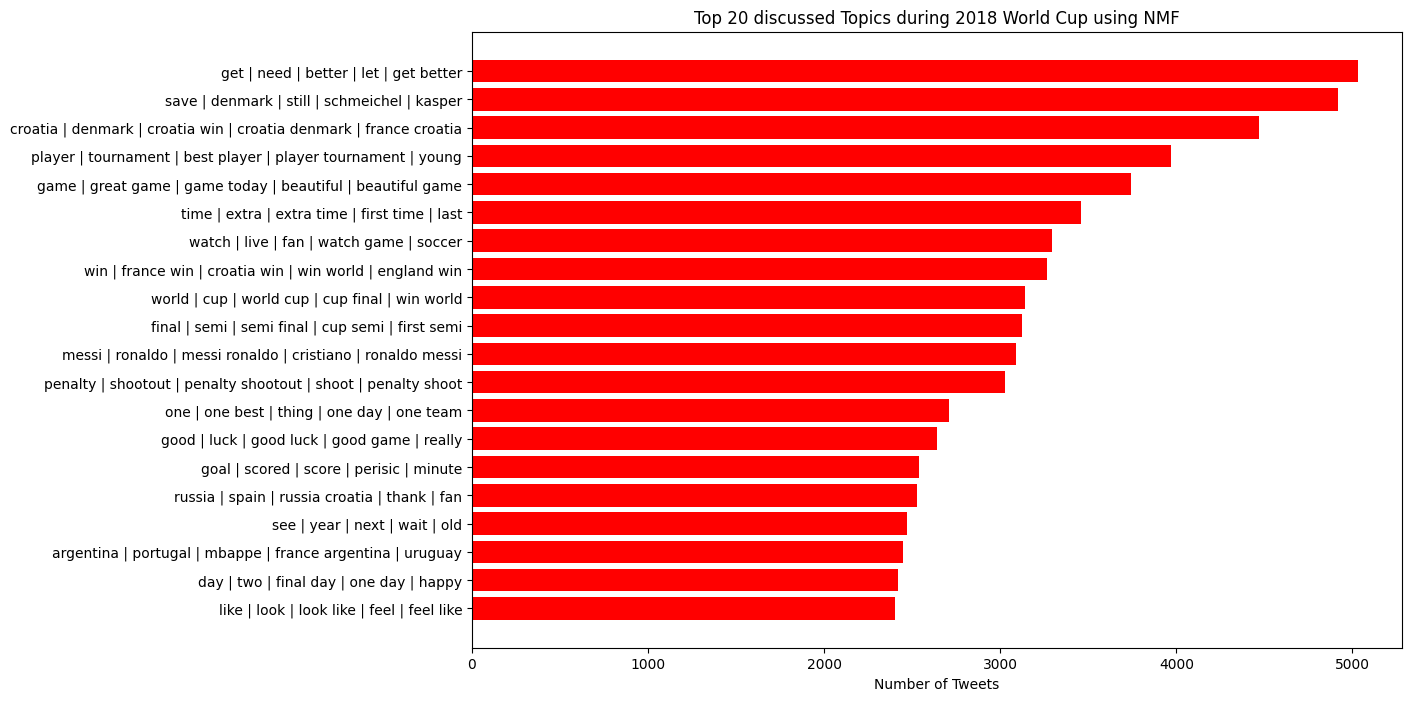

In [74]:
top_topics = (
    df18_nmf["dominant_topic"]
    .value_counts()
    .head(20)
)
rows = []

for topic_id, count in top_topics.items():

    rows.append({
        "Representation": get_nmf_topic_words(
            nmf_model18,
            feature_names18,
            topic_id
        ),
        "Count": count
    })

topic_df = pd.DataFrame(rows)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    topic_df["Representation"],
    topic_df["Count"],
    color="red"
)

plt.title(
    "Top 20 discussed Topics during 2018 World Cup using NMF"
)

plt.xlabel(
    "Number of Tweets"
)

plt.gca().invert_yaxis()

plt.show()

* Do fans from different places focus on different themes and Are some topics niche or universal? (in 2018 worlcup)

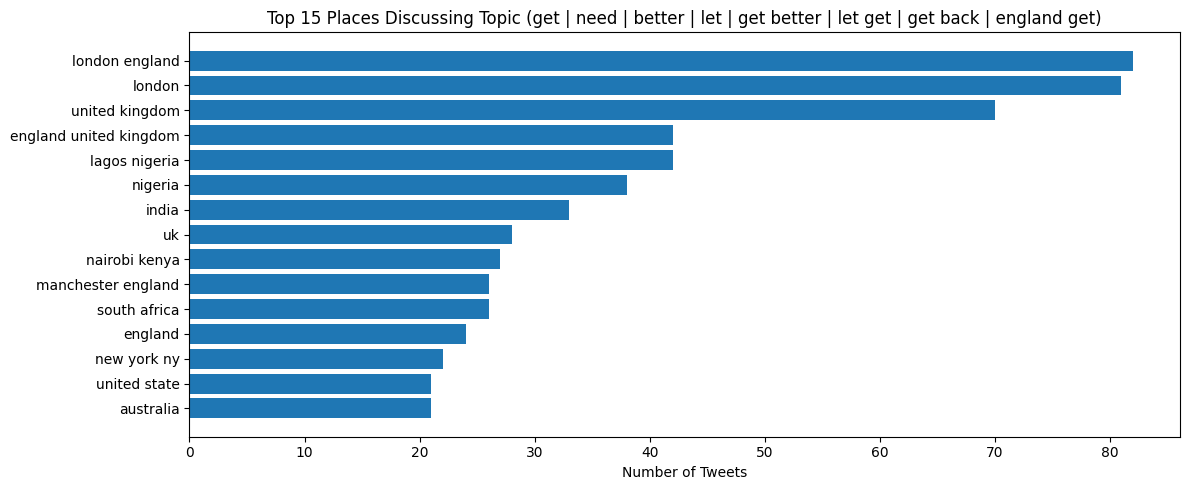

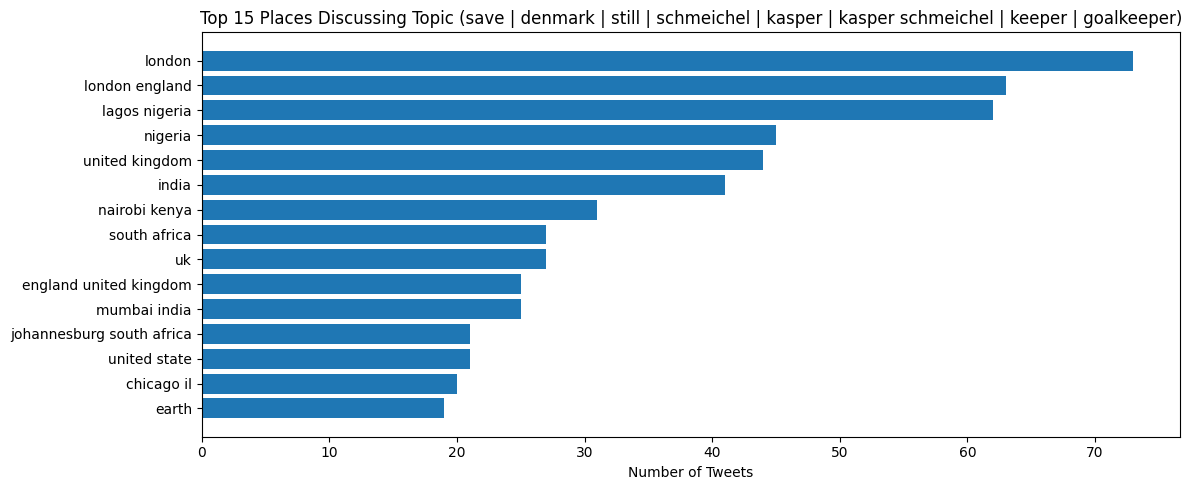

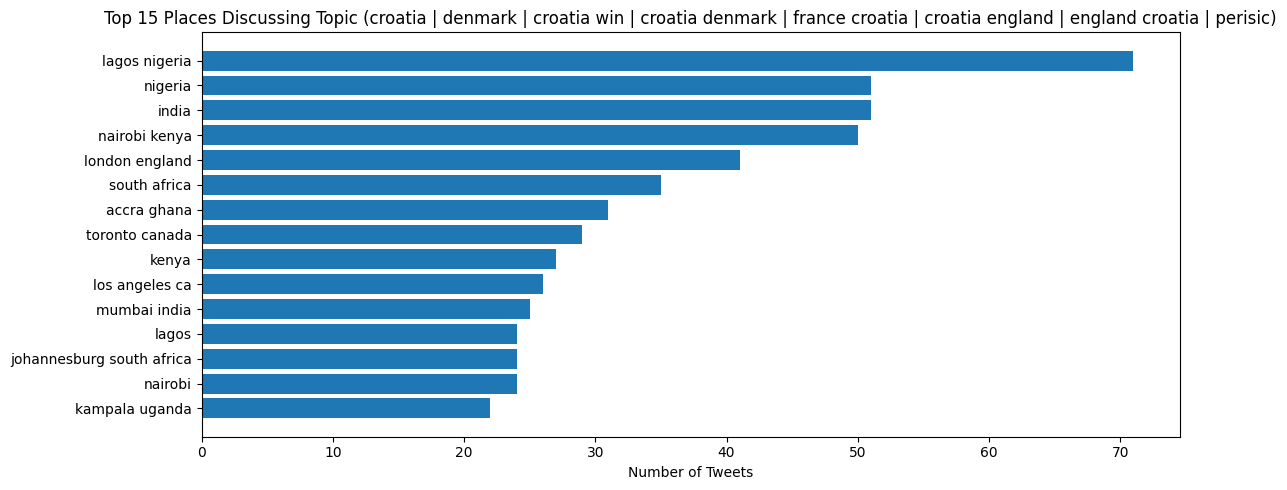

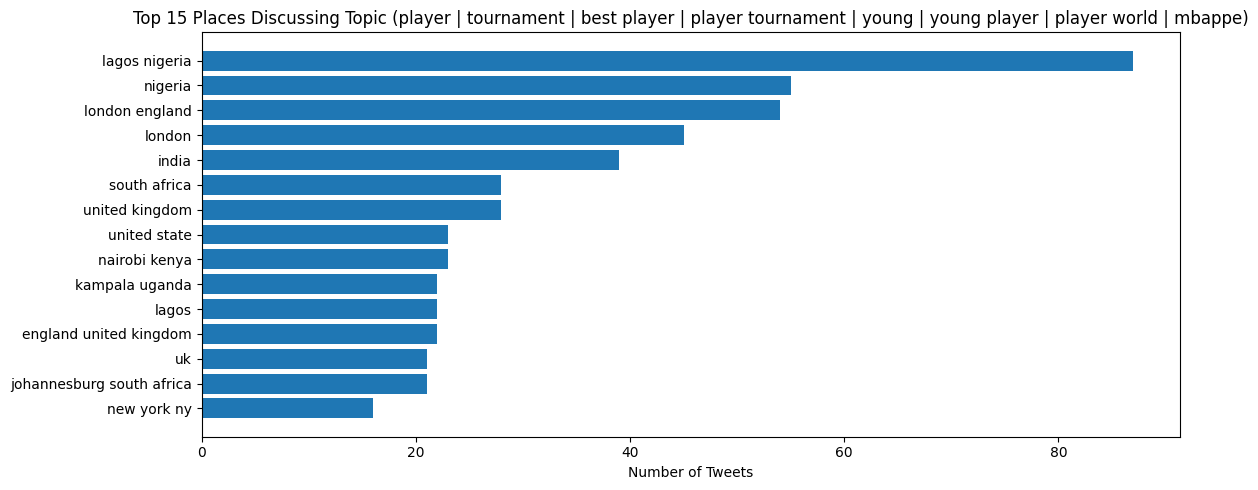

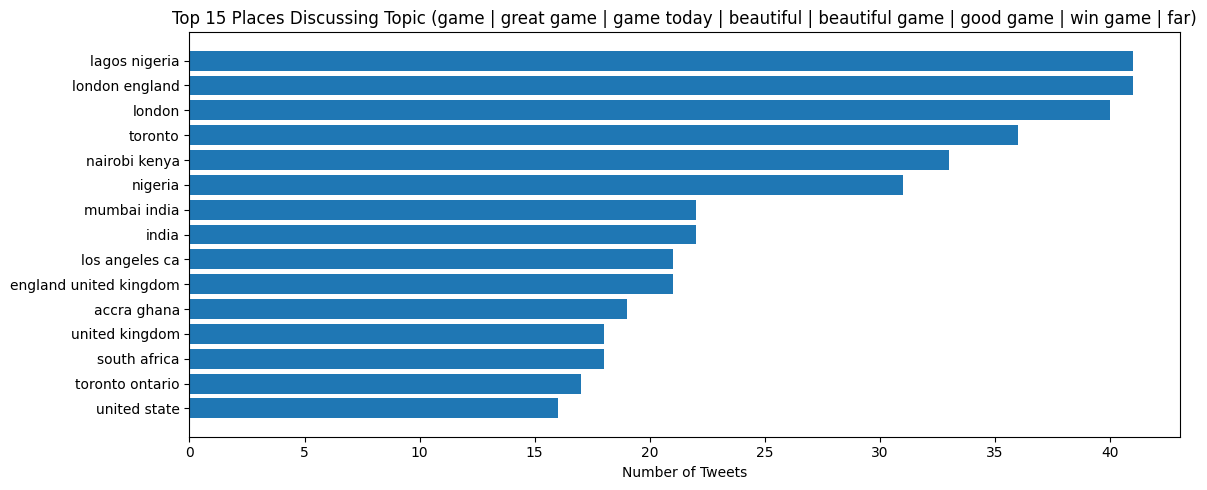

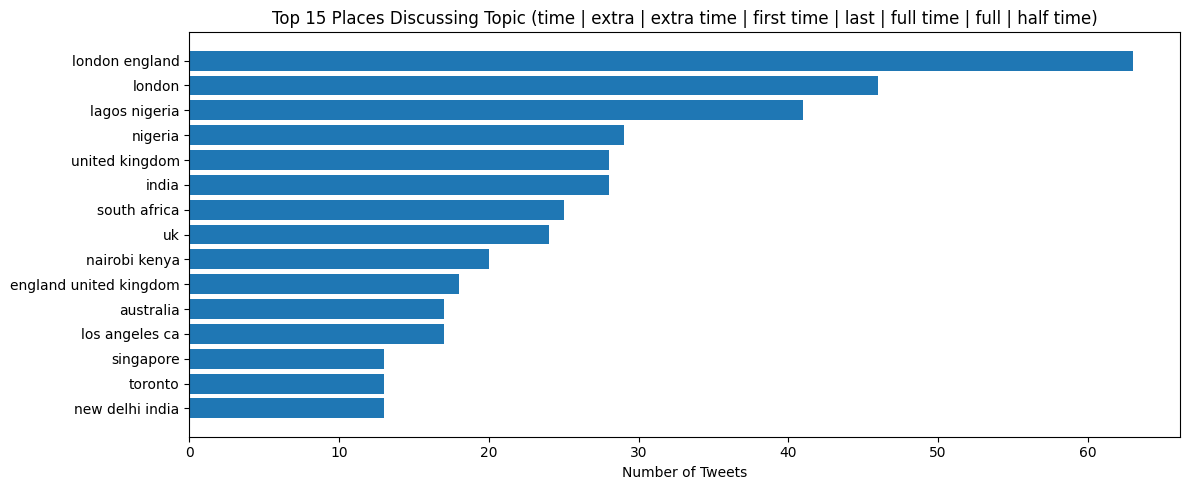

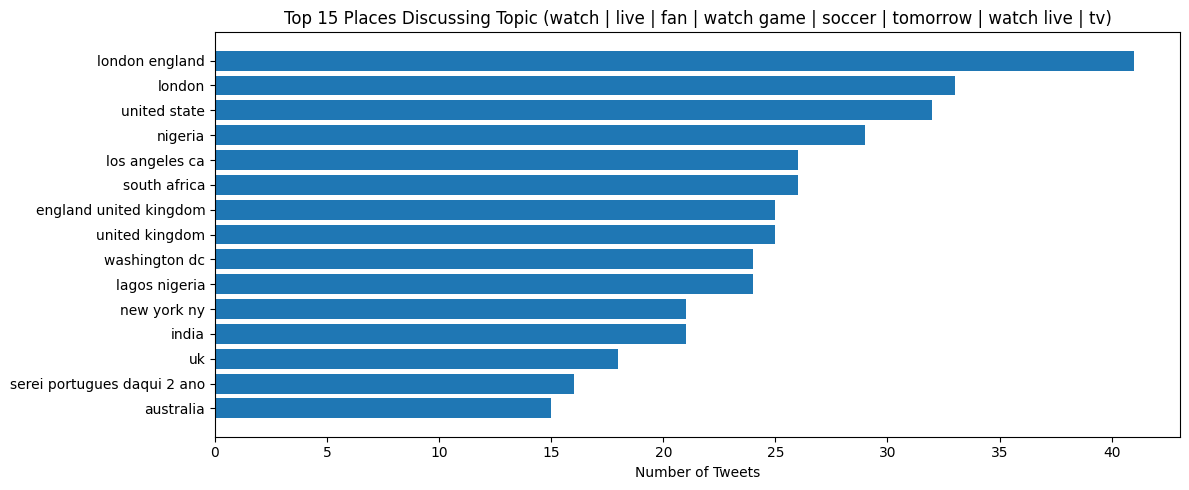

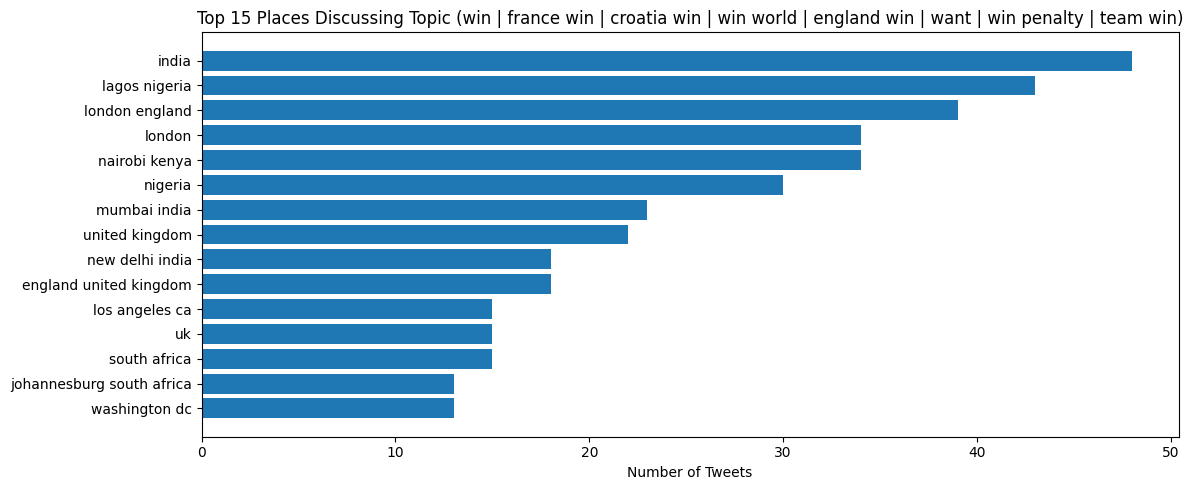

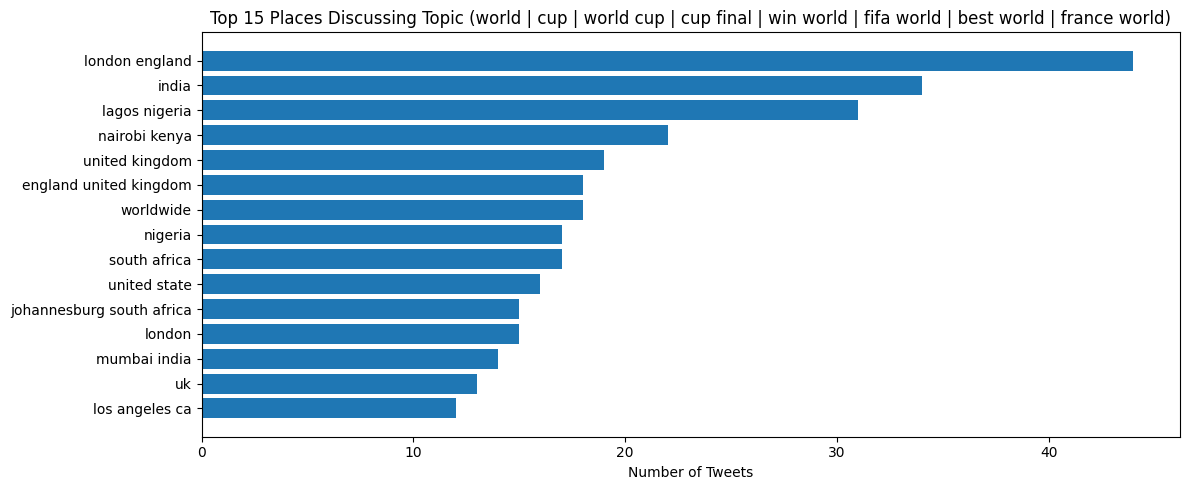

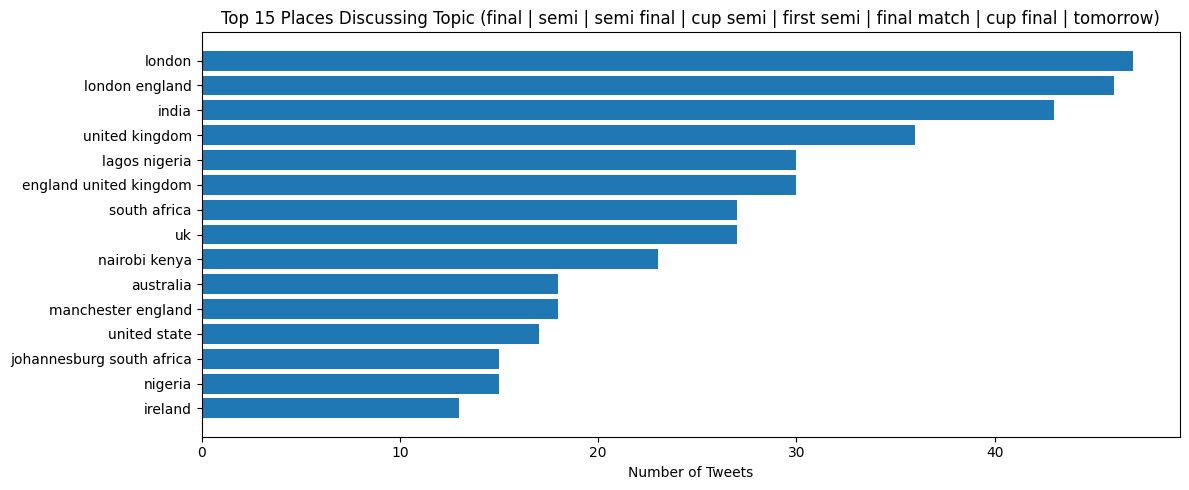

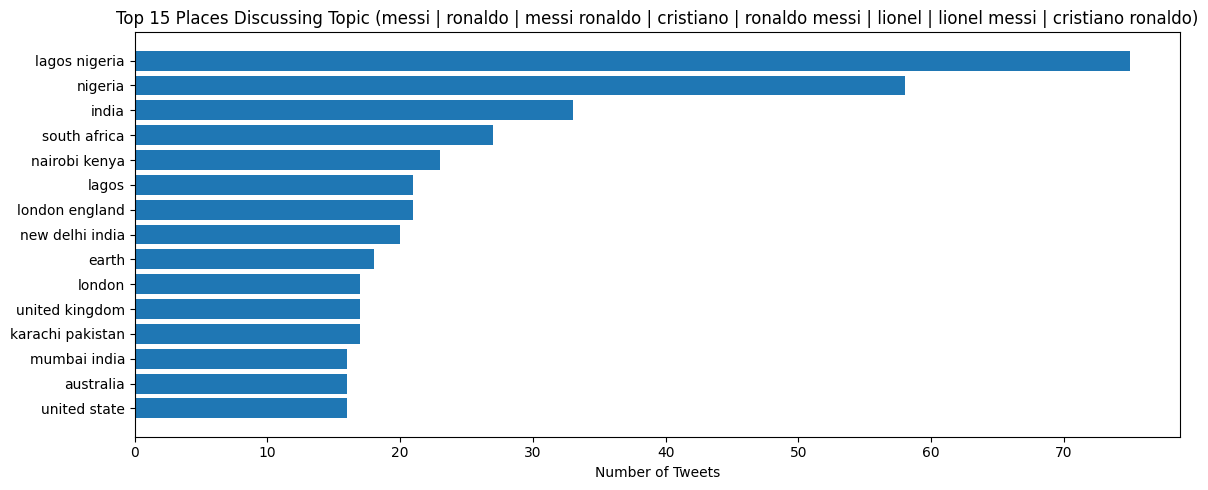

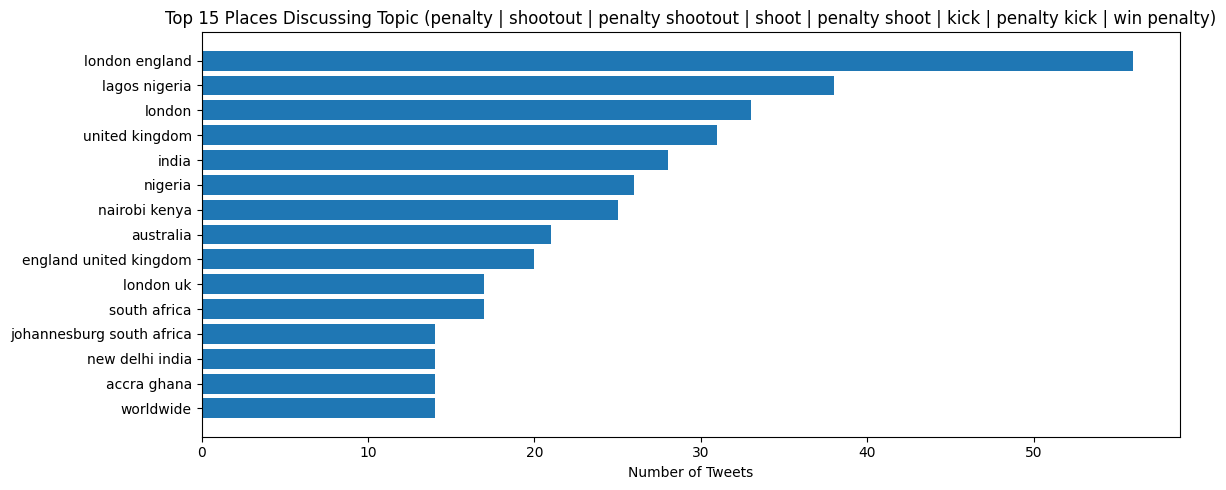

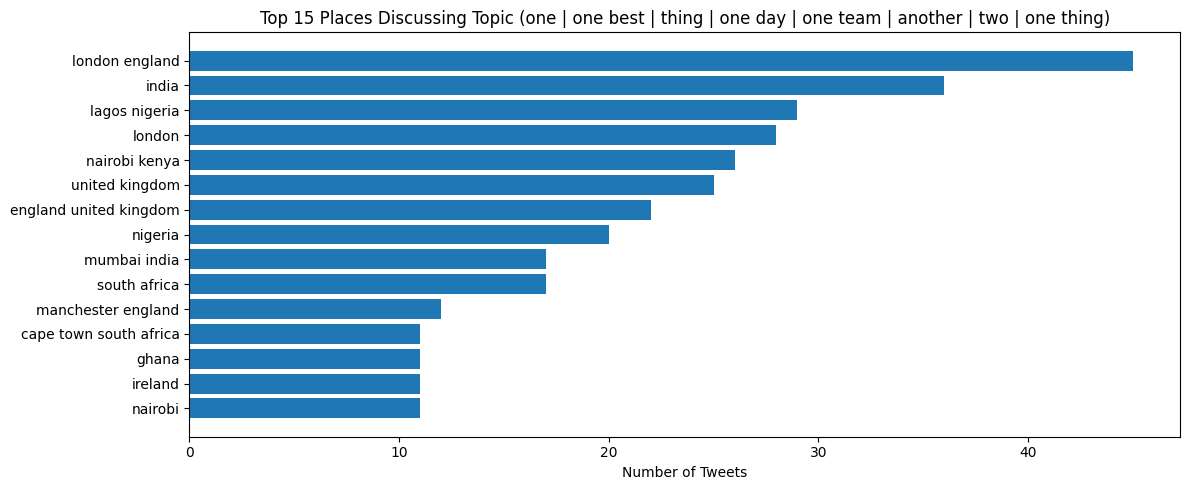

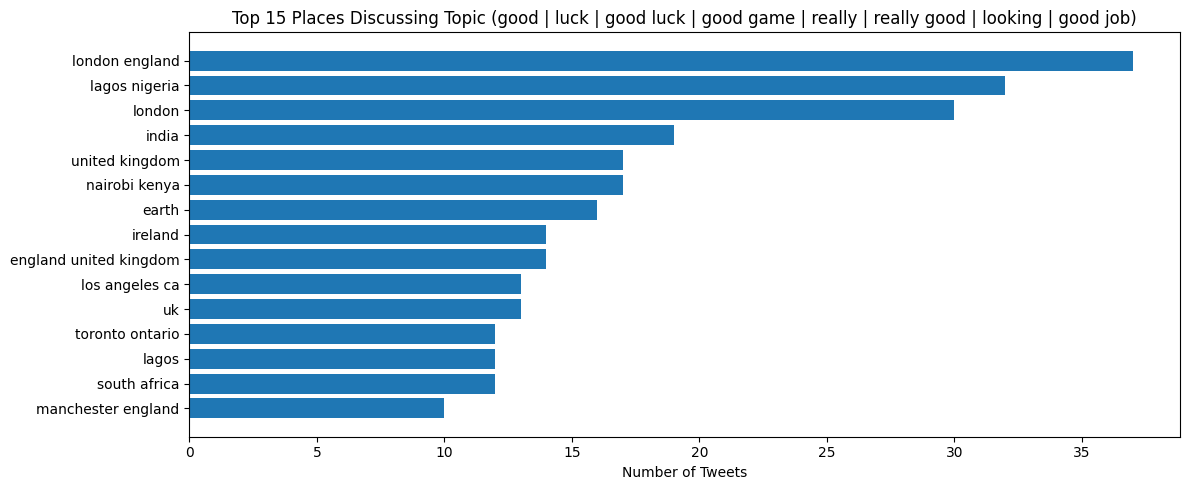

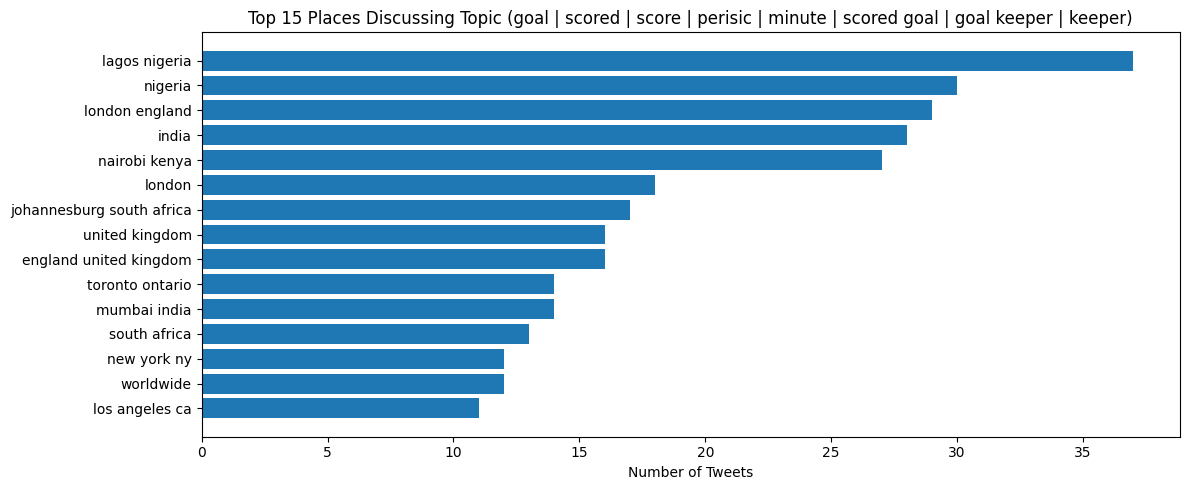

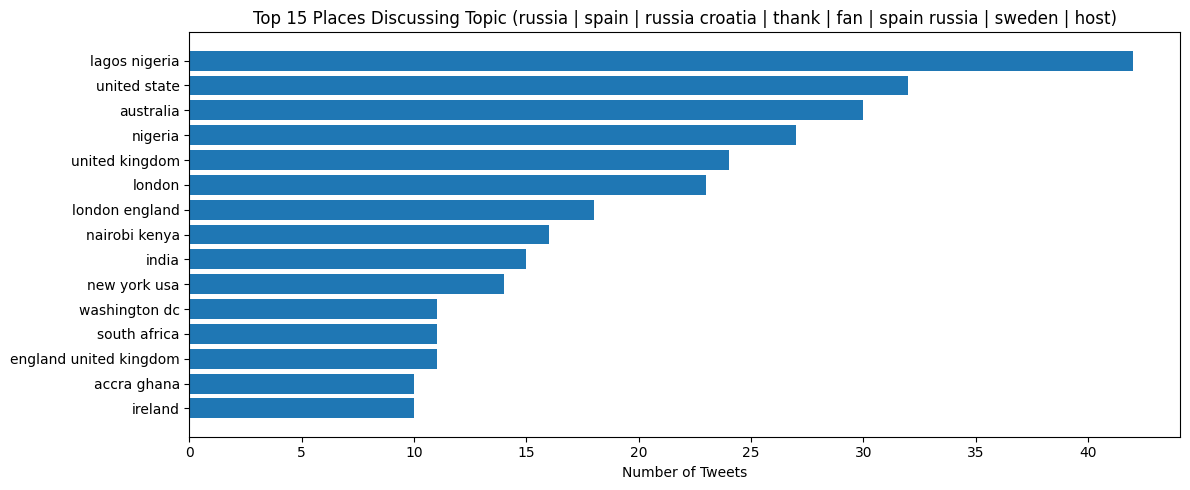

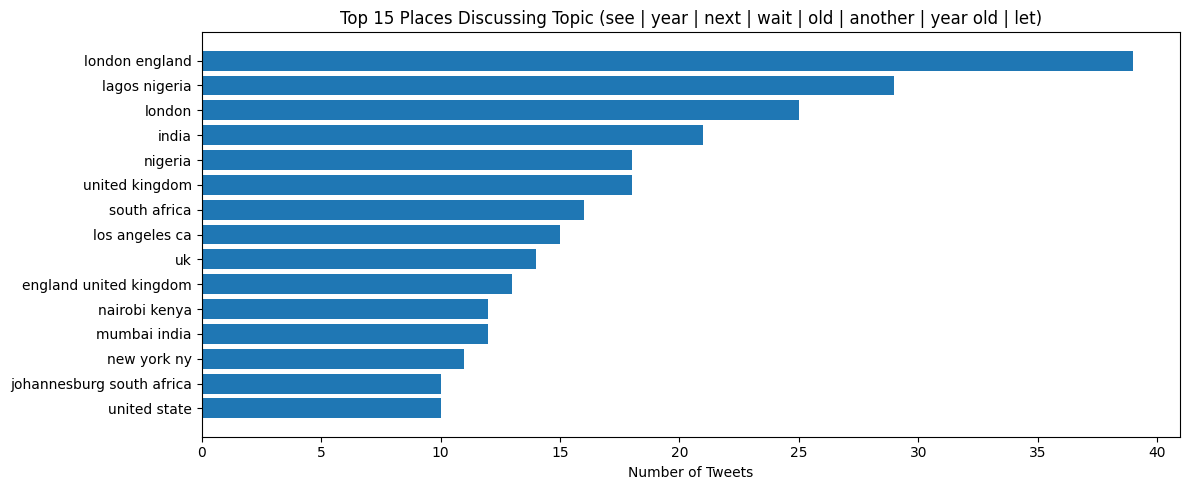

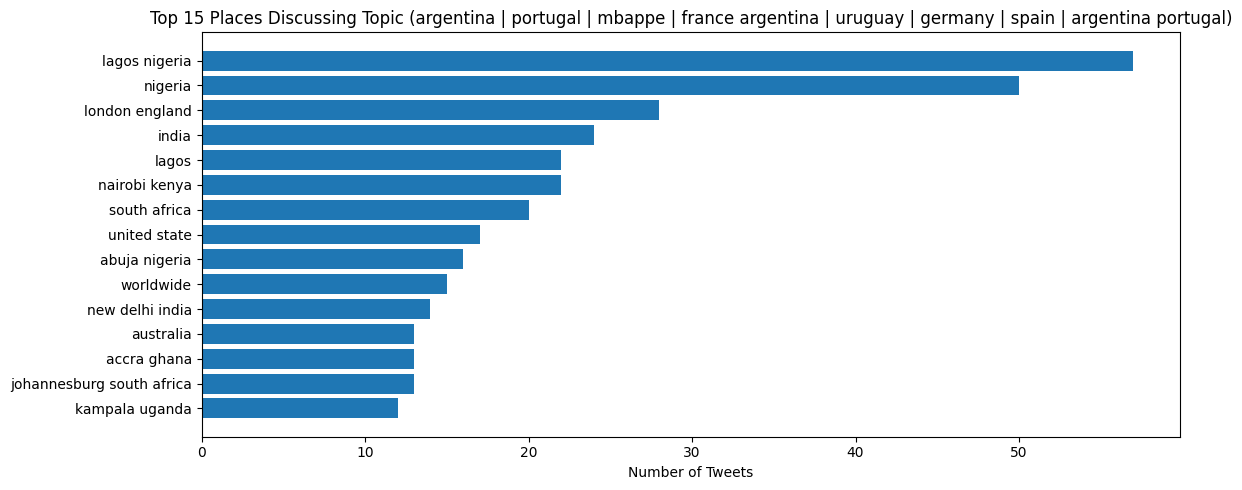

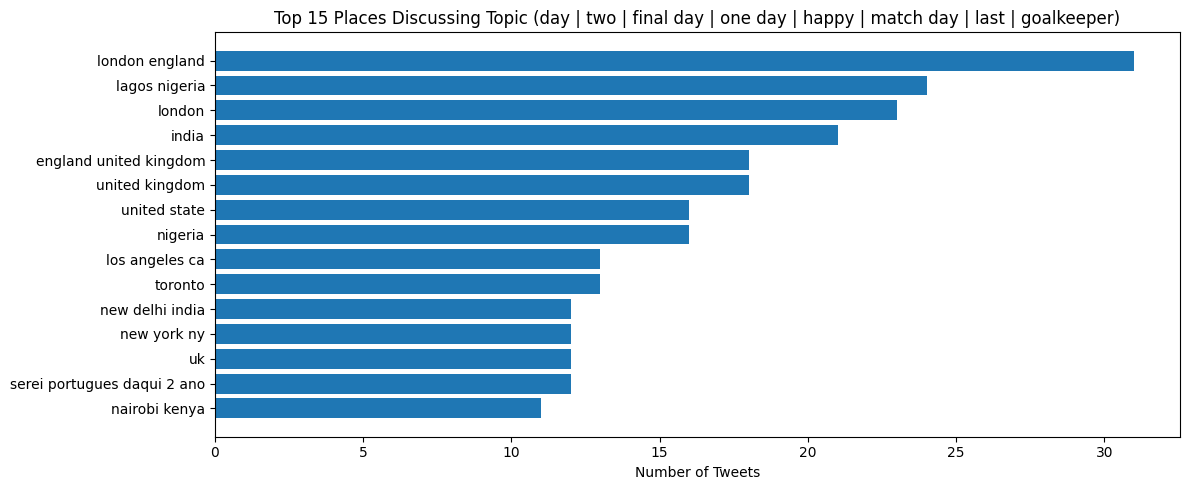

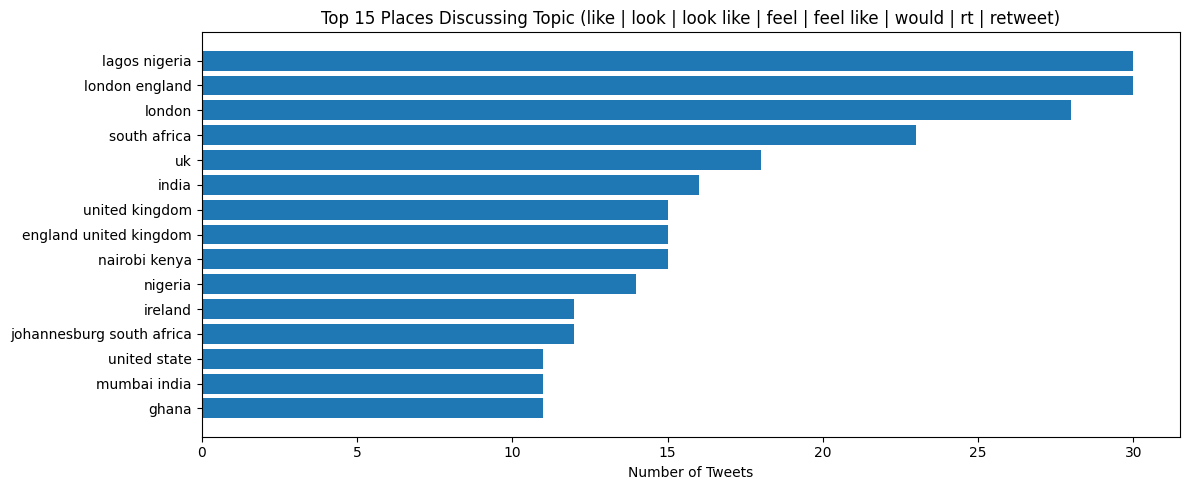

In [75]:
top_topics = (
    df18_nmf["dominant_topic"]
    .value_counts()
    .head(20)
)

place_topics = (
    df18_nmf
    .groupby(["Place", "dominant_topic"])
    .size()
    .reset_index(name="count")
)

top_place_topics = place_topics[
    place_topics["dominant_topic"]
    .isin(top_topics.index)
]

import matplotlib.pyplot as plt

for topic_id in top_topics.index:

    topic_representation = get_nmf_topic_words(
        nmf_model18,
        feature_names18,
        topic_id,
        n_words=8
    )

    topic_places = (
        df18_nmf[
            df18_nmf["dominant_topic"] == topic_id
        ]["Place"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12,5))

    plt.barh(
        topic_places.index,
        topic_places.values
    )

    plt.title(
        f"Top 15 Places Discussing Topic ({topic_representation})"
    )

    plt.xlabel("Number of Tweets")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.show()

* the most discussed topic in each place

In [78]:
import matplotlib.pyplot as plt

def visualize_place_topics_nmf(
    df,
    nmf_model,
    vectorizer,
    place_keyword,
    top_n=10
):

    feature_names = vectorizer.get_feature_names_out()

    subset = df[
        df["Place"].str.contains(
            place_keyword,
            case=False,
            na=False
        )
    ]

    topic_counts = (
        subset["dominant_topic"]
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    topic_counts.columns = [
        "Topic",
        "Count"
    ]

    def get_topic_representation(topic_id):

        topic = nmf_model.components_[topic_id]

        words = [
            feature_names[i]
            for i in topic.argsort()[-5:][::-1]
        ]

        return " | ".join(words)

    topic_counts["Representation"] = (
        topic_counts["Topic"]
        .apply(get_topic_representation)
    )

    plt.figure(figsize=(12,6))

    plt.barh(
        topic_counts["Representation"],
        topic_counts["Count"]
    )

    plt.title(
        f"Most Discussed NMF Topics in '{place_keyword}' during 2018 World Cup"
    )

    plt.xlabel("Tweet Count")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.show()

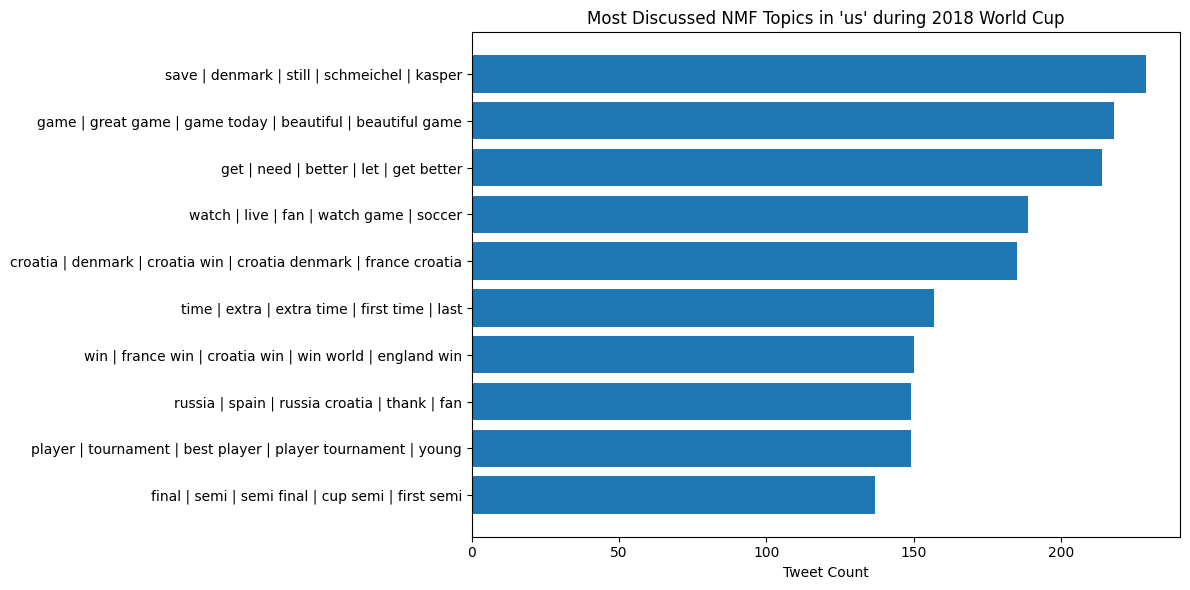

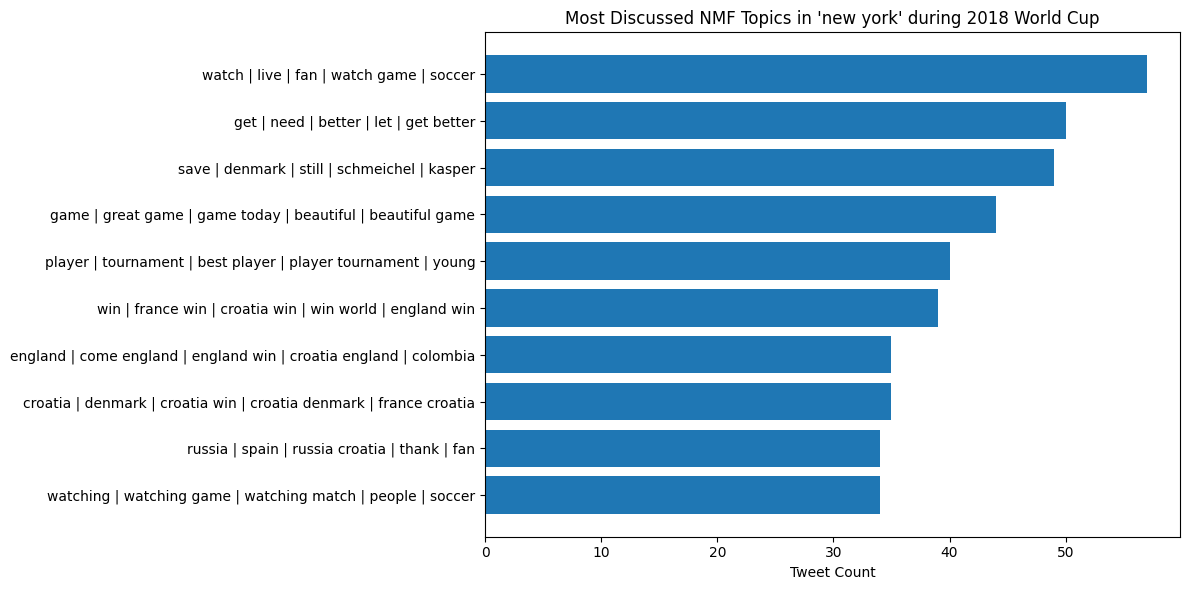

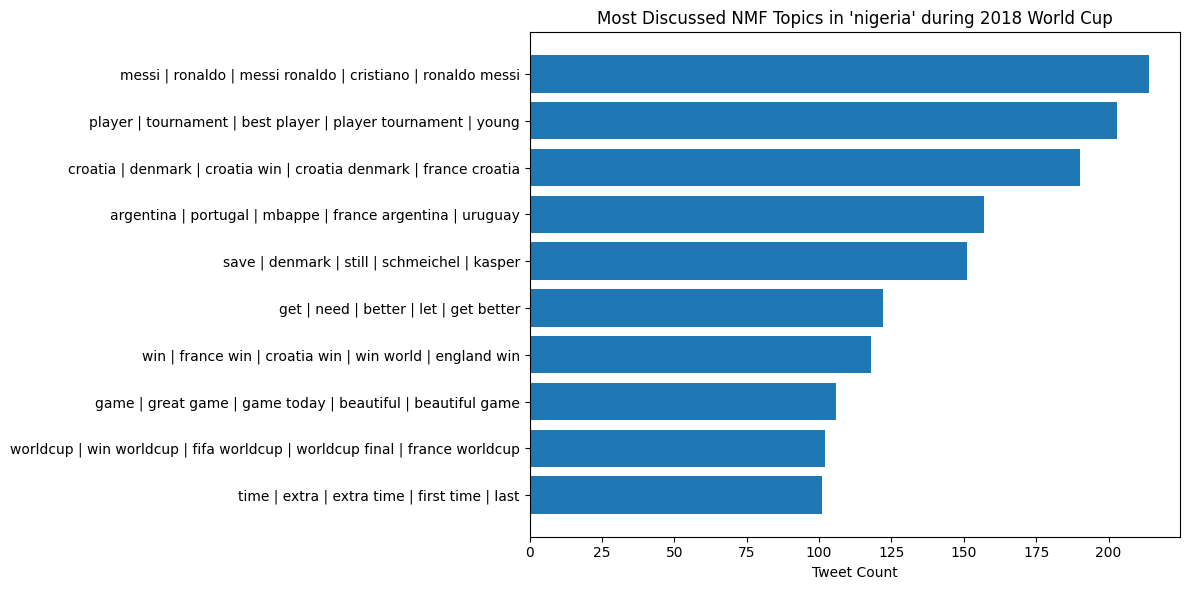

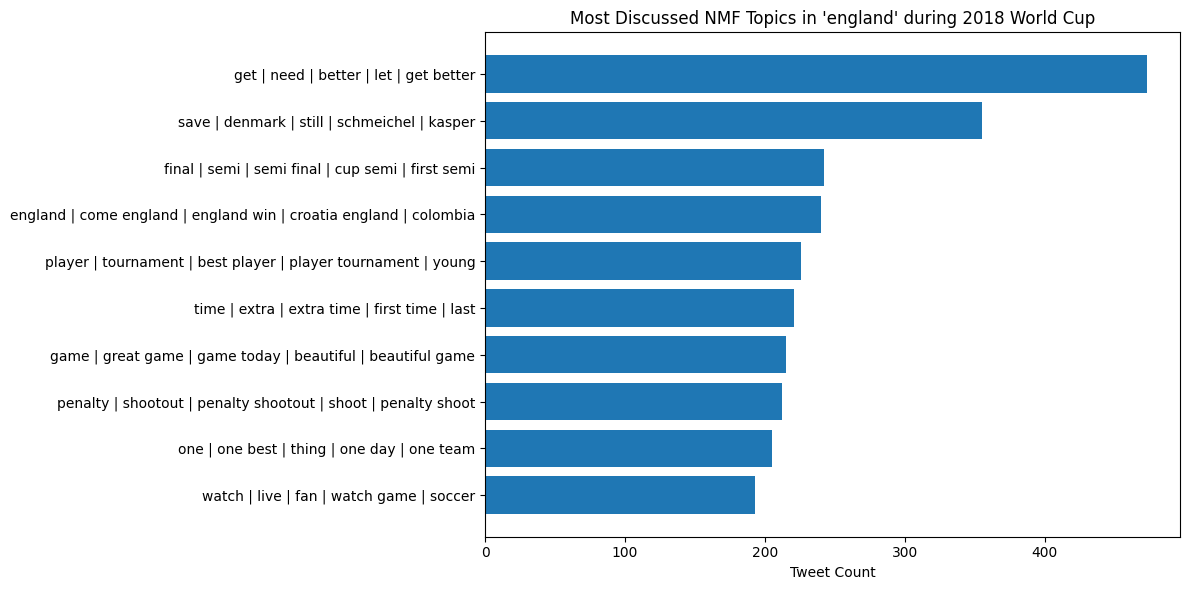

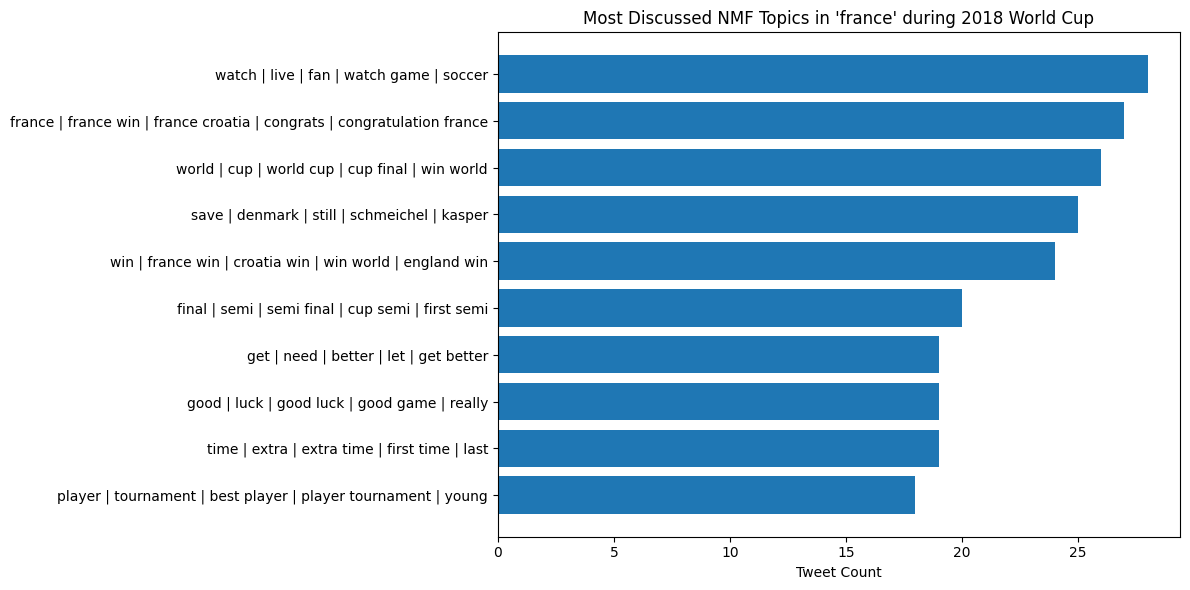

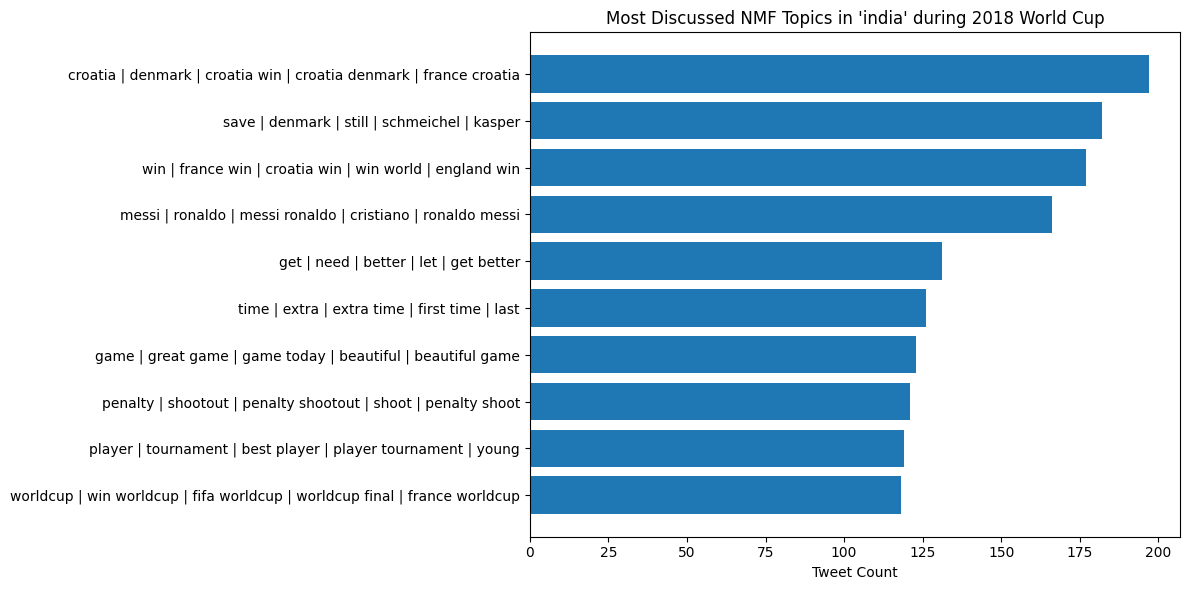

In [79]:
visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "us"
)

visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "new york"
)

visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "nigeria"
)

visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "england"
)

visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "france"
)

visualize_place_topics_nmf(
    df18_nmf,
    nmf_model18,
    vectorizer18,
    "india"
)

* Which places are the most active in discussing the 2018 World Cup?

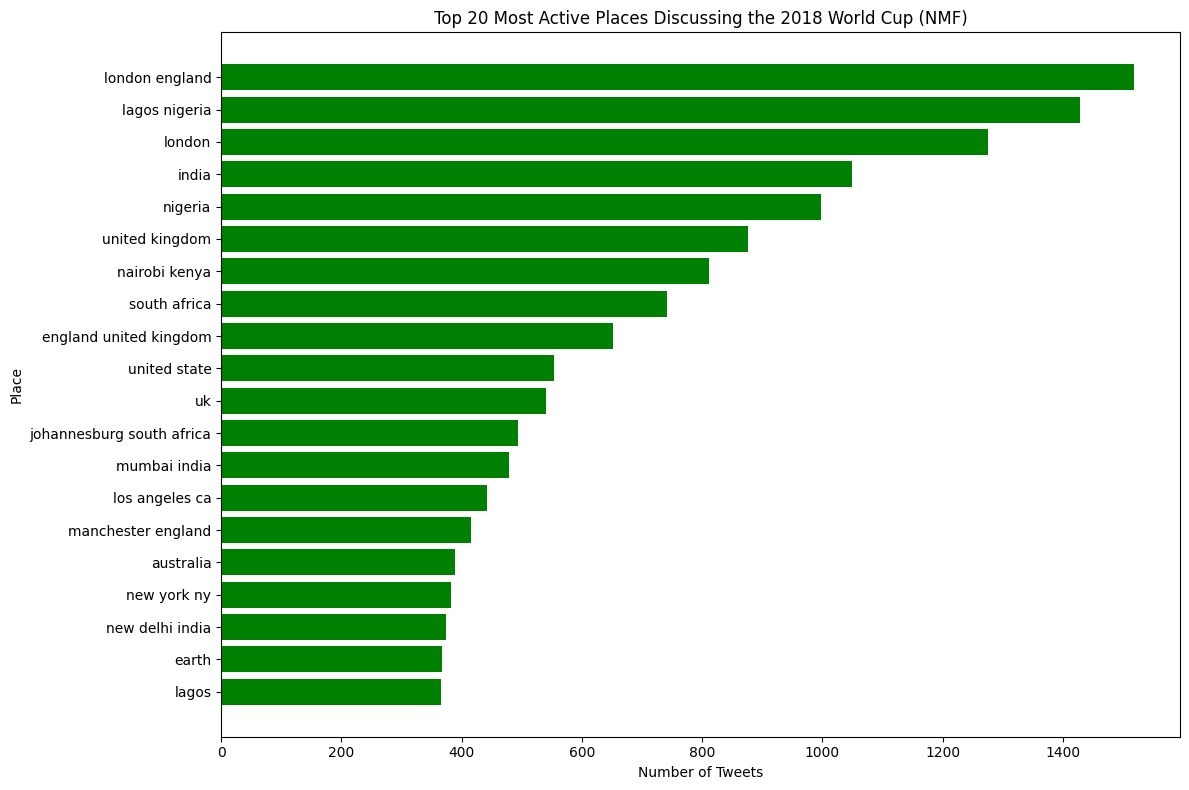

In [80]:
top_places = (
    df18_nmf["Place"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top_places.index,
    top_places.values,
    color="green"
)

plt.xlabel("Number of Tweets")
plt.ylabel("Place")

plt.title(
    "Top 20 Most Active Places Discussing the 2018 World Cup (NMF)"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [81]:
feature_names18 = vectorizer18.get_feature_names_out()

topic_likes = (
    df18_nmf
    .groupby("dominant_topic")["Likes"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

topic_likes["Representation"] = topic_likes["dominant_topic"].apply(
    lambda t: " | ".join(
        feature_names18[i]
        for i in nmf_model18.components_[t].argsort()[-5:][::-1]
    )
)

topic_likes.head(10)

,dominant_topic,Likes,Representation
0,26,2.774253,one | one best | thing | one day | one team
1,41,2.375325,right | fan | need | fan right | left
2,10,2.372930,play | please | please play | play power | fair
3,33,2.331881,russia | spain | russia croatia | thank | fan
4,24,2.266526,golden | ball | modric | golden ball | winner
5,17,2.221371,go | let | let go | go home | way
6,21,2.116438,love | fake | fake love | would | much
7,31,2.100796,good | luck | good luck | good game | really
8,44,2.051444,save | denmark | still | schmeichel | kasper
9,40,1.992440,player | tournament | best player | player tou...


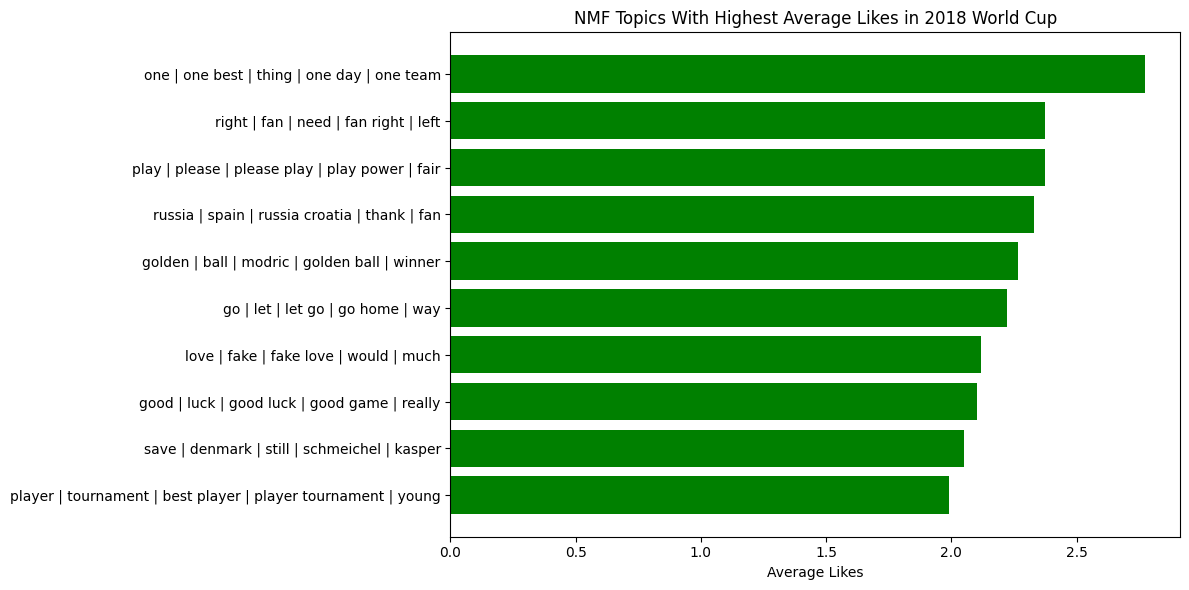

In [82]:
top_liked_topics = topic_likes.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_liked_topics["Representation"],
    top_liked_topics["Likes"],
    color="green"
)

plt.xlabel("Average Likes")

plt.title(
    "NMF Topics With Highest Average Likes in 2018 World Cup"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

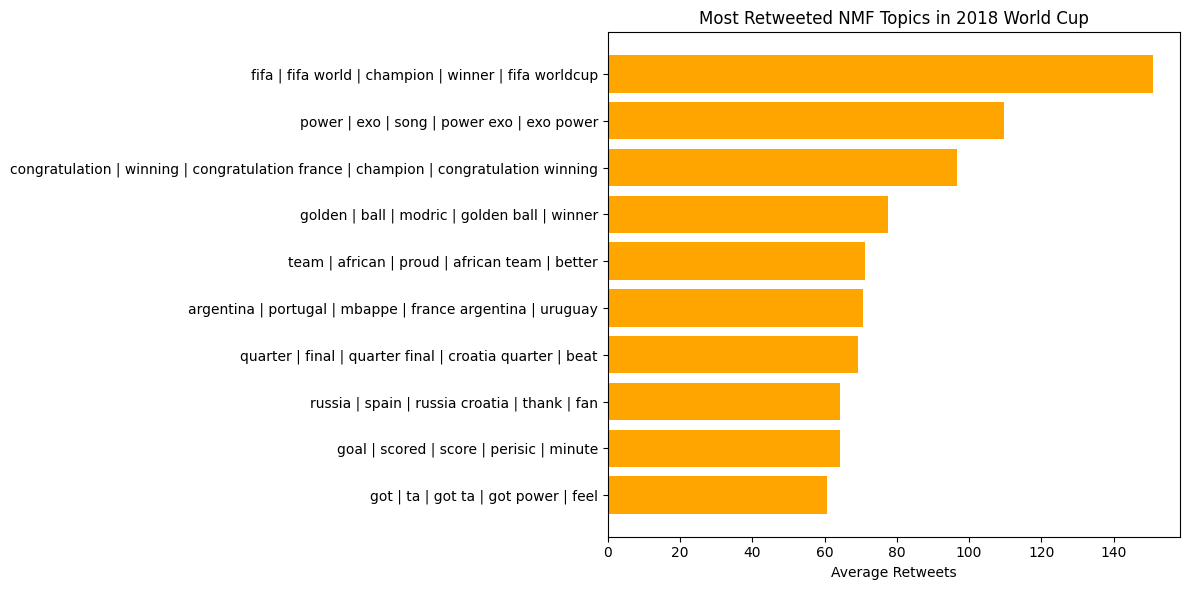

In [83]:
feature_names18 = vectorizer18.get_feature_names_out()

topic_retweets = (
    df18_nmf
    .groupby("dominant_topic")["RTs"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

topic_retweets["Representation"] = topic_retweets["dominant_topic"].apply(
    lambda t: " | ".join(
        feature_names18[i]
        for i in nmf_model18.components_[t].argsort()[-5:][::-1]
    )
)

top_retweeted_topics = topic_retweets.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_retweeted_topics["Representation"],
    top_retweeted_topics["RTs"],
    color="orange"
)

plt.xlabel("Average Retweets")

plt.title(
    "Most Retweeted NMF Topics in 2018 World Cup"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

**2022 World Cup**

* Which topics are the most positive and the most negative?

In [90]:
feature_names22 = vectorizer22.get_feature_names_out()

positive_df = df22_nmf[
    df22_nmf["Sentiment"] == "['positive']"
]

top_positive = (
    positive_df["dominant_topic"]
    .value_counts()
    .head(10)
)

rows = []

for topic_id, count in top_positive.items():

    words = [
        feature_names22[i]
        for i in nmf_model22.components_[topic_id]
        .argsort()[-5:][::-1]
    ]

    rows.append({
        "dominant_topic": topic_id,
        "Count": count,
        "Representation": " | ".join(words)
    })

positive_topics_df = pd.DataFrame(rows)

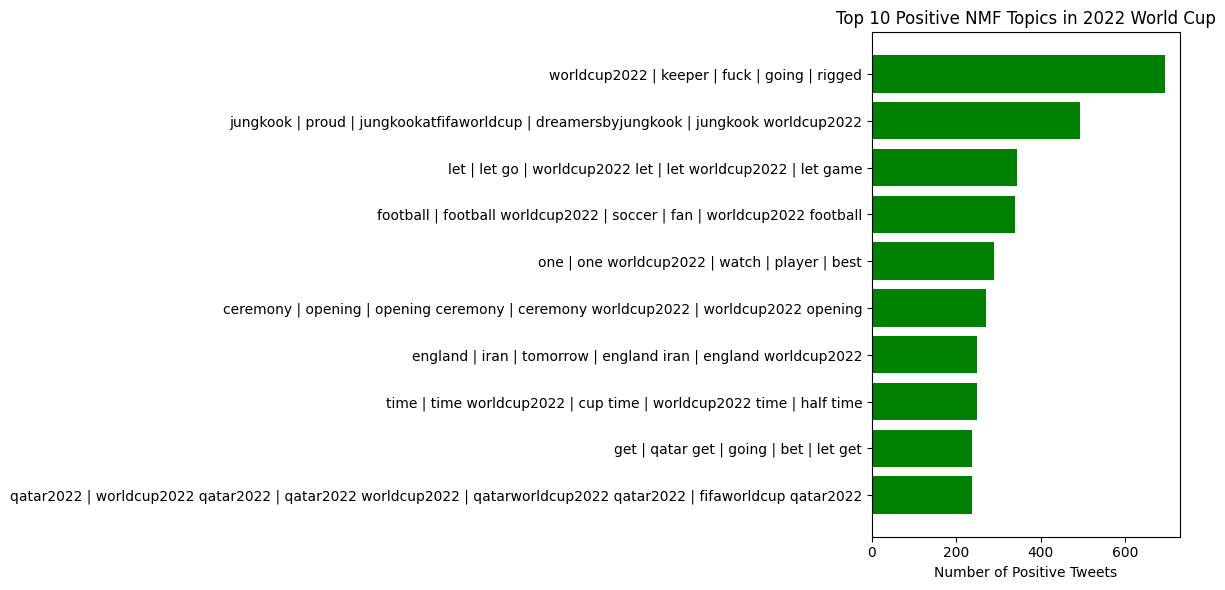

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    positive_topics_df["Representation"],
    positive_topics_df["Count"],
    color="green"
)

plt.title(
    "Top 10 Positive NMF Topics in 2022 World Cup"
)

plt.xlabel(
    "Number of Positive Tweets"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [92]:
feature_names22 = vectorizer22.get_feature_names_out()

negative_df = df22_nmf[
    df22_nmf["Sentiment"] == "['negative']"
]

top_negative = (
    negative_df["dominant_topic"]
    .value_counts()
    .head(10)
)

rows = []

for topic_id, count in top_negative.items():

    words = [
        feature_names22[i]
        for i in nmf_model22.components_[topic_id]
        .argsort()[-5:][::-1]
    ]

    rows.append({
        "dominant_topic": topic_id,
        "Count": count,
        "Representation": " | ".join(words)
    })

negative_topics_df = pd.DataFrame(rows)

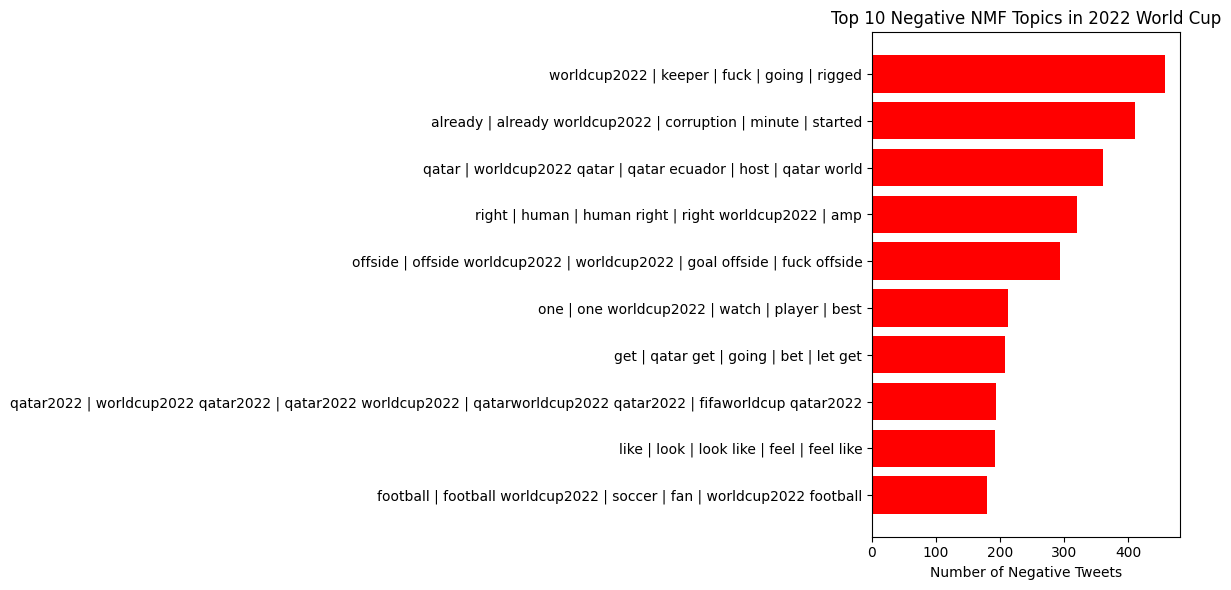

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    negative_topics_df["Representation"],
    negative_topics_df["Count"],
    color="red"
)

plt.title(
    "Top 10 Negative NMF Topics in 2022 World Cup"
)

plt.xlabel(
    "Number of Negative Tweets"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* Which topics receive the most likes?

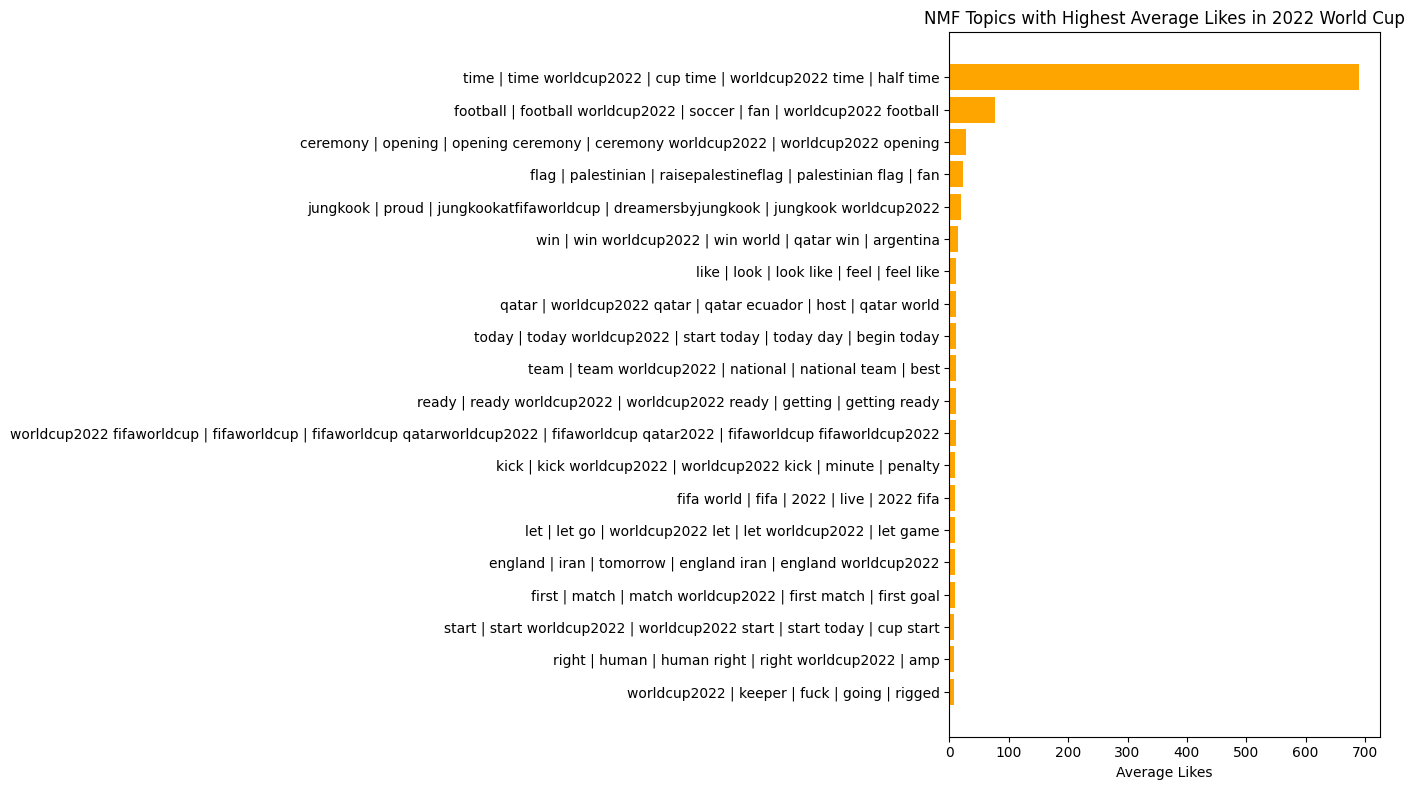

In [94]:
feature_names22 = vectorizer22.get_feature_names_out()

liked_topics = (
    df22_nmf
    .groupby("dominant_topic")["Number of Likes"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

liked_df = pd.DataFrame({
    "dominant_topic": liked_topics.index,
    "AvgLikes": liked_topics.values
})

liked_df["Representation"] = liked_df["dominant_topic"].apply(
    lambda t: " | ".join(
        feature_names22[i]
        for i in nmf_model22.components_[t]
        .argsort()[-5:][::-1]
    )
)

plt.figure(figsize=(14,8))

plt.barh(
    liked_df["Representation"],
    liked_df["AvgLikes"],
    color="orange"
)

plt.title(
    "NMF Topics with Highest Average Likes in 2022 World Cup"
)

plt.xlabel(
    "Average Likes"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* Which topics are the most controversial? ( positive and negative together)

In [95]:
feature_names22 = vectorizer22.get_feature_names_out()

# Topic x Sentiment table
sent_topic = pd.crosstab(
    df22_nmf["dominant_topic"],
    df22_nmf["Sentiment"]
)

# Controversy score:
# topic is controversial if it has many positive AND many negative tweets
sent_topic["controversy_score"] = (
    sent_topic[["['positive']", "['negative']"]]
    .min(axis=1)
)

# Top 10 controversial topics
top_controversial = (
    sent_topic
    .sort_values(
        "controversy_score",
        ascending=False
    )
    .head(10)
)

rows = []

for topic_id in top_controversial.index:

    words = [
        feature_names22[i]
        for i in nmf_model22.components_[topic_id]
        .argsort()[-5:][::-1]
    ]

    rows.append({
        "dominant_topic": topic_id,
        "Representation": " | ".join(words),
        "Positive": top_controversial.loc[
            topic_id,
            "['positive']"
        ],
        "Negative": top_controversial.loc[
            topic_id,
            "['negative']"
        ],
        "Controversy Score": top_controversial.loc[
            topic_id,
            "controversy_score"
        ]
    })

controversial_df = pd.DataFrame(rows)

controversial_df

,dominant_topic,Representation,Positive,Negative,Controversy Score
0,1,worldcup2022 | keeper | fuck | going | rigged,695,458,458
1,49,one | one worldcup2022 | watch | player | best,288,212,212
2,47,get | qatar get | going | bet | let get,237,207,207
3,10,qatar2022 | worldcup2022 qatar2022 | qatar2022...,236,194,194
4,31,football | football worldcup2022 | soccer | fa...,338,179,179
5,18,worldcupqatar2022 | worldcup2022 worldcupqatar...,204,179,179
6,15,qatar | worldcup2022 qatar | qatar ecuador | h...,173,360,173
7,3,ceremony | opening | opening ceremony | ceremo...,270,154,154
8,45,game | game worldcup2022 | opening game | firs...,198,152,152
9,48,right | human | human right | right worldcup20...,142,320,142


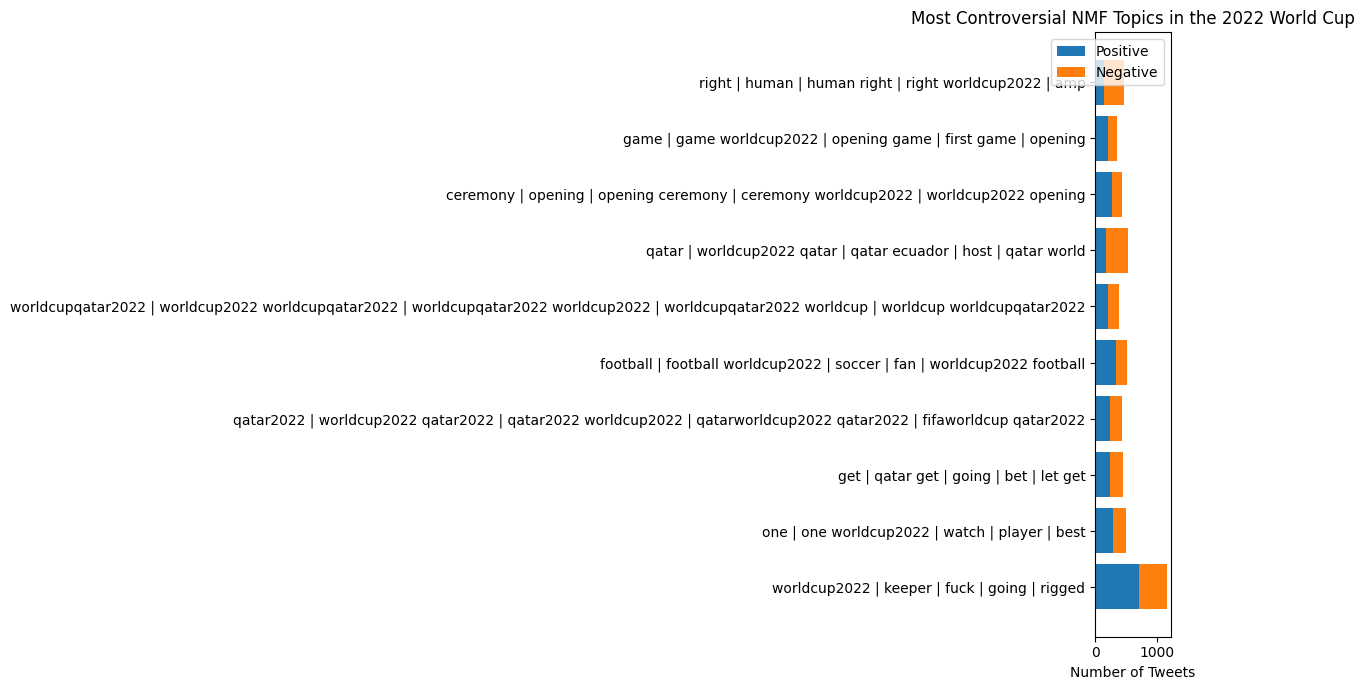

In [96]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,7))

y = np.arange(len(controversial_df))

plt.barh(
    y,
    controversial_df["Positive"],
    label="Positive"
)

plt.barh(
    y,
    controversial_df["Negative"],
    left=controversial_df["Positive"],
    label="Negative"
)

plt.yticks(
    y,
    controversial_df["Representation"]
)

plt.xlabel(
    "Number of Tweets"
)

plt.title(
    "Most Controversial NMF Topics in the 2022 World Cup"
)

plt.legend()

plt.tight_layout()

plt.show()

# Using BIRTopic Modeling

In [26]:
import pandas as pd
from bertopic import BERTopic
df18 = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2018_bertopic_topics.csv"
)

topic_info18 = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2018_bertopic_topic_info.csv"
)

df22 = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2022_bertopic_topics.csv"
)

topic_info22 = pd.read_csv(
    r"C:\Projects\worldcup-social-media-nlp\results\worldcup2022_bertopic_topic_info.csv"
)

topic_model18 = BERTopic.load(
    r"C:\Projects\worldcup-social-media-nlp\models\worldcup2018_bertopic"
)

topic_model22 = BERTopic.load(
    r"C:\Projects\worldcup-social-media-nlp\models\worldcup2022_bertopic"
)

**worldcup 2018**

In [57]:
df18.columns

Index(['Unnamed: 0', 'Date', 'Source', 'Tweet', 'Likes', 'RTs', 'Hashtags',
       'Place', 'topic'],
      dtype='str')

In [58]:
df18["Place"].value_counts().head(50)

Place
london england               1519
lagos nigeria                1429
london                       1276
india                        1049
nigeria                       998
united kingdom                877
nairobi kenya                 812
south africa                  742
england united kingdom        652
united state                  554
uk                            540
johannesburg south africa     493
mumbai india                  478
los angeles ca                442
manchester england            415
australia                     389
new york ny                   383
new delhi india               374
earth                         368
lagos                         366
accra ghana                   362
ireland                       322
worldwide                     317
toronto ontario               309
washington dc                 309
kampala uganda                298
abuja nigeria                 296
london uk                     292
toronto                       282
england 

* Which topics dominated discussion during the tournament?

In [4]:
top_topics = (
    df18["topic"]
    .value_counts()
    .head(20)
)
top_topics = top_topics[top_topics.index != -1]
top_topics

topic
0     1621
1      679
2      600
3      569
4      520
5      511
6      511
7      475
8      448
9      447
10     439
11     414
13     389
12     389
14     383
15     359
16     357
17     354
18     337
Name: count, dtype: int64

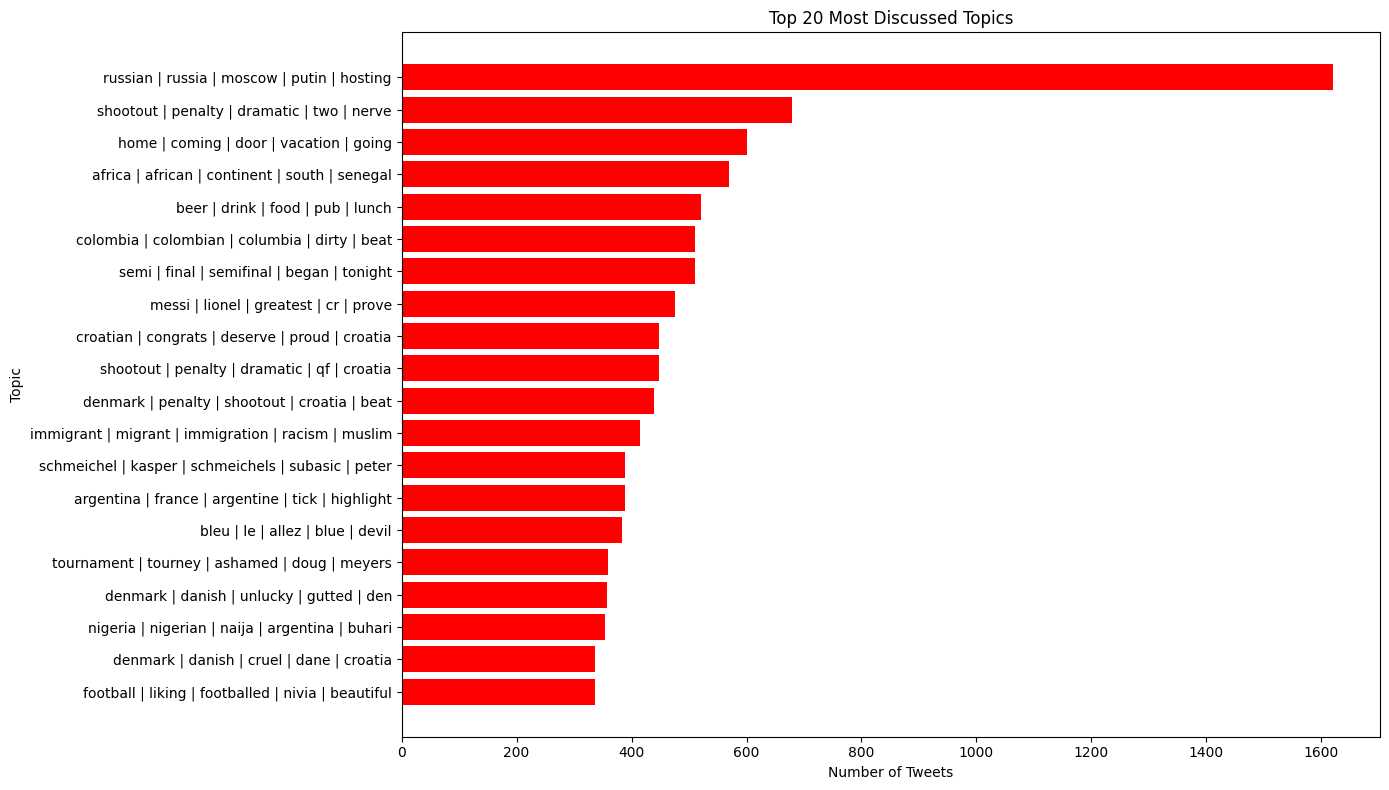

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

top_topics = (
    df18[df18["topic"] != -1]["topic"]
    .value_counts()
    .head(20)
)

topic_df = pd.DataFrame({
    "Topic": top_topics.index,
    "Count": top_topics.values
})

topic_df["Representation"] = topic_df["Topic"].apply(
    lambda t: " | ".join(
        word
        for word, score
        in topic_model18.get_topic(t)[:5]
    )
)

plt.figure(figsize=(14,8))

plt.barh(
    topic_df["Representation"],
    topic_df["Count"],
    color="red"
)

plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.title("Top 20 Most Discussed Topics")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* Do fans from different places focus on different themes and Are some topics niche or universal? (in 2018 worlcup)

In [17]:
top_topics = (
    df18["topic"]
    .value_counts()
    .head(30)
)


place_topics = (
    df18.groupby(["Place", "topic"])
        .size()
        .reset_index(name="count")
)

top_place_topics = place_topics[
    place_topics["topic"].isin(top_topics.index)
]
#for topic_id in top_topics.index:

    #print(f"\n===== Topic {topic_id} =====")

    #display(
        #top_place_topics[
            #top_place_topics["topic"] == topic_id
        #]
       # .sort_values("count", ascending=False)
       # .head(10)
    #)

In [18]:
#remove -1 (because in BERTopic -1 is usually the outlier topic)
top_topics = top_topics[top_topics.index != -1]
top_topics

topic
0     1621
1      679
2      600
3      569
4      520
5      511
6      511
7      475
8      448
9      447
10     439
11     414
13     389
12     389
14     383
15     359
16     357
17     354
18     337
19     337
20     318
21     312
22     310
23     304
24     292
25     286
26     269
27     267
28     266
Name: count, dtype: int64

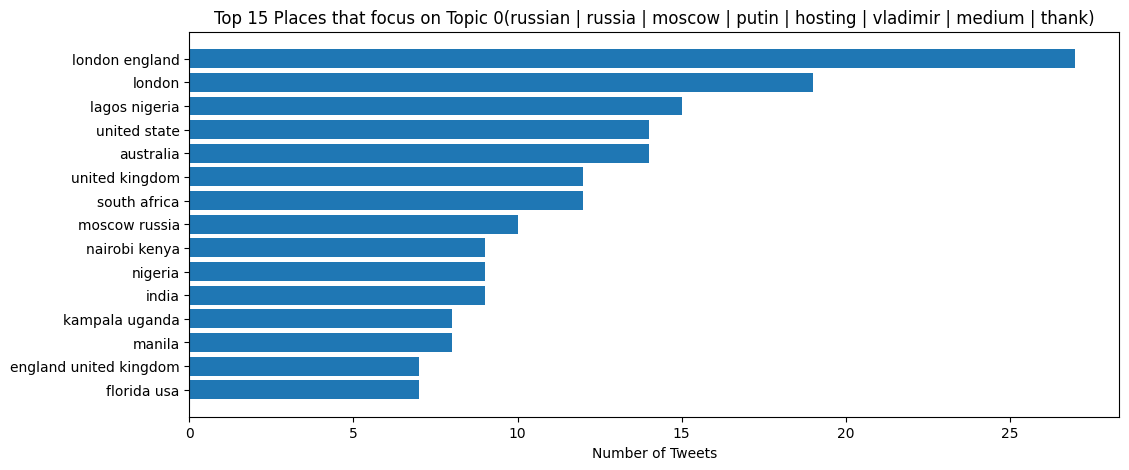

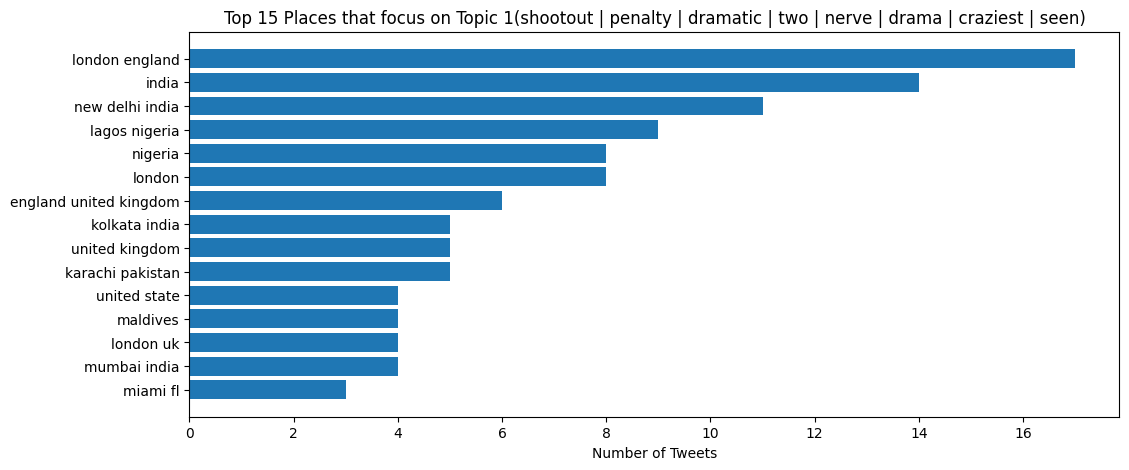

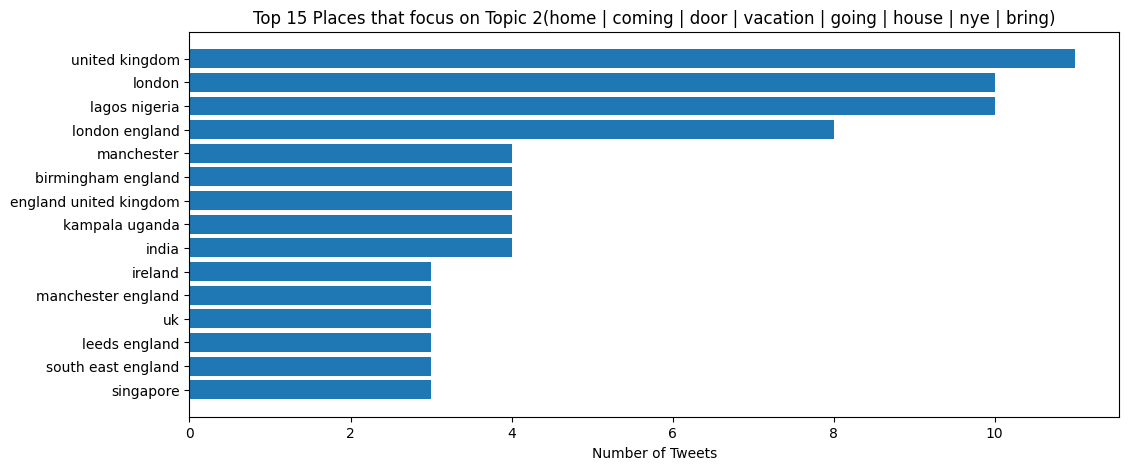

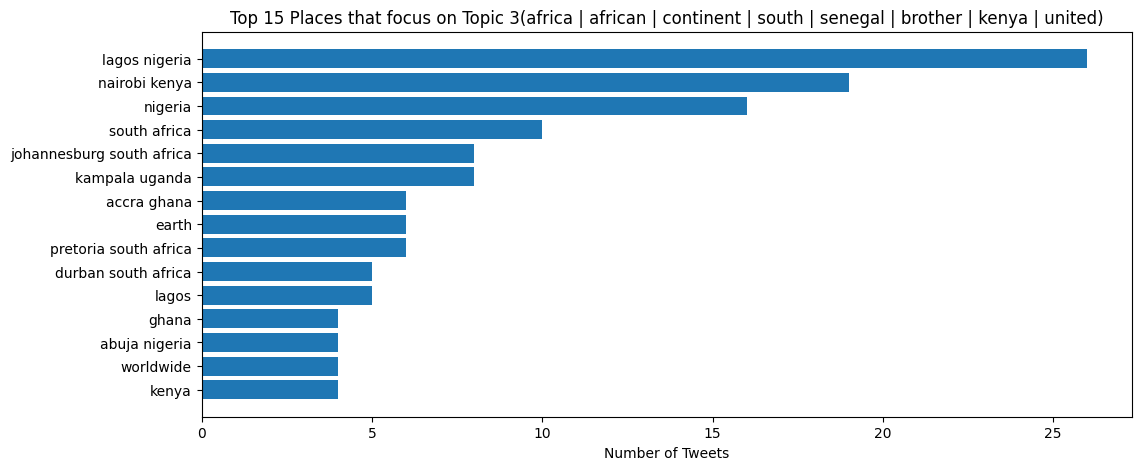

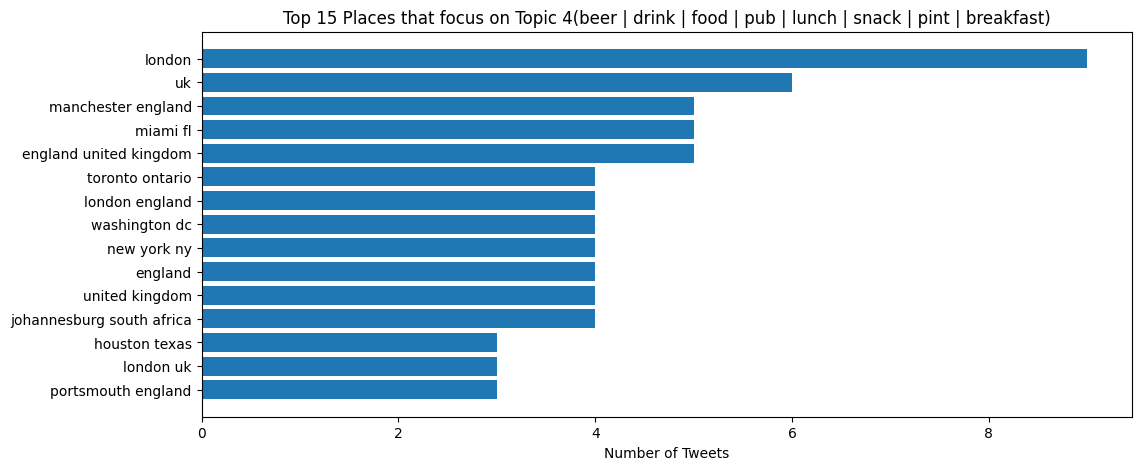

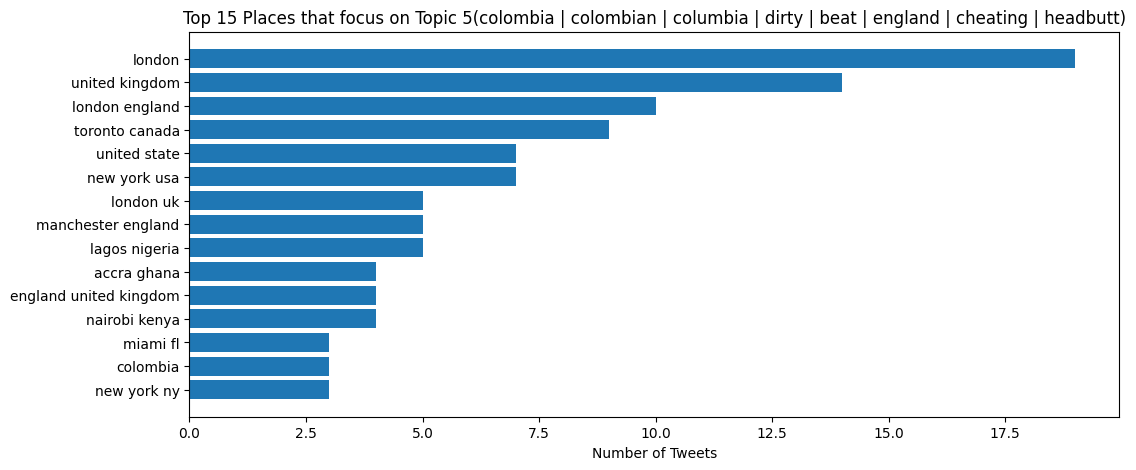

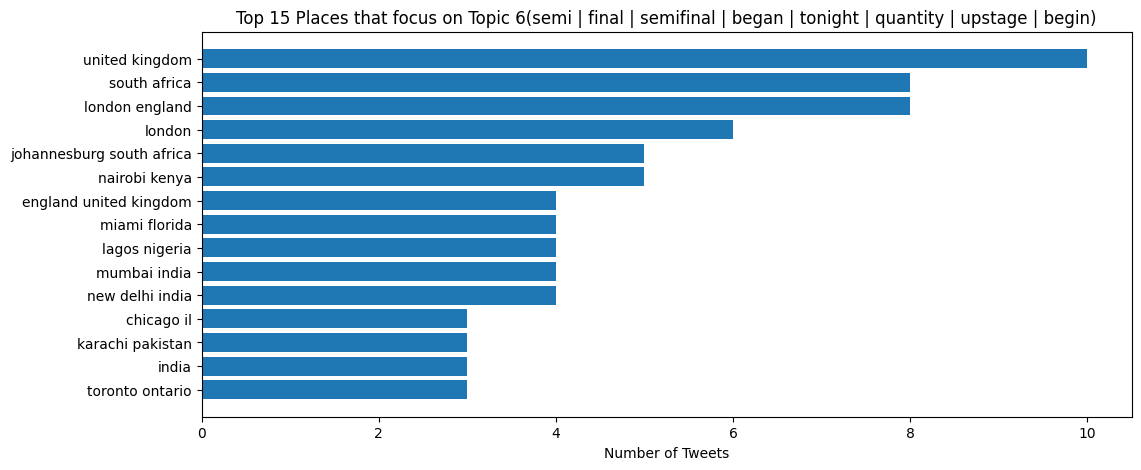

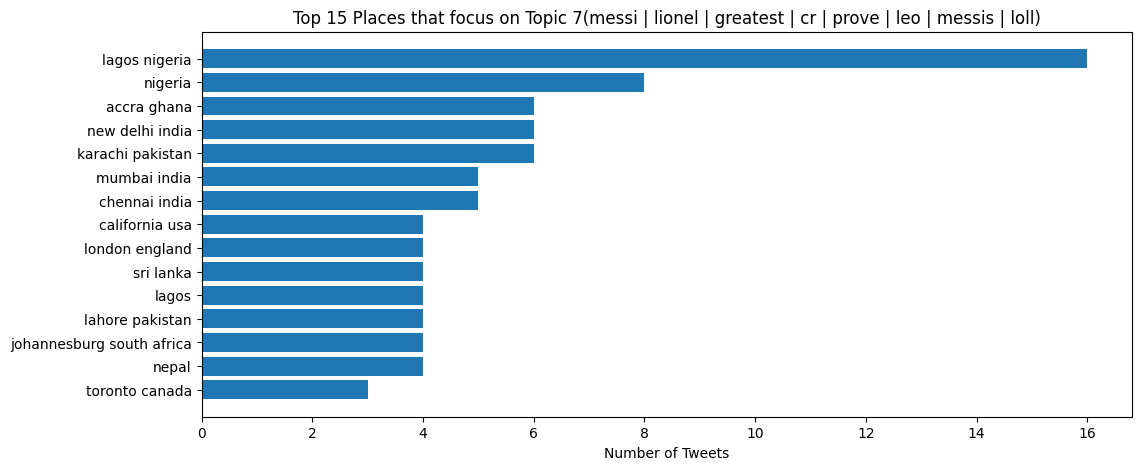

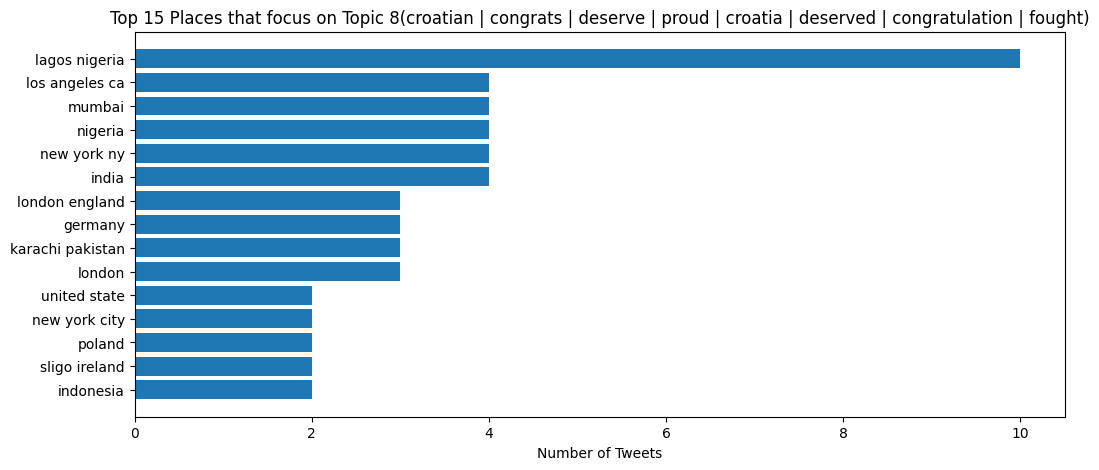

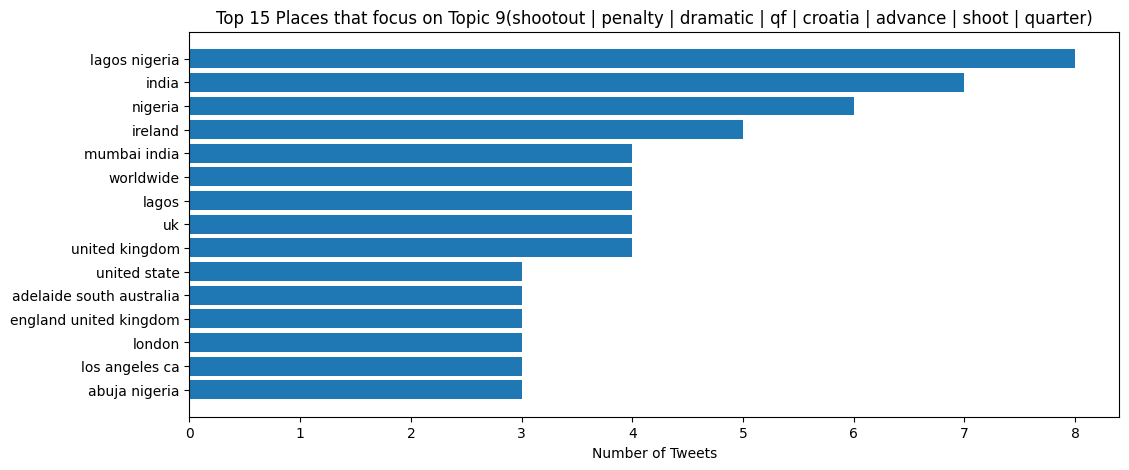

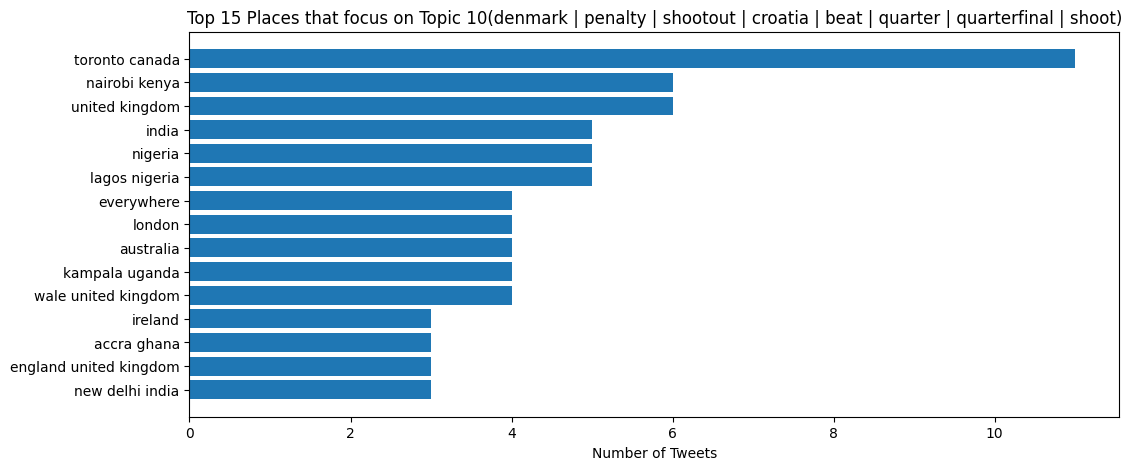

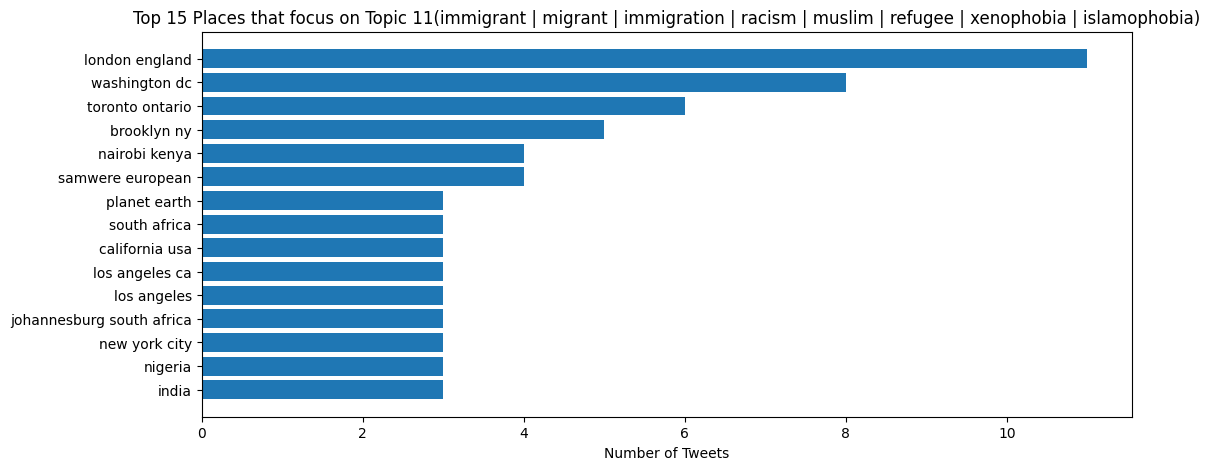

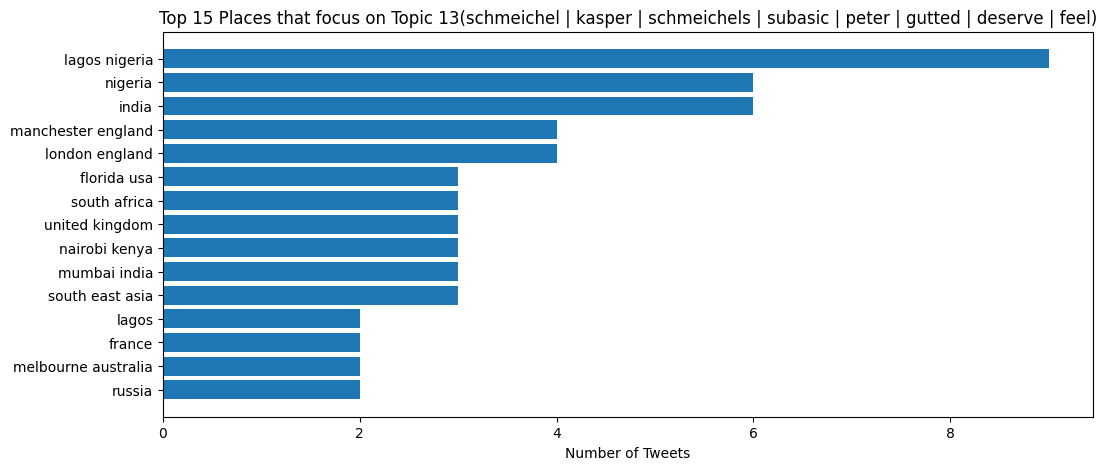

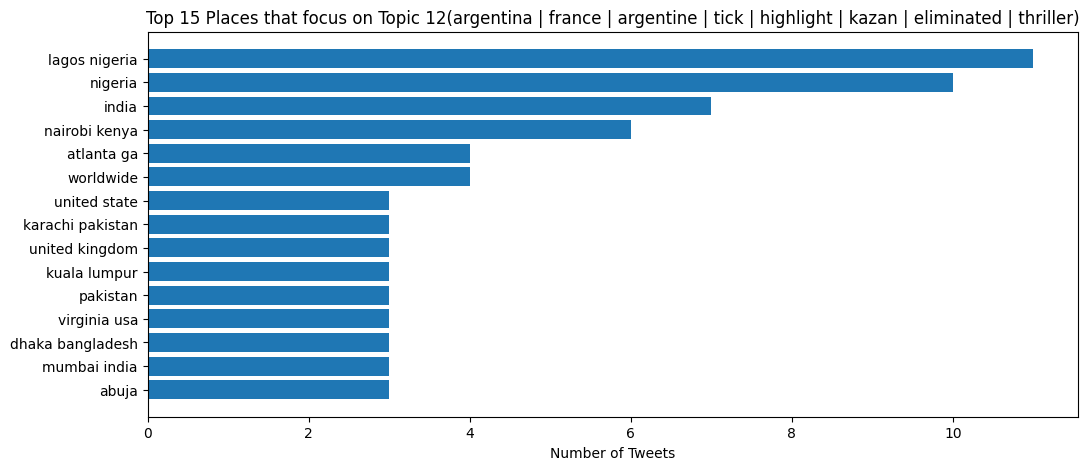

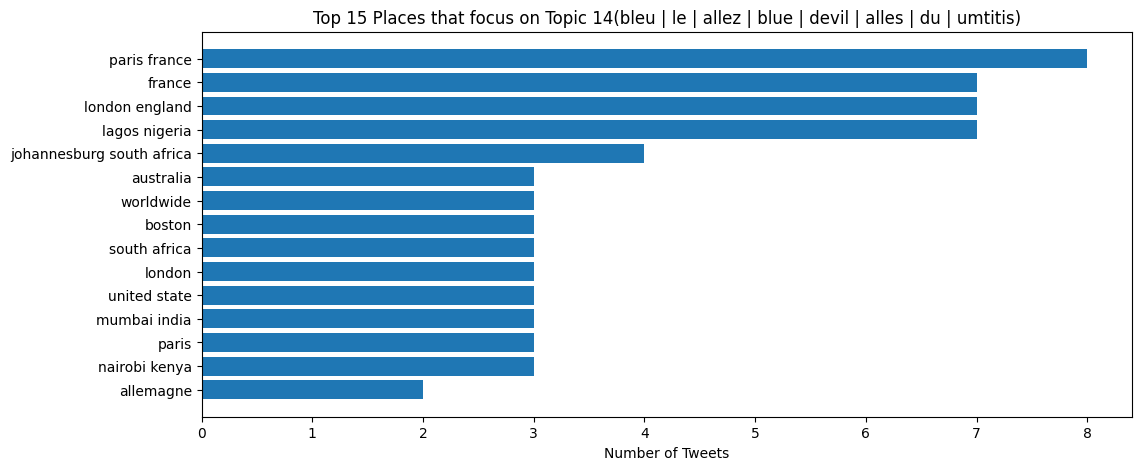

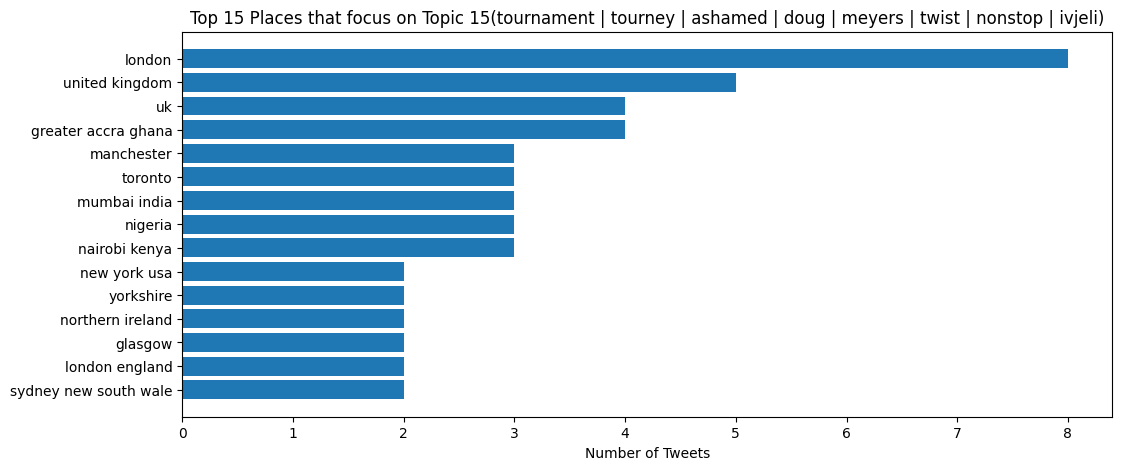

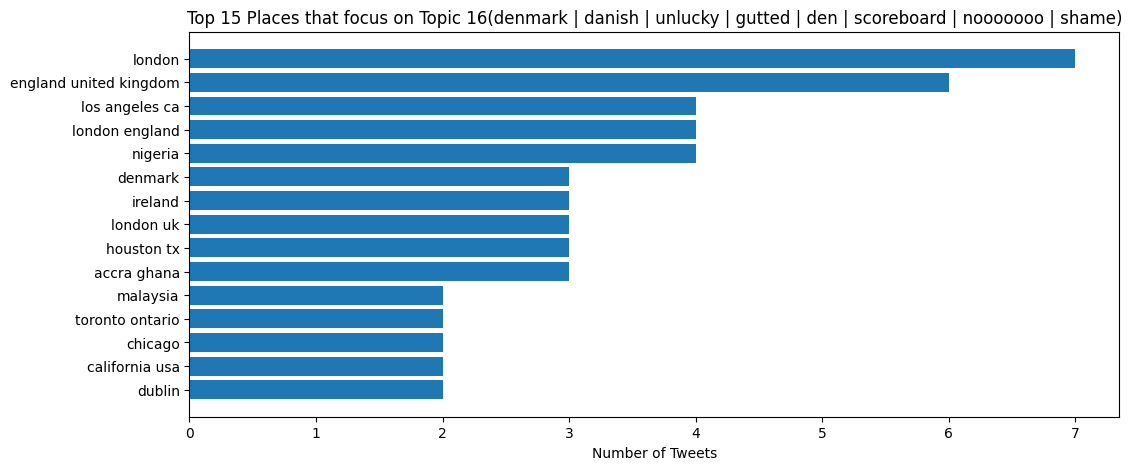

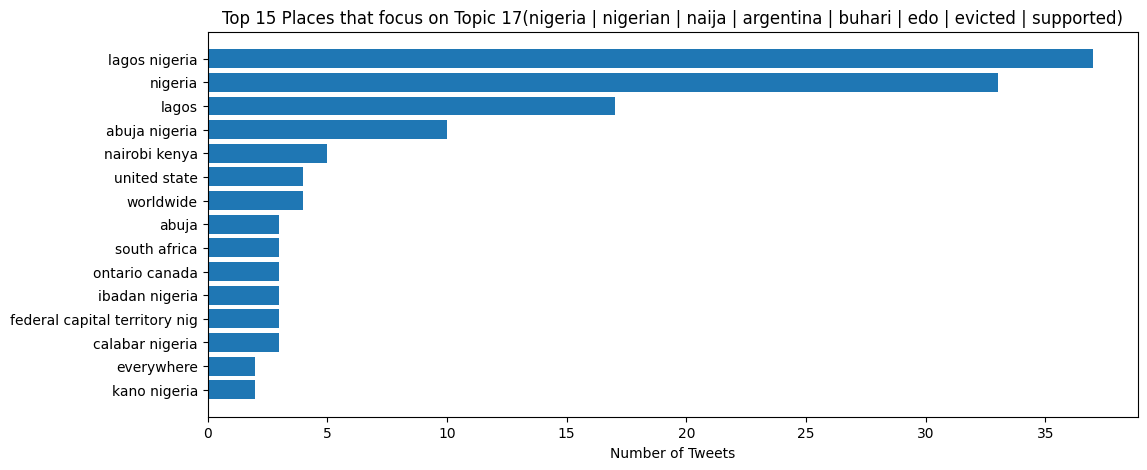

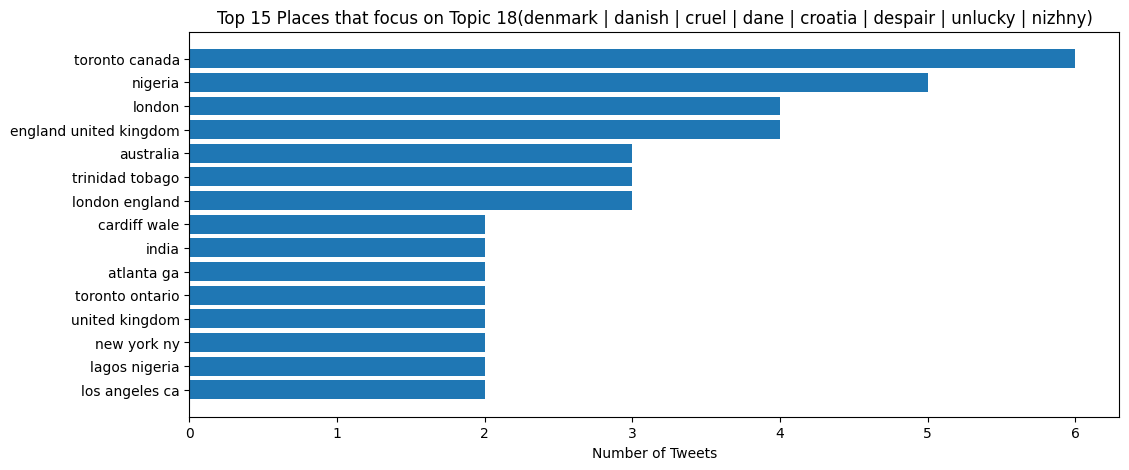

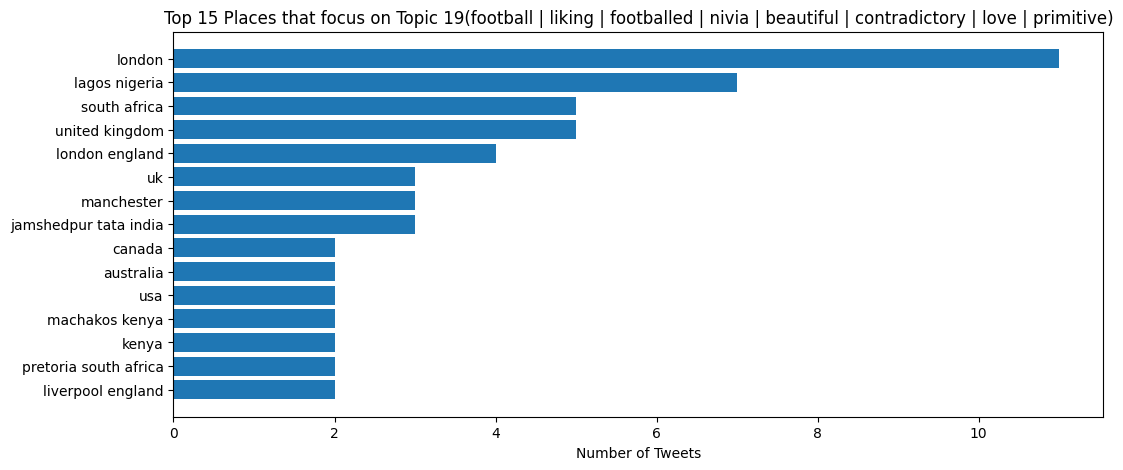

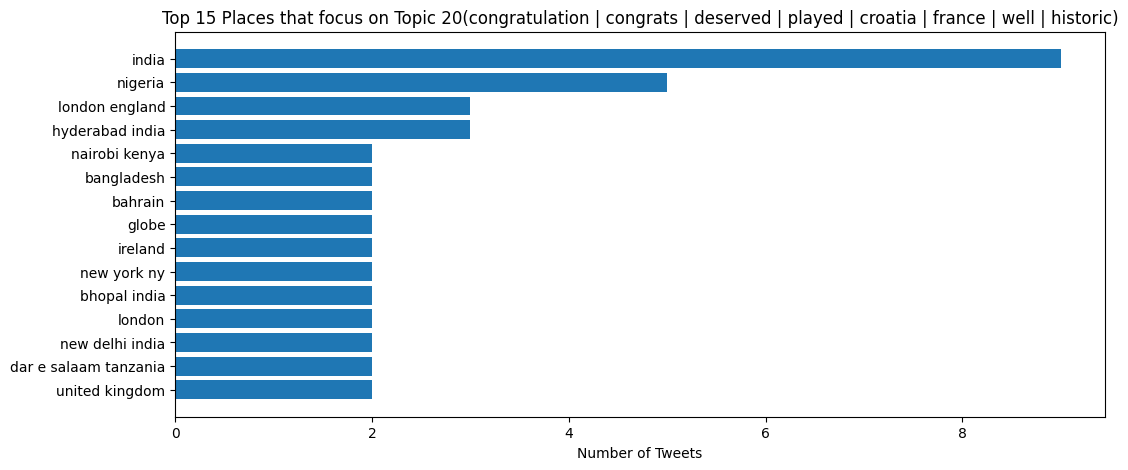

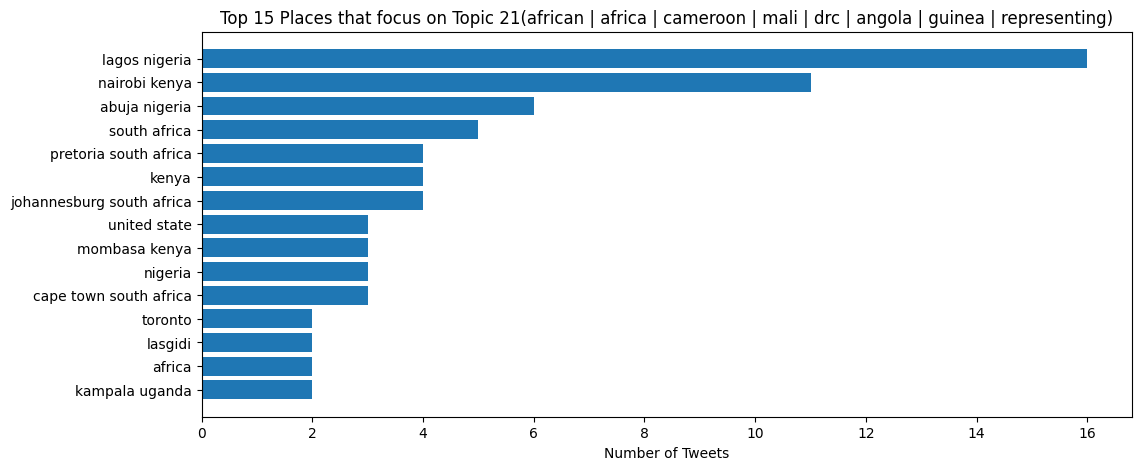

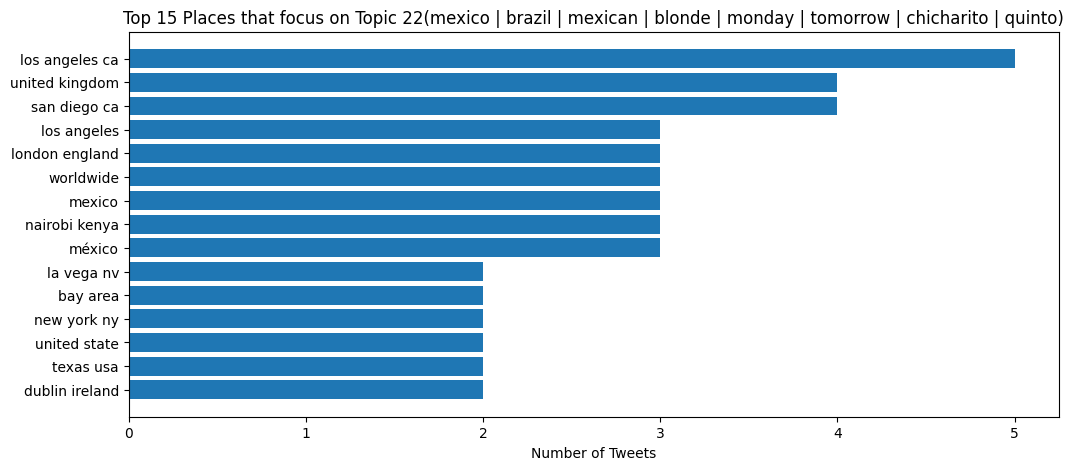

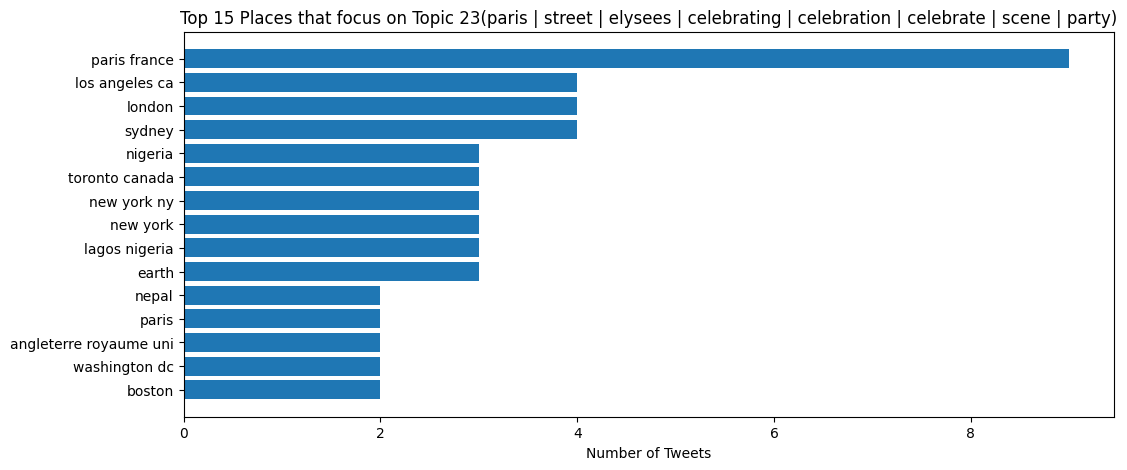

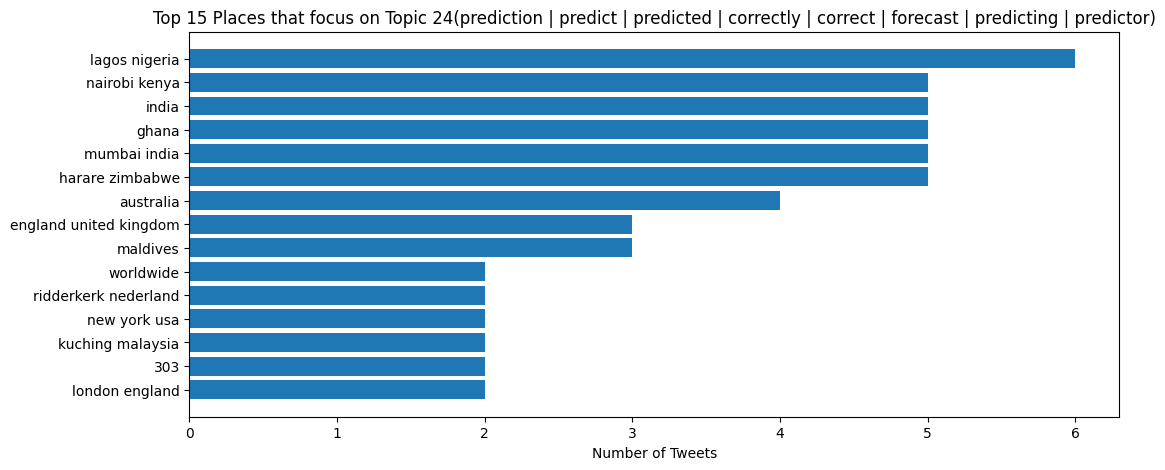

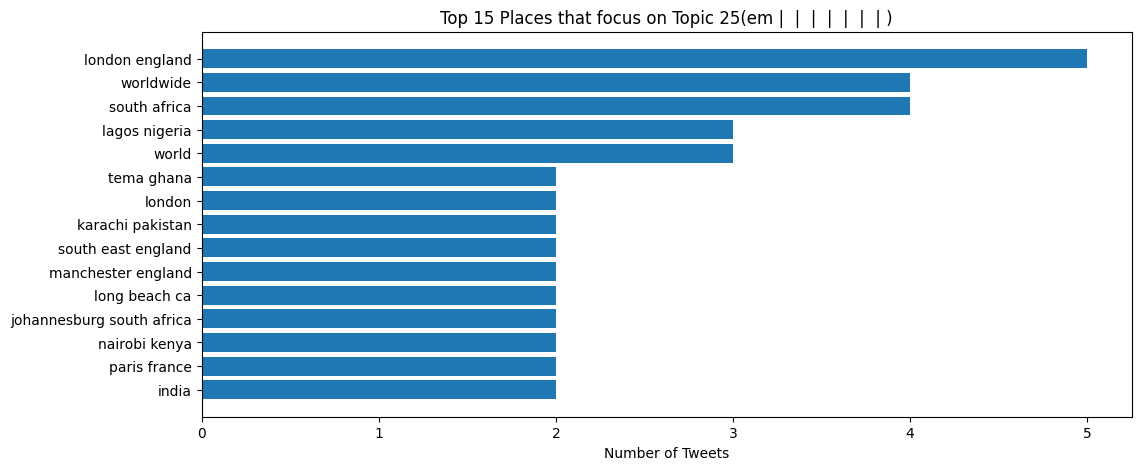

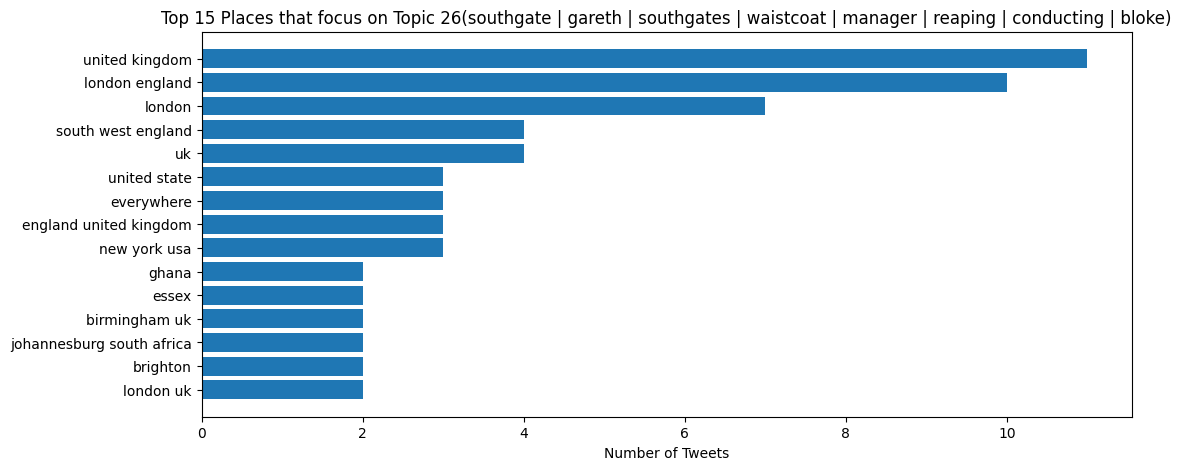

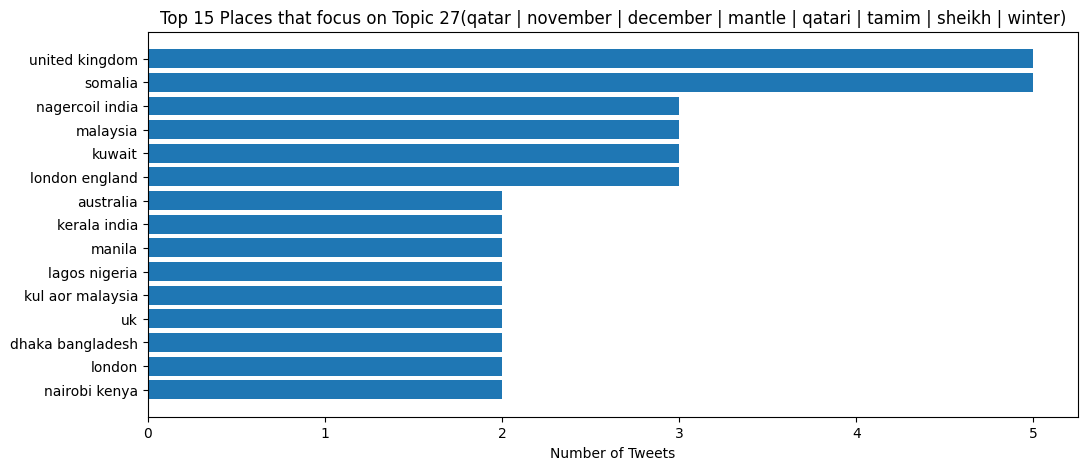

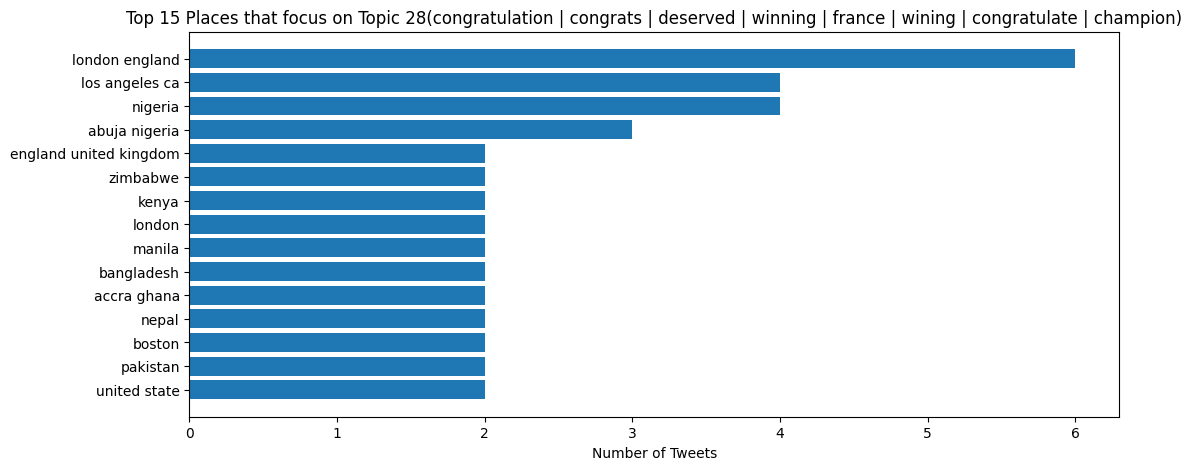

In [19]:
import matplotlib.pyplot as plt
for topic_id in top_topics.index:

    topic_words = [
        word
        for word, score
        in topic_model18.get_topic(topic_id)[:8]
    ]

    topic_representation = " | ".join(topic_words)

    topic_places = (
        df18[df18["topic"] == topic_id]["Place"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12,5))

    plt.barh(
        topic_places.index,
        topic_places.values
    )
    plt.title(f"Top 15 Places that focus on Topic {topic_id}({topic_representation})")
    

    plt.xlabel("Number of Tweets")

    plt.gca().invert_yaxis()

    plt.show()

* the most discussed topic in each place

In [ ]:

import matplotlib.pyplot as plt

def visualize_place_topics(
    df,
    topic_model,
    place_keyword,
    top_n=10
):

    # Filter place
    subset = df[
        df["Place"].str.contains(
            place_keyword,
            case=False,
            na=False
        )
    ]

    # Remove outlier topic
    subset = subset[
        subset["topic"] != -1
    ]

    # Most discussed topics in this place
    topic_counts = (
        subset["topic"]
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    topic_counts.columns = [
        "Topic",
        "Count"
    ]

    # Topic representation
    topic_counts["Representation"] = topic_counts["Topic"].apply(
        lambda topic_id: " | ".join(
            [
                word
                for word, score
                in topic_model.get_topic(topic_id)[:5]
            ]
        )
    )

    plt.figure(figsize=(12,6))

    plt.barh(
        topic_counts["Representation"],
        topic_counts["Count"]
    )

    plt.title(
        f"Most Discussed Topics in '{place_keyword}'"
    )

    plt.xlabel("Tweet Count")

    plt.gca().invert_yaxis()

    plt.tight_layout()

    plt.show()

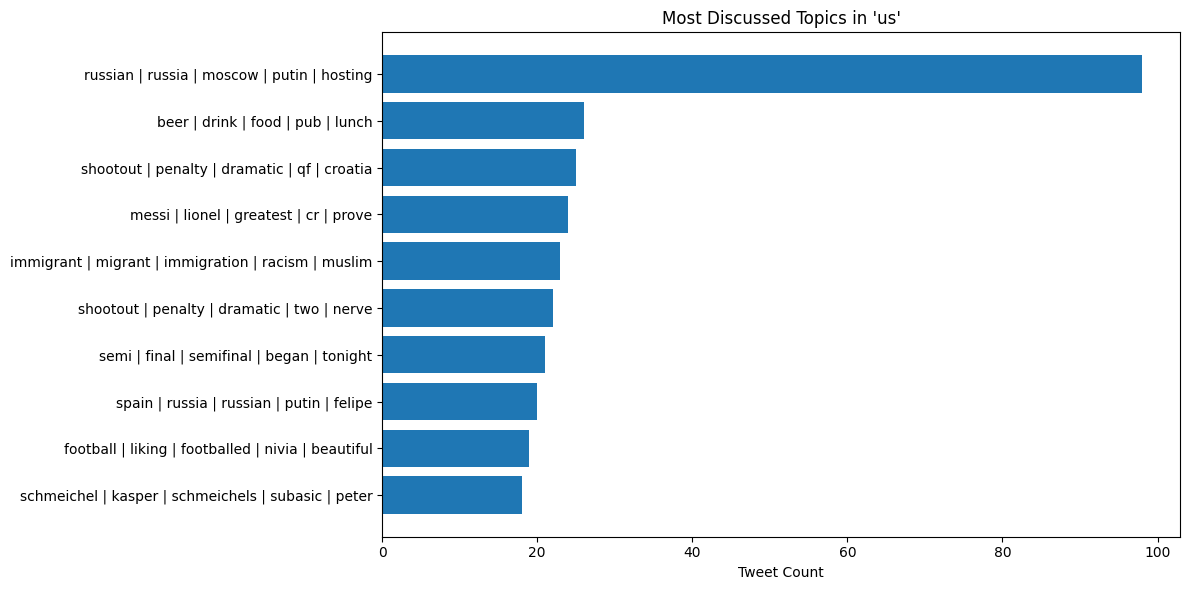

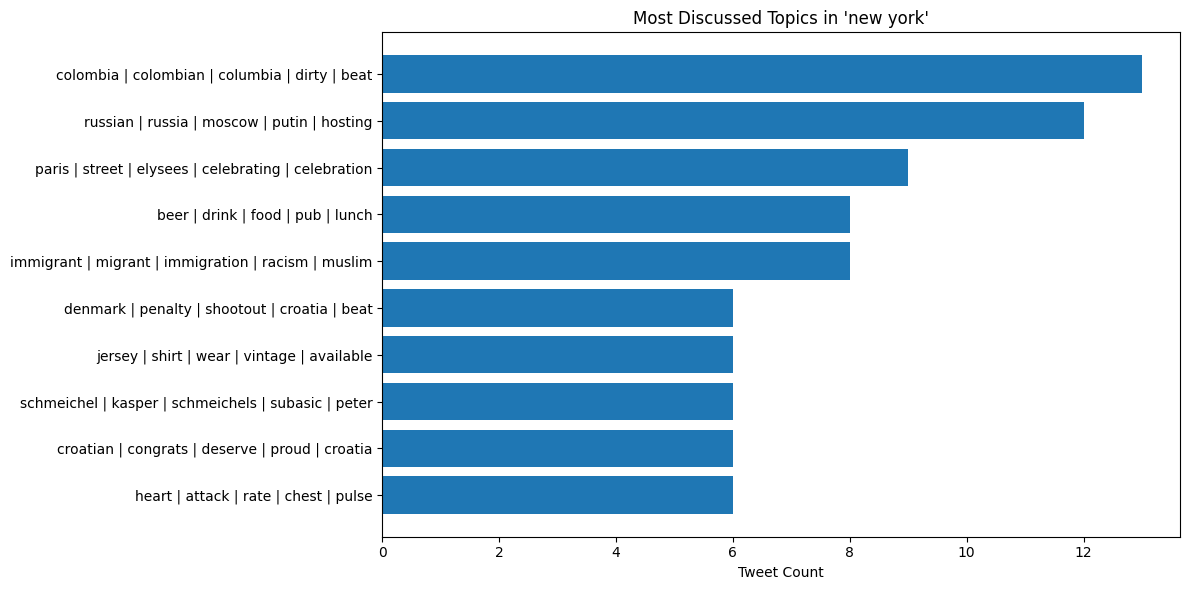

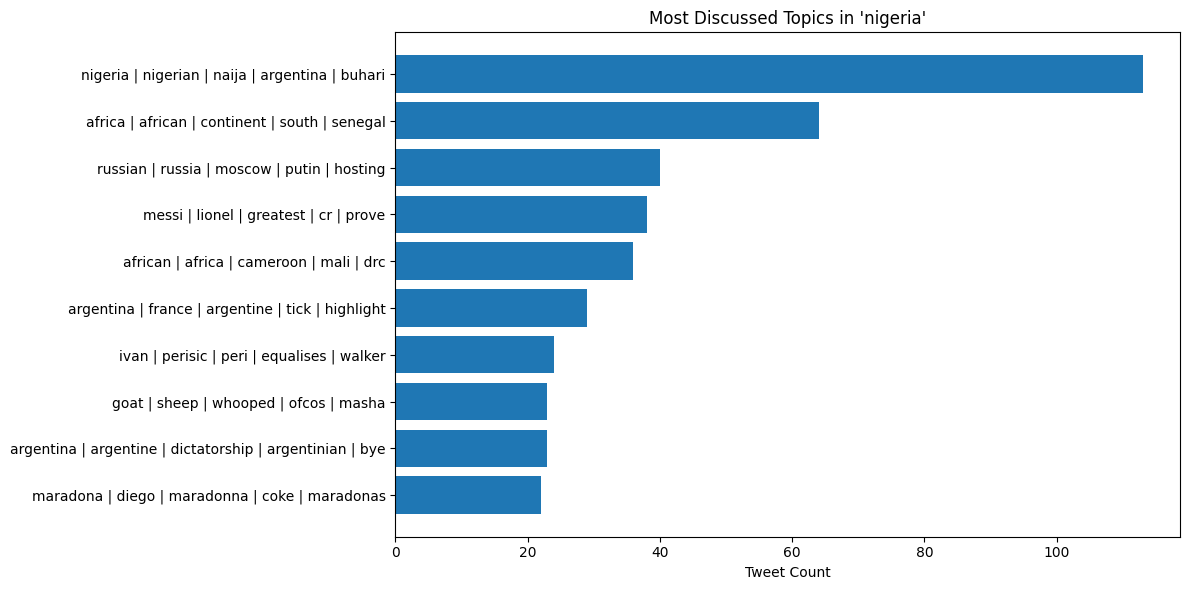

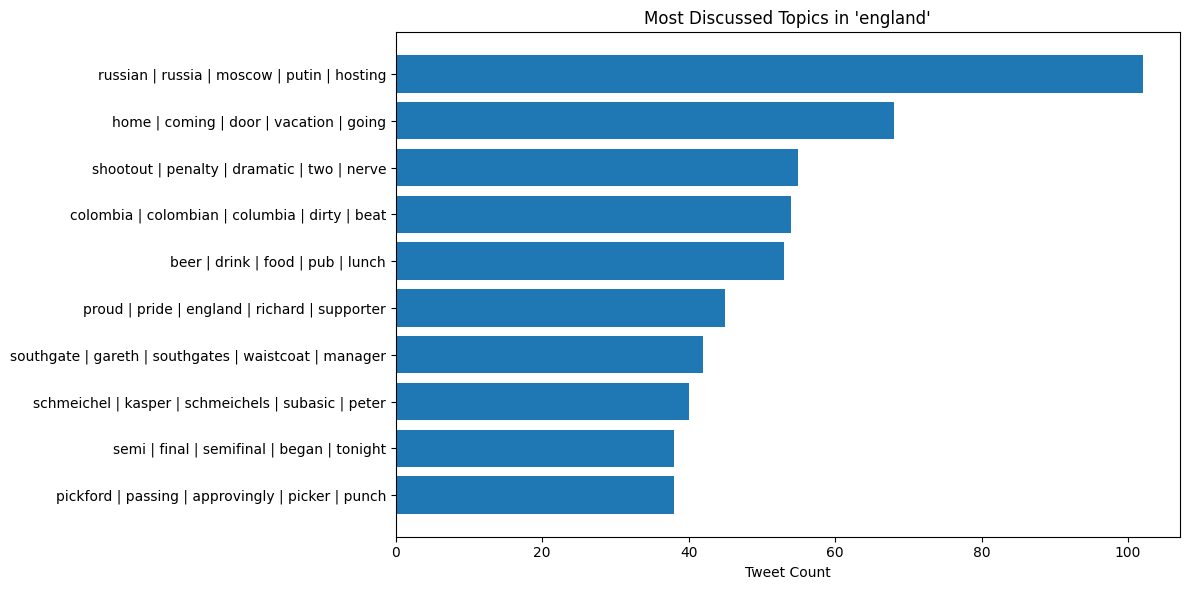

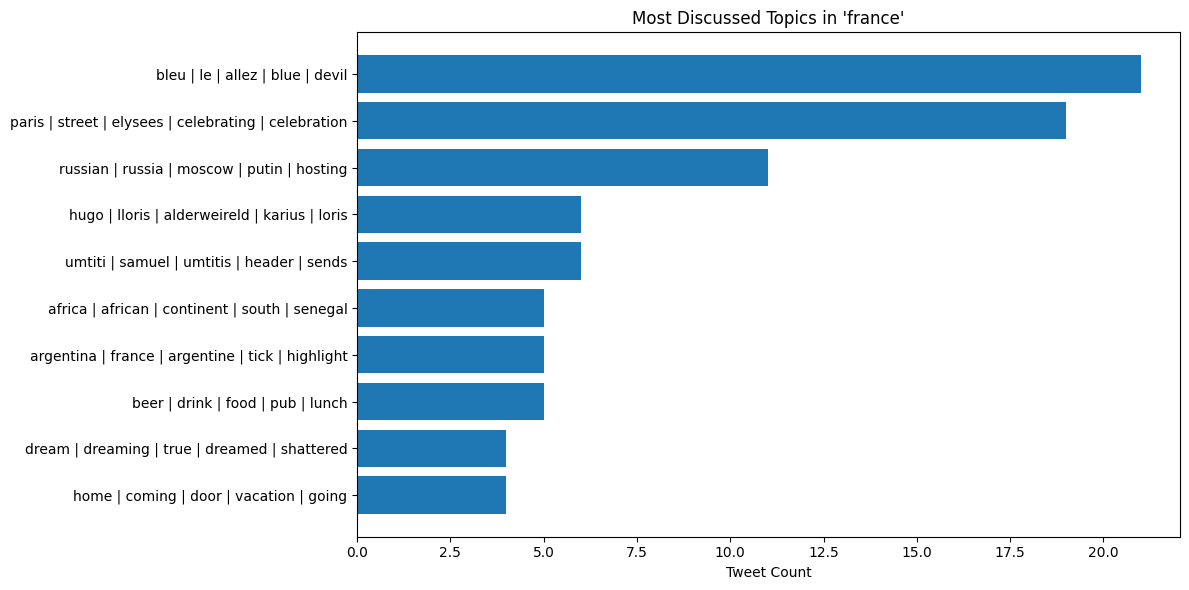

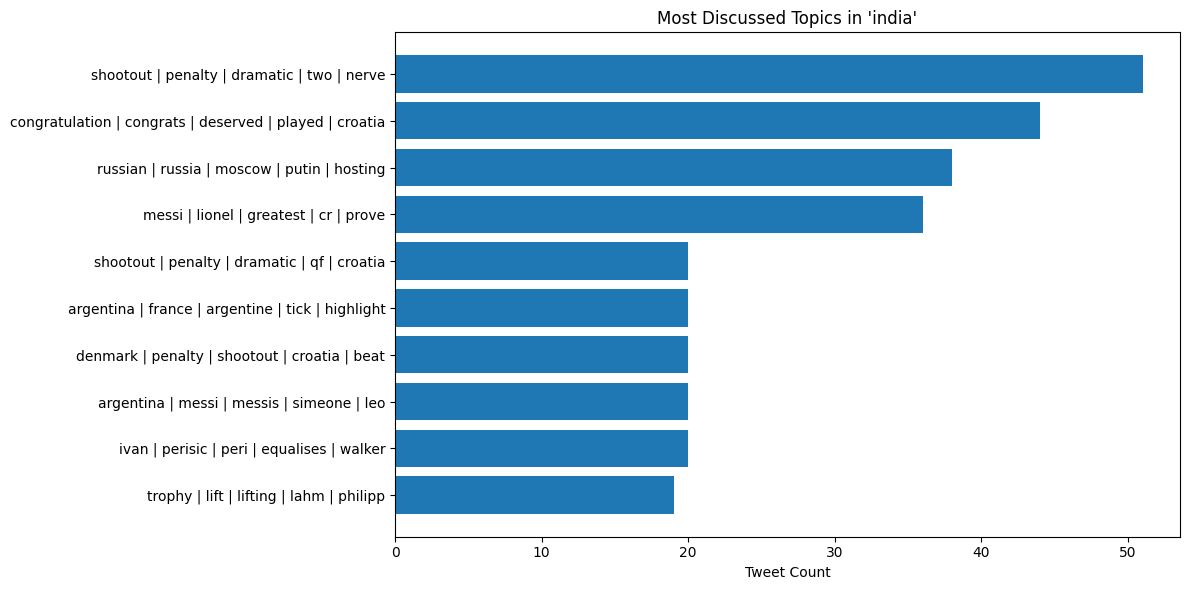

In [102]:

visualize_place_topics(
    df18,
    topic_model18,
    "us"
)
visualize_place_topics(
    df18,
    topic_model18,
    "new york"
)
visualize_place_topics(
    df18,
    topic_model18,
    "nigeria"
)
visualize_place_topics(
    df18,
    topic_model18,
    "england"
)


visualize_place_topics(
    df18,
    topic_model18,
    "france"
)

visualize_place_topics(
    df18,
    topic_model18,
    "india"
)




* Which places are the most active in discussing the World Cup?

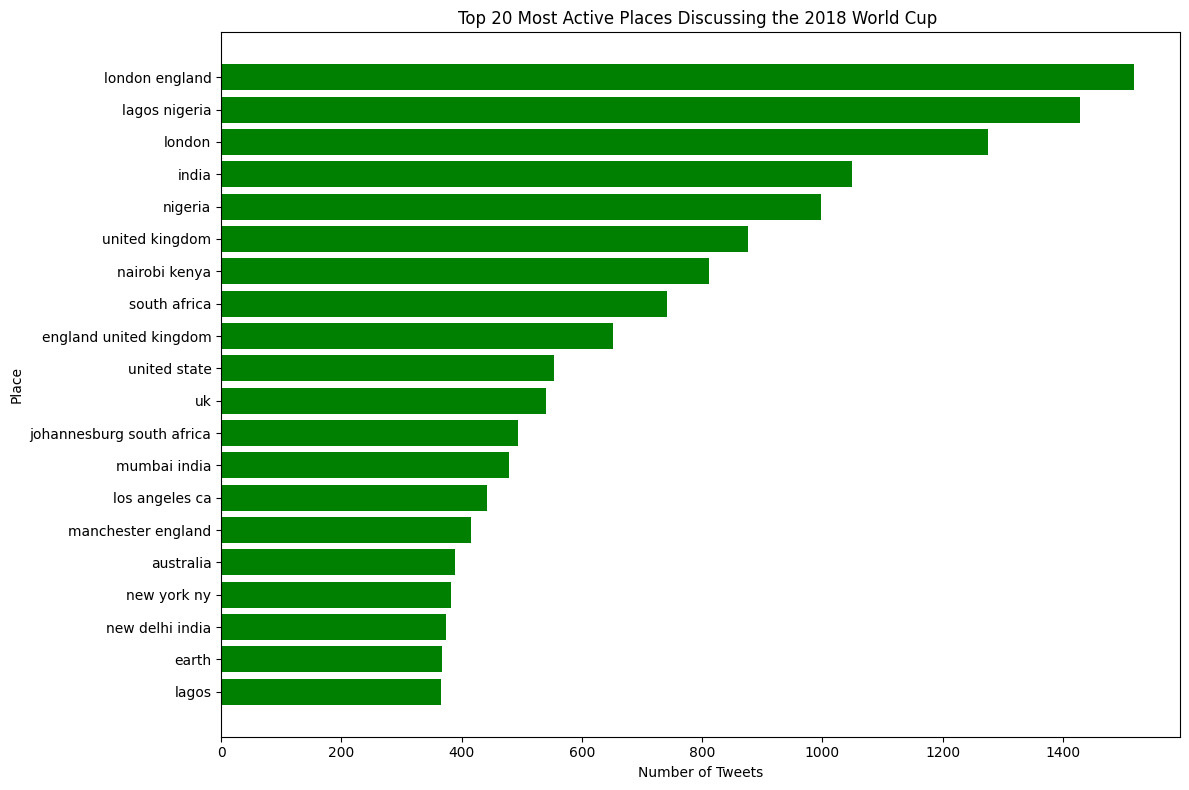

In [23]:
top_places = (
    df18["Place"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(
    top_places.index,
    top_places.values,
    color="green"
)

plt.xlabel("Number of Tweets")
plt.ylabel("Place")

plt.title(
    "Top 20 Most Active Places Discussing the 2018 World Cup "
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* Which topics generate the highest average likes?

In [25]:
#in 2018 worldcup
df18_clean = df18[df18["topic"] != -1].copy()
topic_likes = (
    df18_clean
    .groupby("topic")["Likes"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
topic_likes["Representation"] = topic_likes["topic"].apply(
    lambda t: " | ".join(
        word
        for word, score
        in topic_model18.get_topic(t)[:5]
    )
)
topic_likes.head(10)

,topic,Likes,Representation
0,995,128.625000,applause | hold | head | high | held
1,478,92.694444,goodbye | farewell | bid | riddance | retiring
2,1059,62.466667,airplane | pt | fake | airplain | armeries
3,829,41.350000,ons | pogbas | tackle | aerial | acccuracy
4,835,40.450000,dybala | juventus | paulo | paolo | season
5,639,24.925926,moment | momento | panel | litter | chill
6,543,20.593750,ricardo | danijel | saved | subasic | goalkeeper
7,629,20.071429,skipper | luka | receives | award | golden
8,1050,17.066667,listing | blog | tv | live | frabel
9,475,17.027027,star | brighter | burned | born | stardust


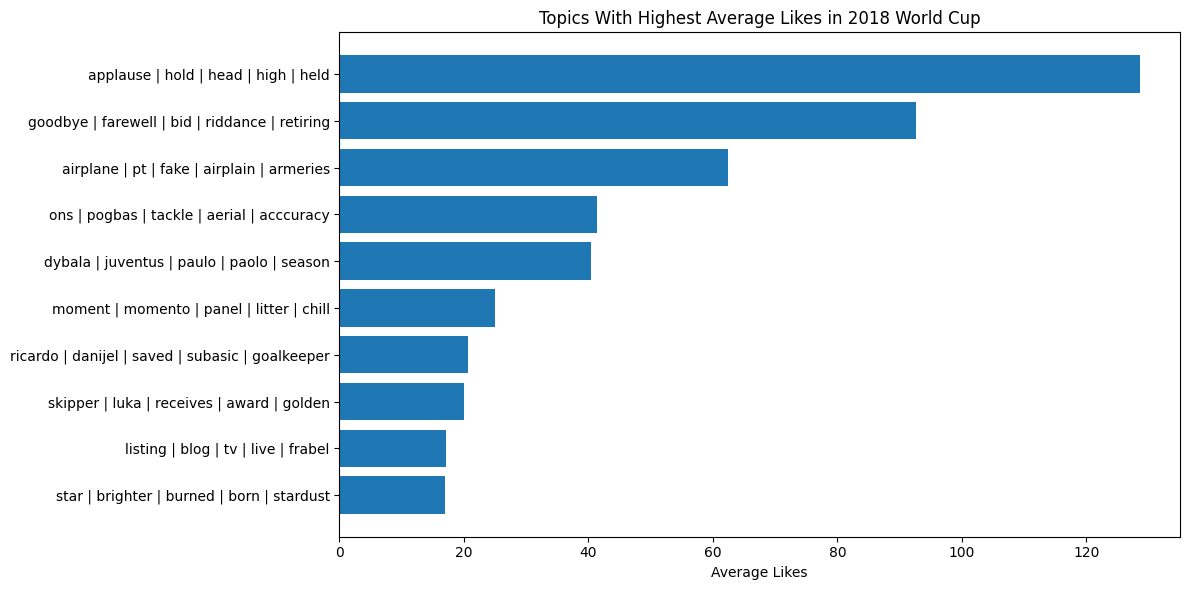

In [26]:
top_liked_topics = topic_likes.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_liked_topics["Representation"],
    top_liked_topics["Likes"]
)

plt.xlabel("Average Likes")
plt.title("Topics With Highest Average Likes in 2018 World Cup")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* Which topics are most retweeted?

In [27]:
df18_clean = df18[df18["topic"] != -1].copy()
topic_retweets = (
    df18_clean
    .groupby("topic")["RTs"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

topic_retweets.head(10)
topic_retweets["Representation"] = topic_retweets["topic"].apply(
    lambda t: " | ".join(
        word
        for word, score
        in topic_model18.get_topic(t)[:5]
    )
)

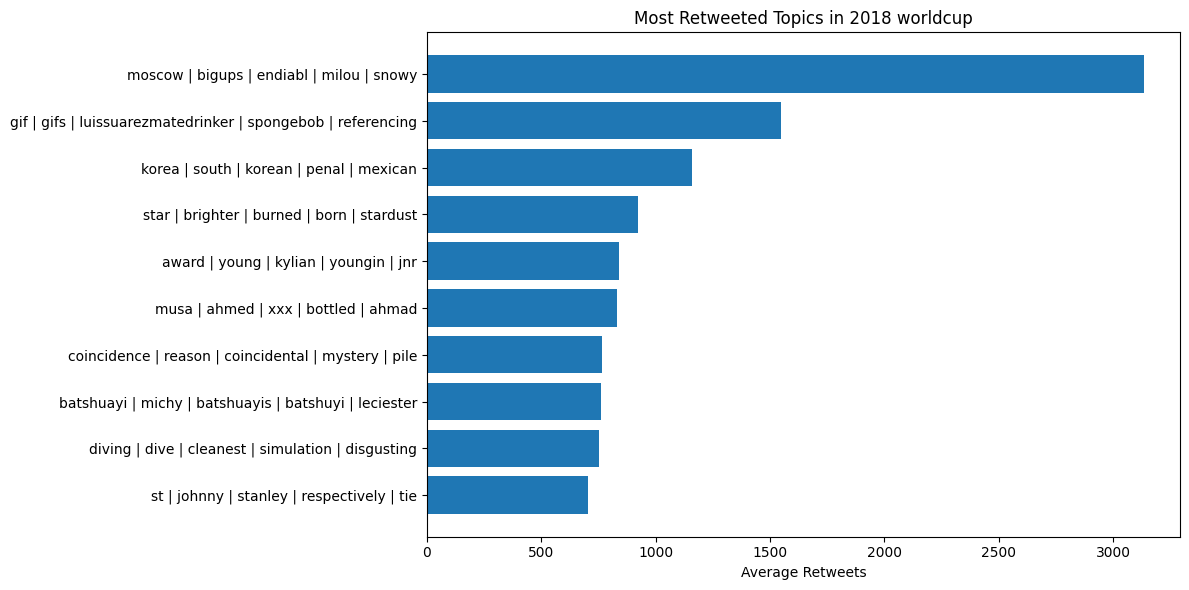

In [28]:
top_retweeted_topics = topic_retweets.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_retweeted_topics["Representation"],
    top_retweeted_topics["RTs"]
)

plt.xlabel("Average Retweets")
plt.title("Most Retweeted Topics in 2018 worldcup")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* For each place, which topic gets the highest engagement?

In [96]:
df18_clean = df18[df18["topic"] != -1].copy()
place_topic_likes = (
    df18_clean
    .groupby(["Place", "topic"])["Likes"]
    .mean()
    .reset_index(name="avg_likes")
)
most_liked_topic_per_place = (
    place_topic_likes
    .loc[
        place_topic_likes.groupby("Place")["avg_likes"].idxmax()
    ]
)
most_liked_topic_per_place["Representation"] = (
    most_liked_topic_per_place["topic"]
    .apply(
        lambda t: " | ".join(
            word
            for word, score
            in topic_model18.get_topic(t)[:5]
        )
    )
)
most_liked_topic_per_place.sort_values(
    "avg_likes",
    ascending=False
).head(20)

,Place,topic,avg_likes,Representation
45056,www neweraglobalsports com,0,3051.0,russian | russia | moscow | putin | hosting
1546,allianz stadium,995,2058.0,applause | hold | head | high | held
19727,king power stadium,9,1293.0,shootout | penalty | dramatic | qf | croatia
33949,pr com,1059,936.0,airplane | pt | fake | airplain | armeries
37690,somewhere texas,0,896.0,russian | russia | moscow | putin | hosting
42605,urmston,38,846.0,pavard | benjamin | pavards | technique | strike
13487,game,13,788.0,schmeichel | kasper | schmeichels | subasic | ...
44981,worldwide,835,701.0,dybala | juventus | paulo | paolo | season
25950,mediacityuk salford,475,623.0,star | brighter | burned | born | stardust
29176,new delhi india,629,547.0,skipper | luka | receives | award | golden


In [98]:
#Most retweeted topic in each place
place_topic_retweets = (
    df18_clean
    .groupby(["Place", "topic"])["RTs"]
    .mean()
    .reset_index(name="avg_retweets")
)
most_retweeted_topic_per_place = (
    place_topic_retweets
    .loc[
        place_topic_retweets.groupby("Place")["avg_retweets"].idxmax()
    ]
)
most_retweeted_topic_per_place["Representation"] = (
    most_retweeted_topic_per_place["topic"]
    .apply(
        lambda t: " | ".join(
            word
            for word, score
            in topic_model18.get_topic(t)[:5]
        )
    )
)
most_retweeted_topic_per_place.sort_values(
    "avg_retweets",
    ascending=False
).head(20)

,Place,topic,avg_retweets,Representation
13176,france,952,53277.0,moscow | bigups | endiabl | milou | snowy
4252,birmingham,81,44742.0,country | nation | proud | pride | uniting
32942,phalaborwa south africa,475,33612.0,star | brighter | burned | born | stardust
40198,texas usa,293,29978.0,vote | voted | iscot | voting | jia
15096,haunted hill,322,24048.0,cry | madonna | gable | argentinaaaaa | argentina
32564,paris ile de france,0,23635.0,russian | russia | moscow | putin | hosting
26730,mind,11,21404.0,immigrant | migrant | immigration | racism | m...
1414,alaska,38,17990.0,pavard | benjamin | pavards | technique | strike
19345,kent,508,17772.0,stone | mick | jagger | john | stove
15803,houston tx,61,17568.0,congratulation | congrats | winning | kkc | pa...


* Most Used Hashtags during the tournement

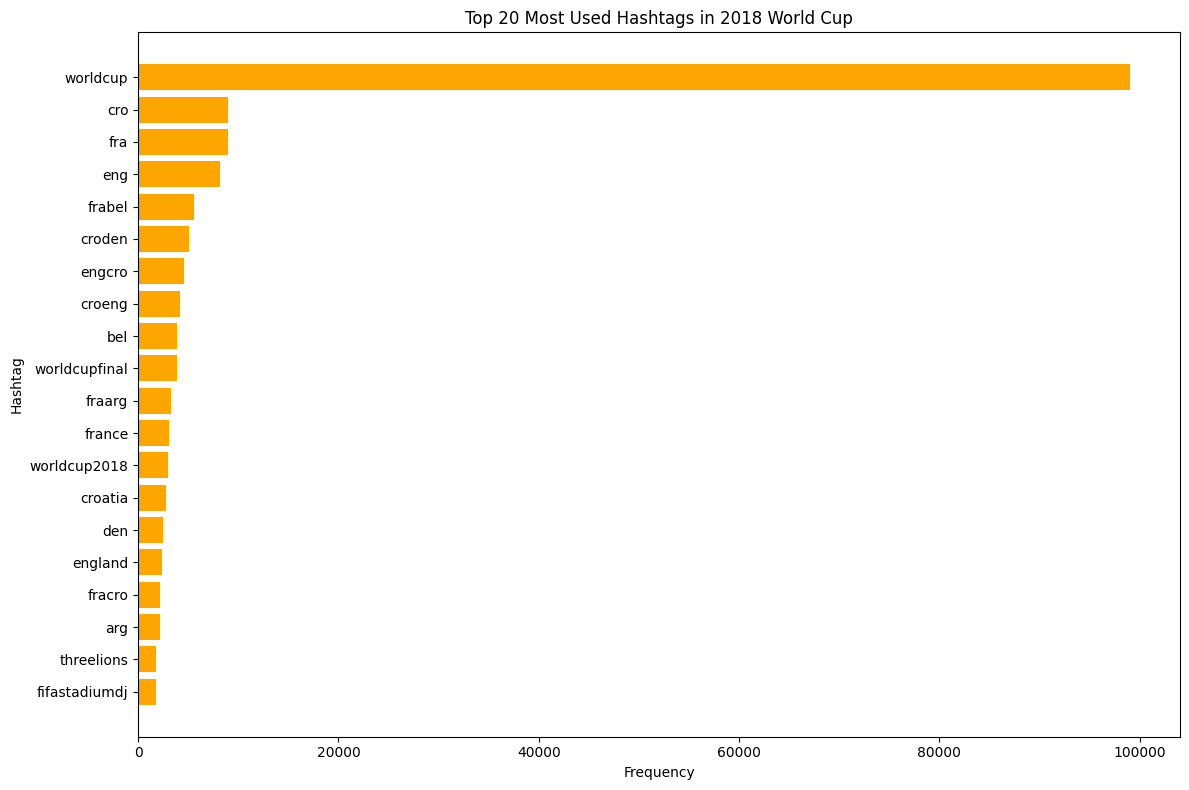

In [30]:
hashtags = (
    df18["Hashtags"]
    .dropna()
    .str.split()
    .explode()
)

top_hashtags = hashtags.value_counts().head(20)
plt.figure(figsize=(12,8))

plt.barh(
    top_hashtags.index,
    top_hashtags.values,
    color="orange"
)

plt.xlabel("Frequency")
plt.ylabel("Hashtag")

plt.title(
    "Top 20 Most Used Hashtags in 2018 World Cup"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [31]:
top_hashtag_names = (
    hashtags.value_counts()
    .head(10)
    .index
)
hashtag_place_rows = []

for hashtag in top_hashtag_names:

    subset = df18[
        df18["Hashtags"]
        .fillna("")
        .str.contains(
            hashtag,
            case=False,
            na=False
        )
    ]

    top_place = (
        subset["Place"]
        .value_counts()
        .head(1)
    )

    if len(top_place) > 0:

        hashtag_place_rows.append({
            "Hashtag": hashtag,
            "Top Place": top_place.index[0],
            "Count": top_place.values[0]
        })

hashtag_place_df = pd.DataFrame(
    hashtag_place_rows
)

hashtag_place_df

,Hashtag,Top Place,Count
0,worldcup,london england,1345
1,cro,india,382
2,fra,india,441
3,eng,london england,440
4,frabel,india,100
5,croden,lagos nigeria,87
6,engcro,london england,139
7,croeng,lagos nigeria,85
8,bel,india,157
9,worldcupfinal,india,126


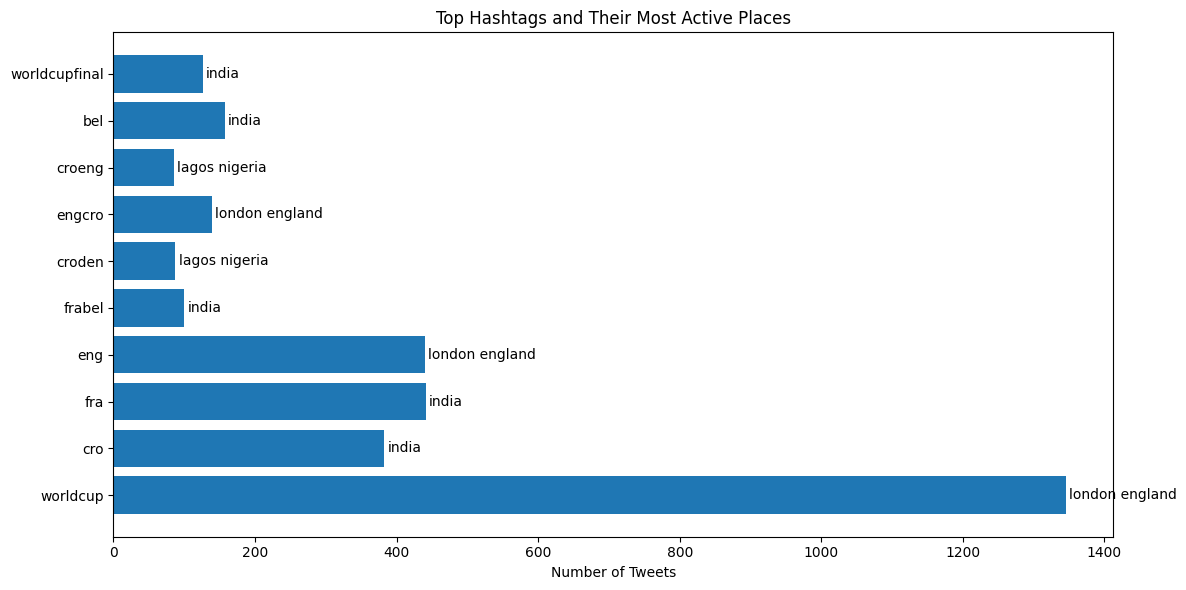

In [32]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    hashtag_place_df["Hashtag"],
    hashtag_place_df["Count"]
)

for i, place in enumerate(hashtag_place_df["Top Place"]):
    plt.text(
        hashtag_place_df["Count"].iloc[i] + 5,
        i,
        place,
        va="center"
    )

plt.xlabel("Number of Tweets")
plt.title("Top Hashtags and Their Most Active Places")

plt.tight_layout()
plt.show()

In [34]:
top_places = (
    df18["Place"]
    .value_counts()
    .head(20)
    .index
)
rows = []

for place in top_places:

    subset = df18[
        df18["Place"] == place
    ]

    hashtags = (
        subset["Hashtags"]
        .dropna()
        .str.split()
        .explode()
    )

    top_hashtags = hashtags.value_counts().head(10)

    for hashtag, count in top_hashtags.items():

        rows.append({
            "Place": place,
            "Hashtag": hashtag,
            "Count": count
        })

place_hashtag_df = pd.DataFrame(rows)

place_hashtag_df.head(20)

,Place,Hashtag,Count
0,london england,worldcup,1340
1,london england,eng,196
2,london england,engcro,139
3,london england,fra,101
4,london england,cro,100
5,london england,itscominghome,70
6,london england,england,67
7,london england,croden,63
8,london england,frabel,63
9,london england,threelions,61


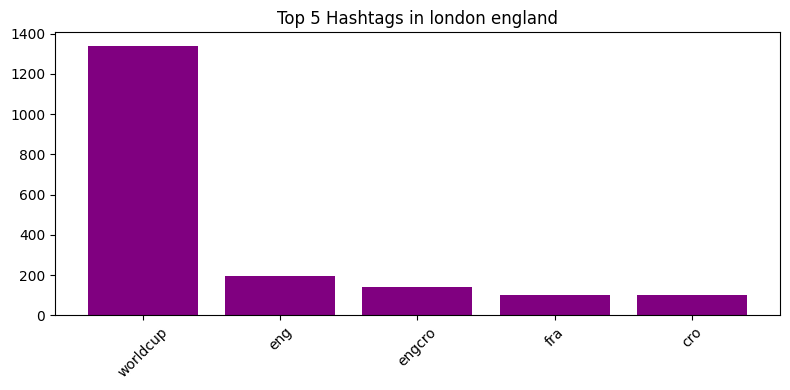

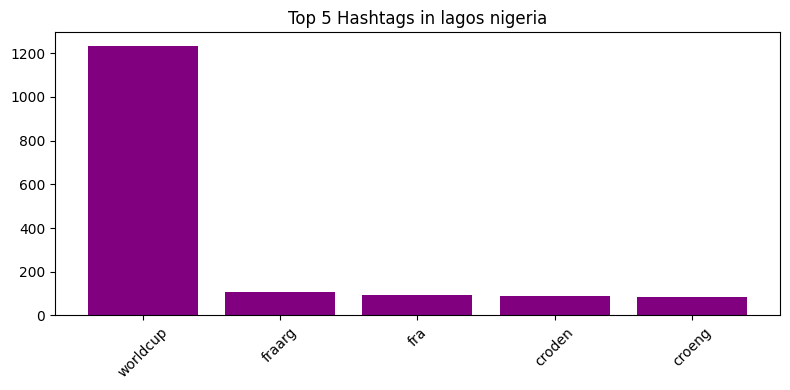

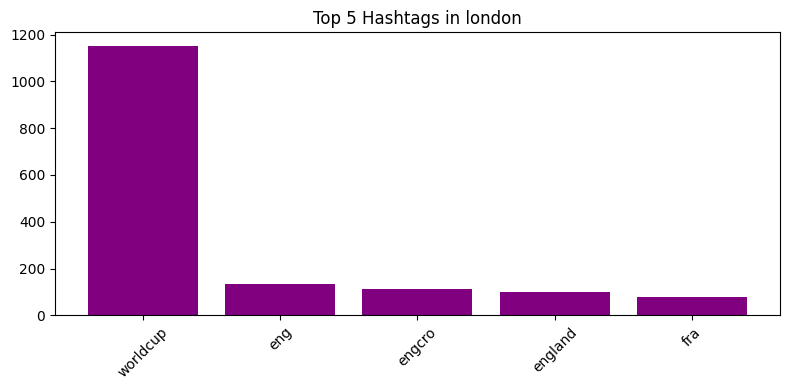

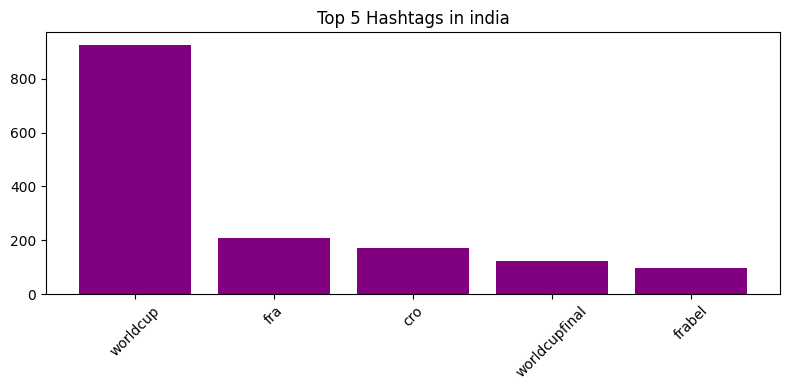

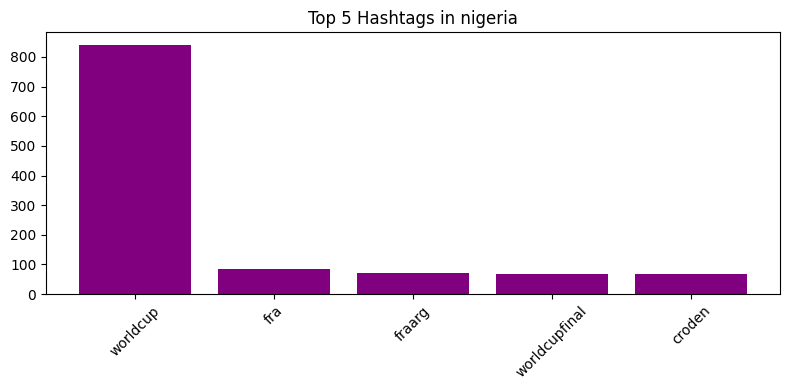

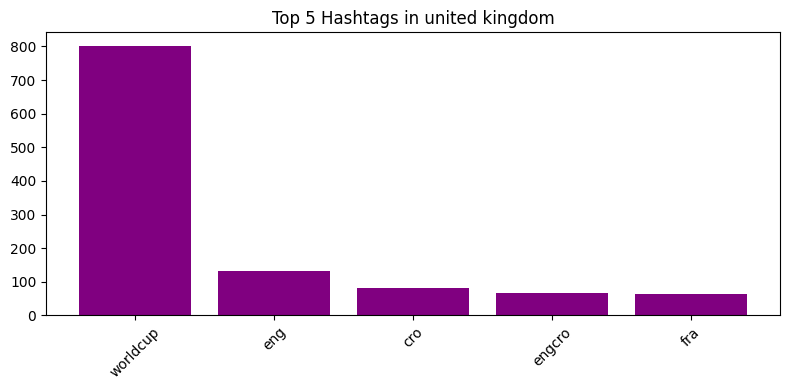

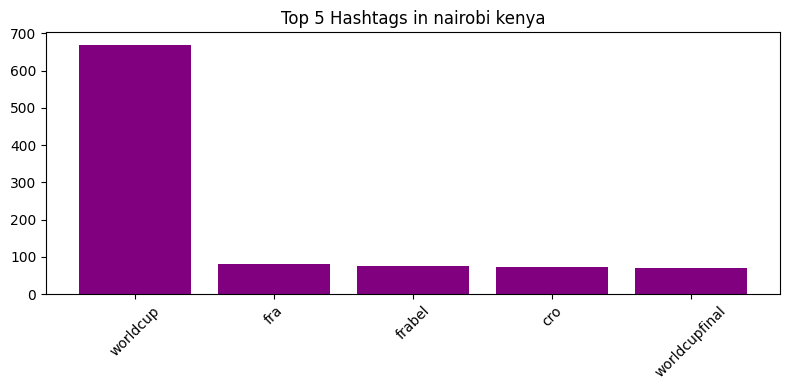

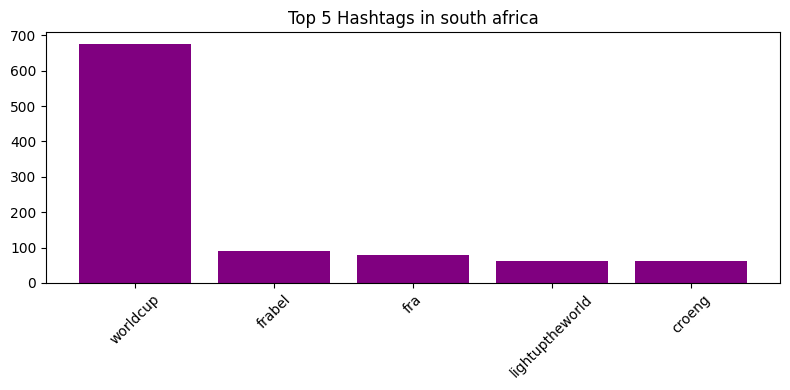

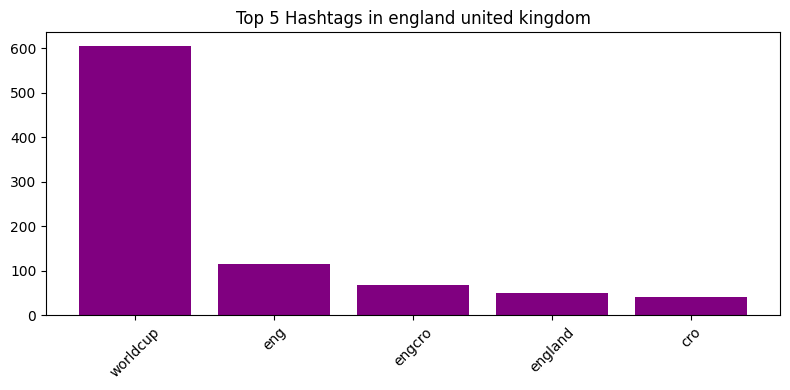

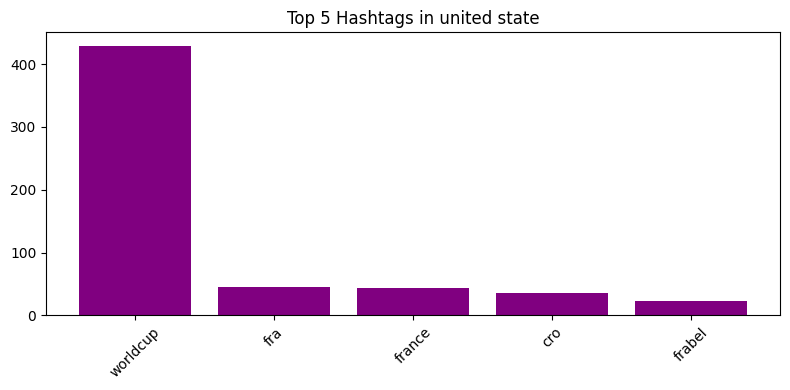

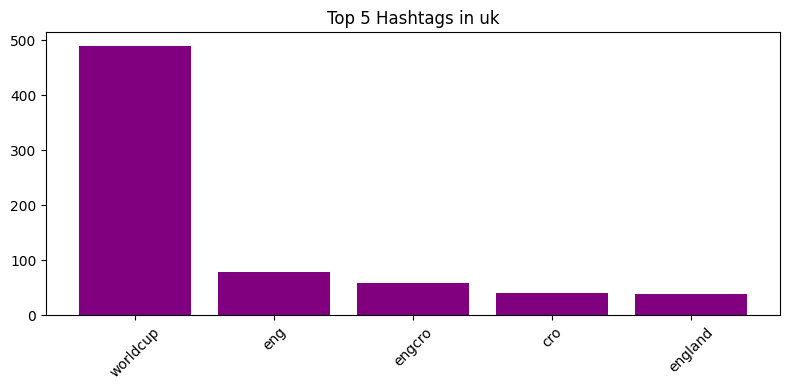

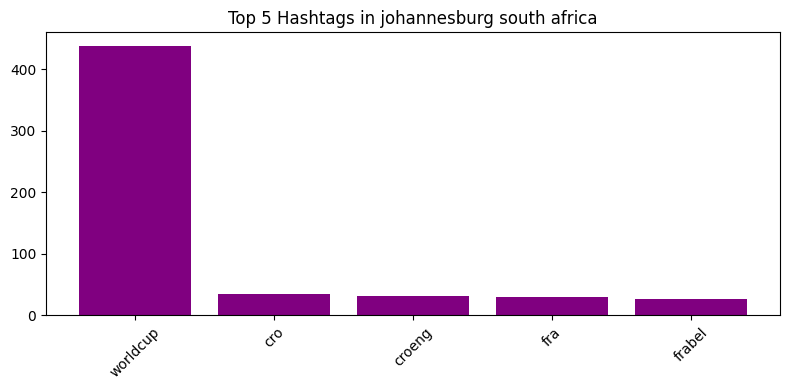

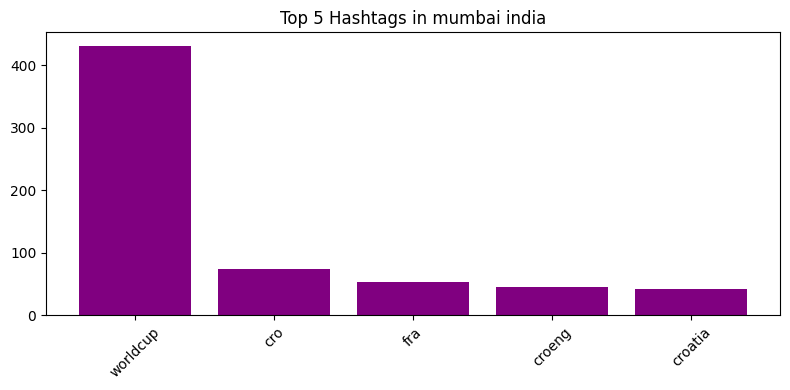

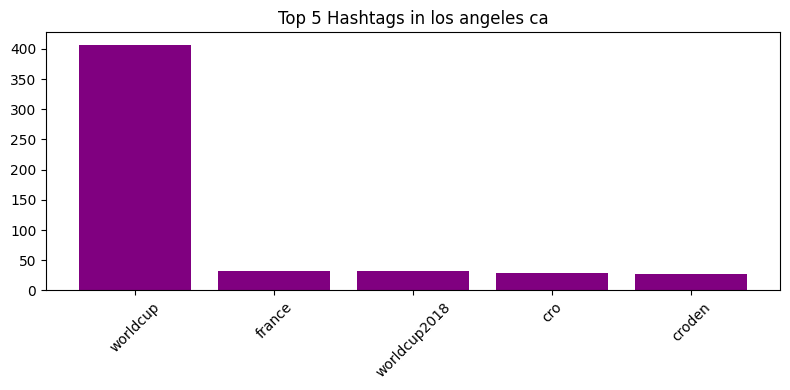

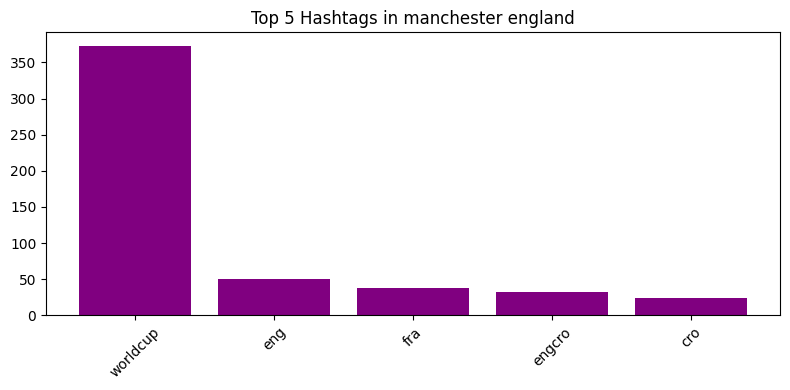

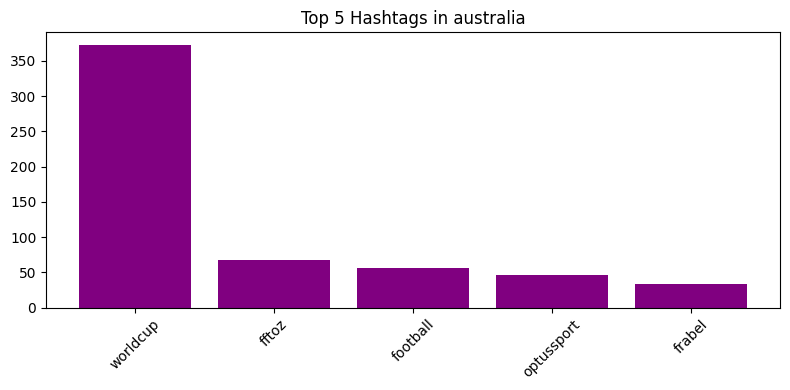

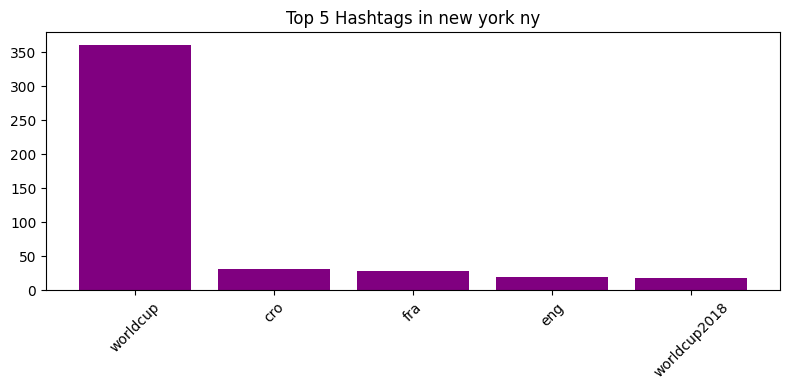

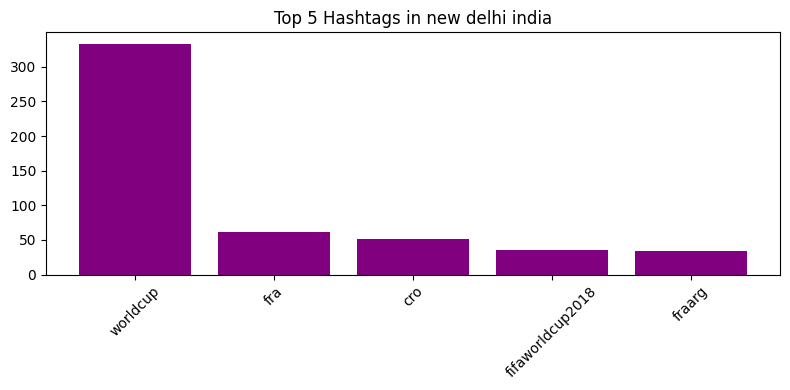

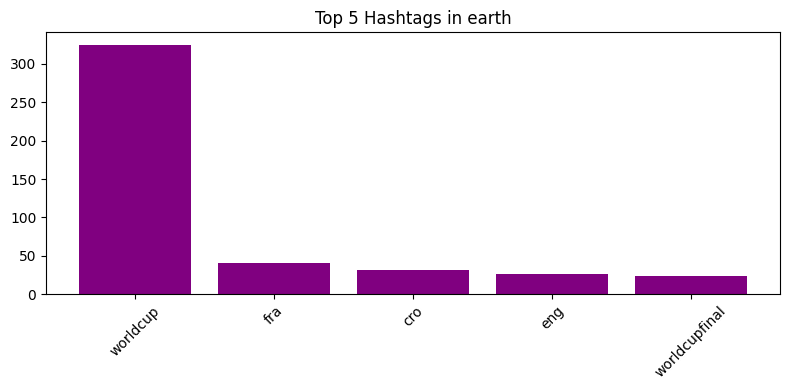

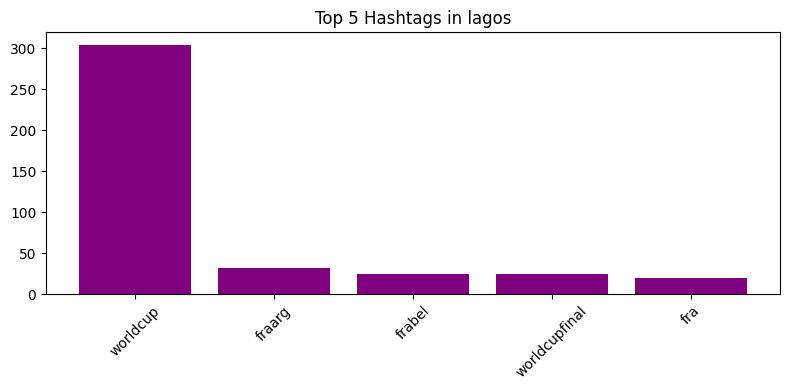

In [38]:
for place in top_places:

    subset = (
        place_hashtag_df[
            place_hashtag_df["Place"] == place
        ]
        .head(5)
    )

    plt.figure(figsize=(8,4))

    plt.bar(
        subset["Hashtag"],
        subset["Count"],
        color="purple"
    )

    plt.xticks(rotation=45)
    plt.title(f"Top 5 Hashtags in {place}")
    plt.tight_layout()

    plt.show()

*  Which sources produce the most content?

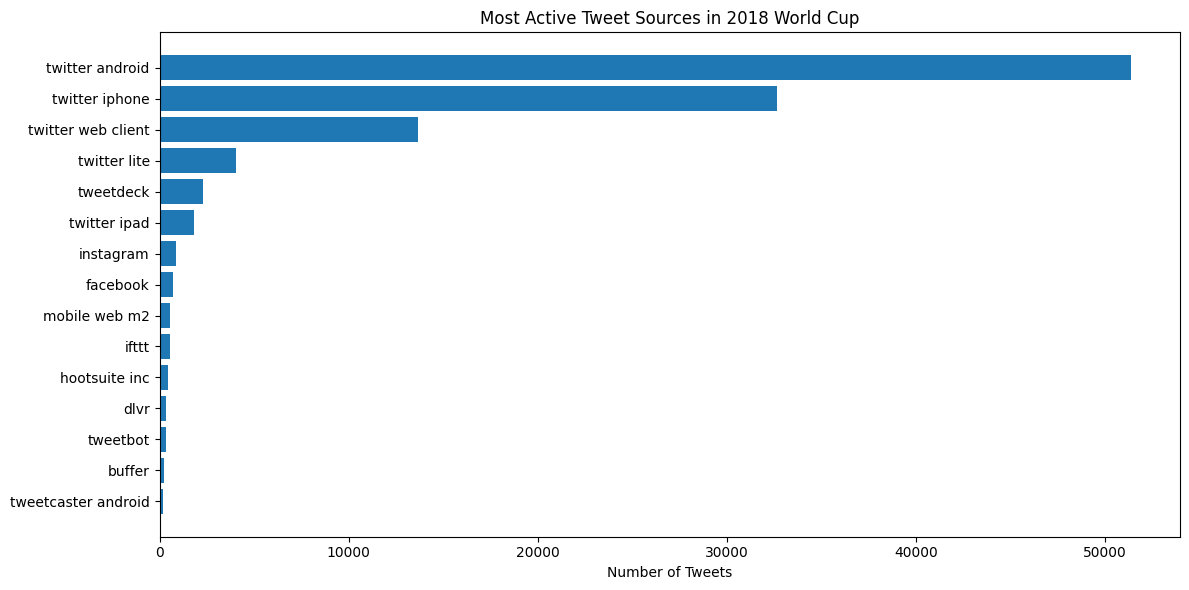

In [41]:
source_counts = (
    df18["Source"]
    .value_counts()
)
import matplotlib.pyplot as plt

top_sources = (
    df18["Source"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_sources.index,
    top_sources.values
)

plt.title(
    "Most Active Tweet Sources in 2018 World Cup"
)

plt.xlabel(
    "Number of Tweets"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**2022 World Cup**

In [49]:
df22.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Date Created', 'Number of Likes',
       'Source of Tweet', 'Tweet', 'Sentiment', 'topic'],
      dtype='str')

* Which topics dominated discussion?

In [50]:
top_topics_22 = (
    df22["topic"]
    .value_counts()
    .head(20)
)
top_topics_22 = top_topics_22[top_topics_22.index != -1]
top_topics_22

topic
0     585
1     516
2     335
3     307
4     277
5     253
6     250
7     190
8     182
10    174
9     174
11    172
12    171
13    168
14    145
15    137
16    135
17    116
18    109
Name: count, dtype: int64

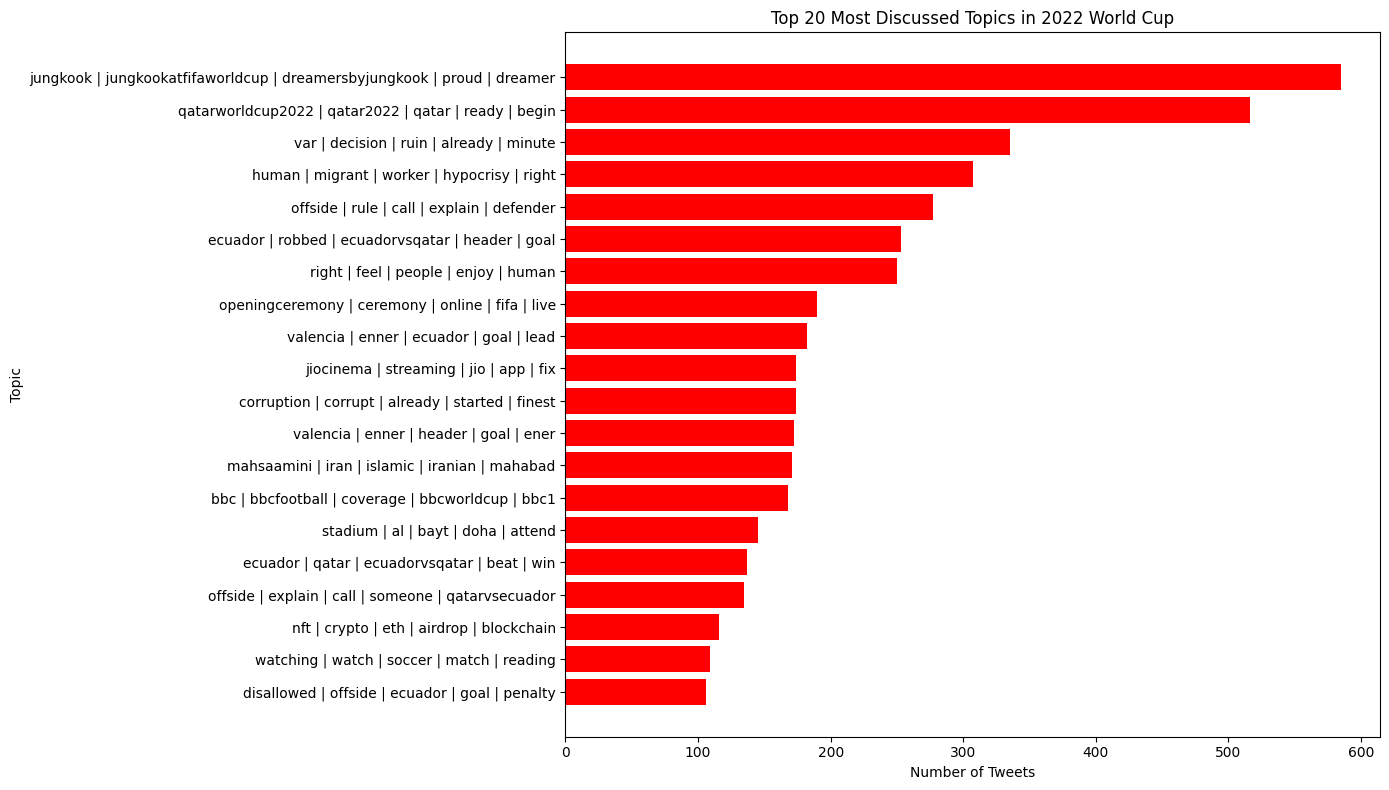

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

top_topics_22 = (
    df22[df22["topic"] != -1]["topic"]
    .value_counts()
    .head(20)
)

topic_df = pd.DataFrame({
    "Topic": top_topics_22.index,
    "Count": top_topics_22.values
})

topic_df["Representation"] = topic_df["Topic"].apply(
    lambda t: " | ".join(
        word
        for word, score
        in topic_model22.get_topic(t)[:5]
    )
)

plt.figure(figsize=(14,8))

plt.barh(
    topic_df["Representation"],
    topic_df["Count"],
    color="red"
)

plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.title("Top 20 Most Discussed Topics in 2022 World Cup")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

* What is the sentiment distribution

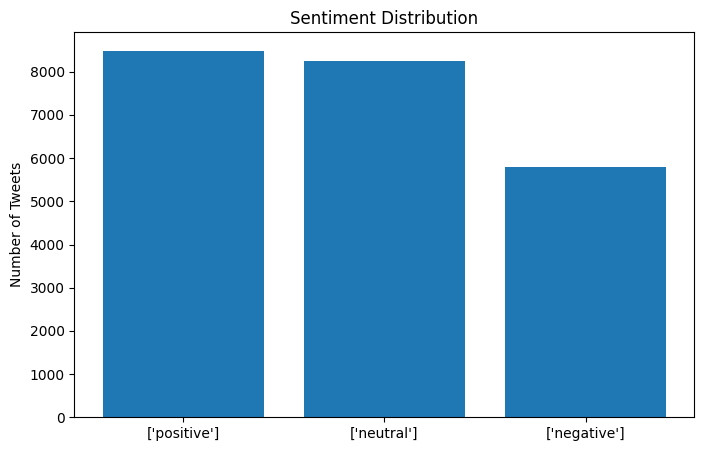

In [9]:
import matplotlib.pyplot as plt
sentiment_counts = (
    df22["Sentiment"]
    .value_counts()
)

plt.figure(figsize=(8,5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title(
    "Sentiment Distribution"
)

plt.ylabel("Number of Tweets")

plt.show()

* Which topics are the most positive and the most negative?

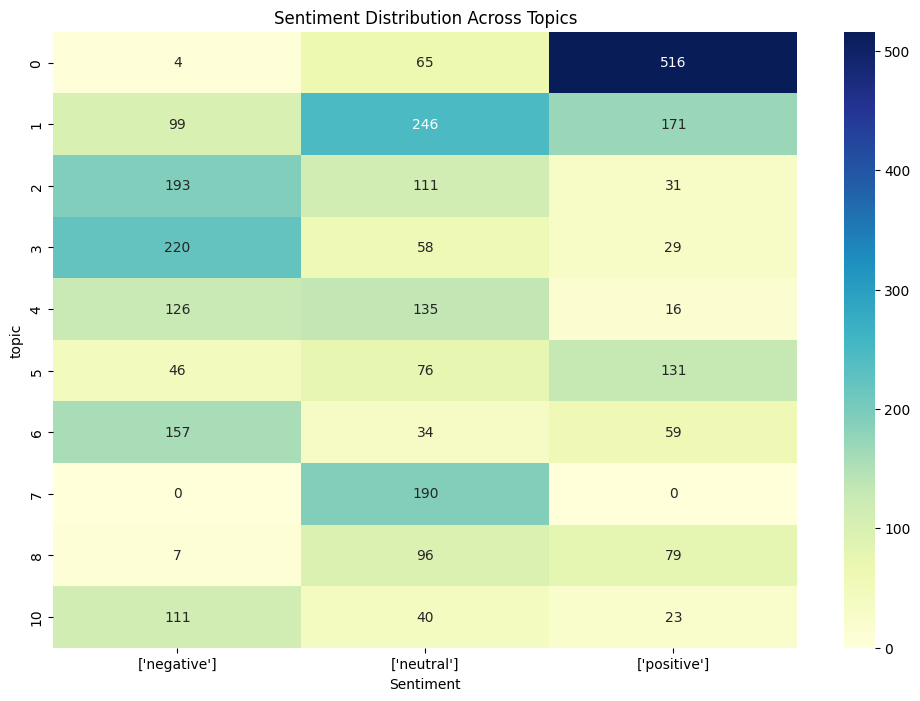

In [11]:

top_topics = (
    df22[df22["topic"] != -1]["topic"]
    .value_counts()
    .head(10)
    .index
)

sent_topic = pd.crosstab(
    df22[df22["topic"].isin(top_topics)]["topic"],
    df22[df22["topic"].isin(top_topics)]["Sentiment"]
)
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    sent_topic,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title(
    "Sentiment Distribution Across Topics"
)

plt.show()

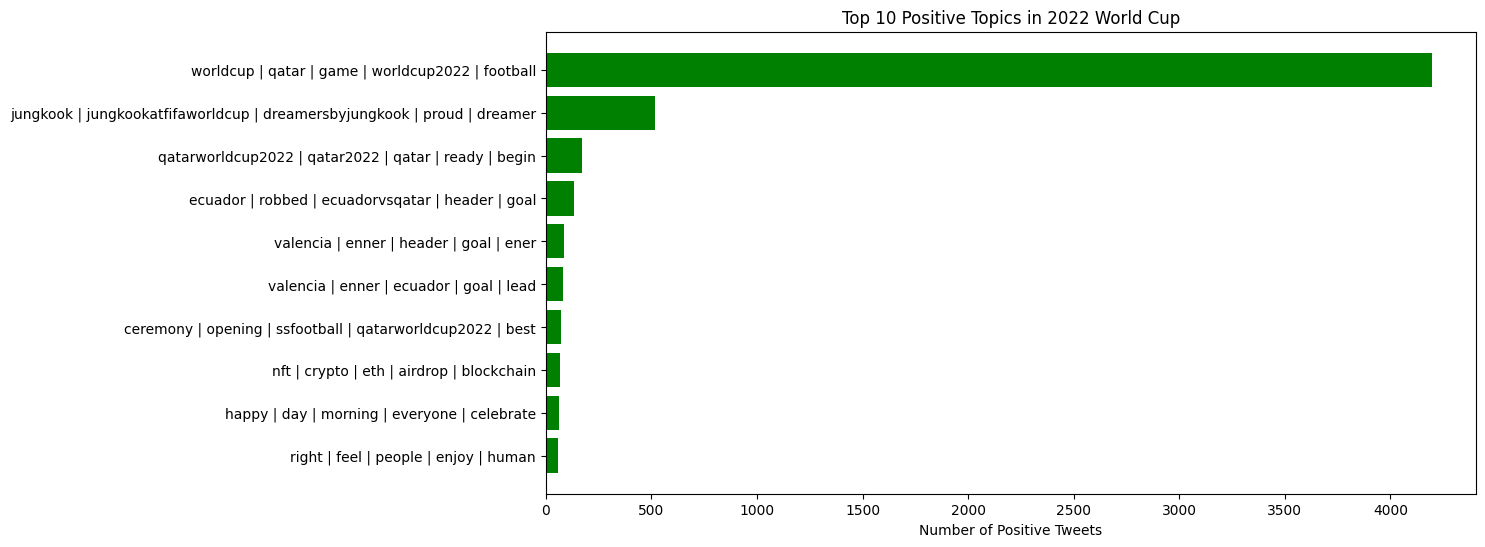

In [33]:
positive_df = df22[
    df22["Sentiment"] == "['positive']"
]
top_positive = (
    positive_df["topic"]
    .value_counts()
    .head(10)
)
rows = []

for topic_id, count in top_positive.items():

    words = [
        word
        for word, score
        in topic_model22.get_topic(topic_id)[:5]
    ]

    rows.append({
        "Topic": topic_id,
        "Count": count,
        "Representation": " | ".join(words)
    })

positive_topics_df = pd.DataFrame(rows)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    positive_topics_df["Representation"],
    positive_topics_df["Count"],
    color="green"
)

plt.title(
    "Top 10 Positive Topics in 2022 World Cup"
)

plt.xlabel(
    "Number of Positive Tweets"
)

plt.gca().invert_yaxis()

plt.show()

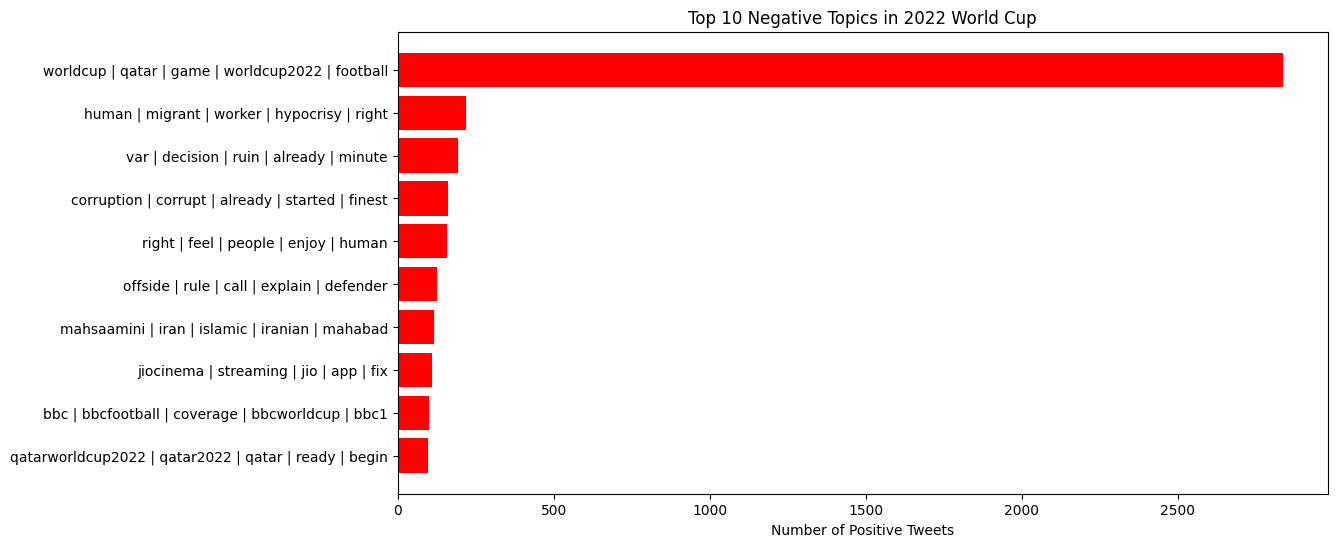

In [97]:
negative_df = df22[
    df22["Sentiment"] == "['negative']"
]
top_positive = (
    negative_df["topic"]
    .value_counts()
    .head(10)
)
rows = []

for topic_id, count in top_positive.items():

    words = [
        word
        for word, score
        in topic_model22.get_topic(topic_id)[:5]
    ]

    rows.append({
        "Topic": topic_id,
        "Count": count,
        "Representation": " | ".join(words)
    })

positive_topics_df = pd.DataFrame(rows)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    positive_topics_df["Representation"],
    positive_topics_df["Count"],
    color="red"
)

plt.title(
    "Top 10 Negative Topics in 2022 World Cup"
)

plt.xlabel(
    "Number of Positive Tweets"
)

plt.gca().invert_yaxis()

plt.show()

* Which topics receive the most likes?

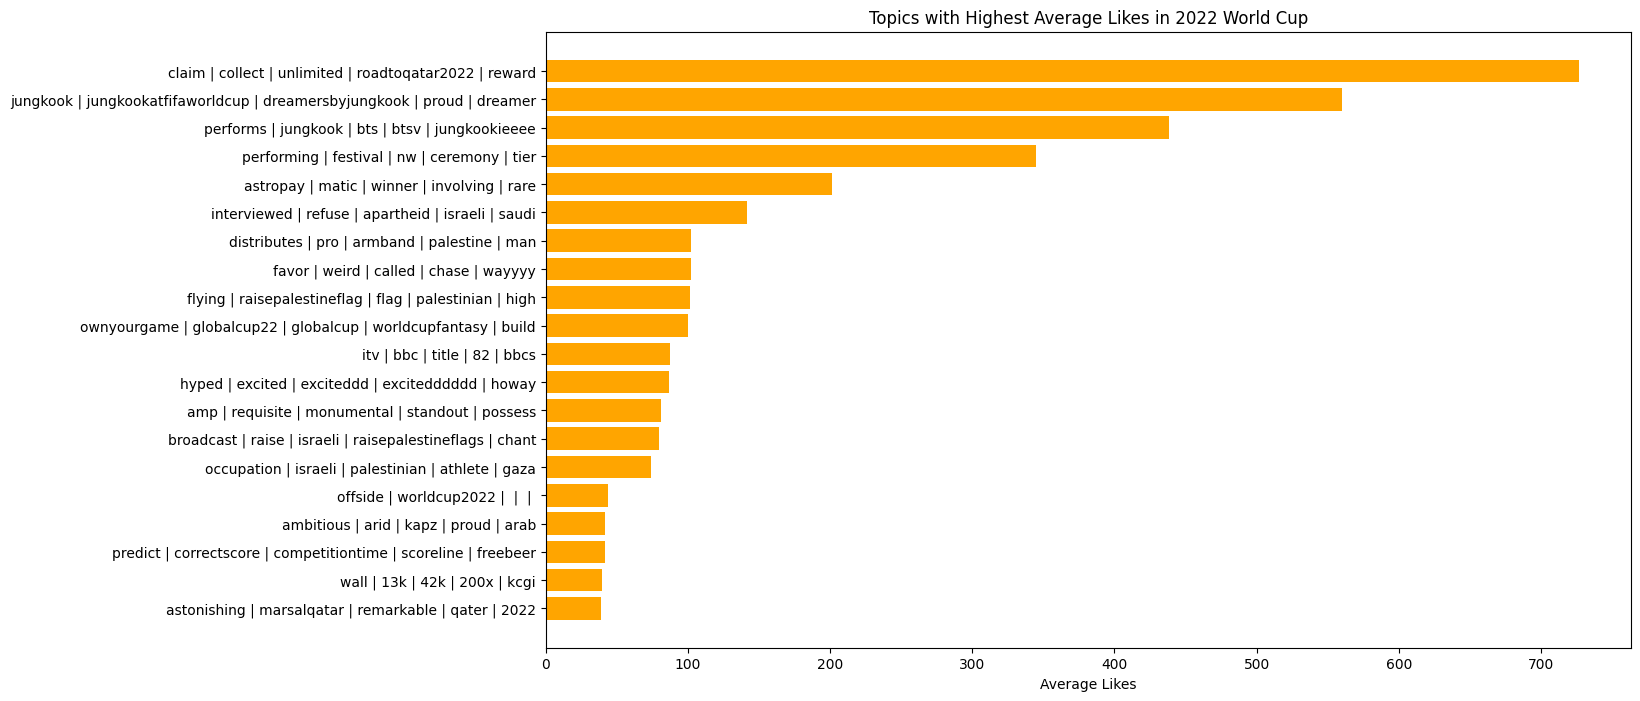

In [ ]:
liked_topics = (
    df22[df22["topic"] != -1]
    .groupby("topic")["Number of Likes"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
liked_df = pd.DataFrame({
    "Topic": liked_topics.index,
    "AvgLikes": liked_topics.values
})

liked_df["Representation"] = liked_df["Topic"].apply(
    lambda t: " | ".join(
        word
        for word, score
        in topic_model22.get_topic(t)[:5]
    )
)
plt.figure(figsize=(14,8))

plt.barh(
    liked_df["Representation"],
    liked_df["AvgLikes"],
    color="orange"
)

plt.title(
    "Topics with Highest Average Likes in 2022 World Cup"
)

plt.xlabel(
    "Average Likes"
)

plt.gca().invert_yaxis()

plt.show()

* Are positive tweets liked more or negative tweets are more engaging?

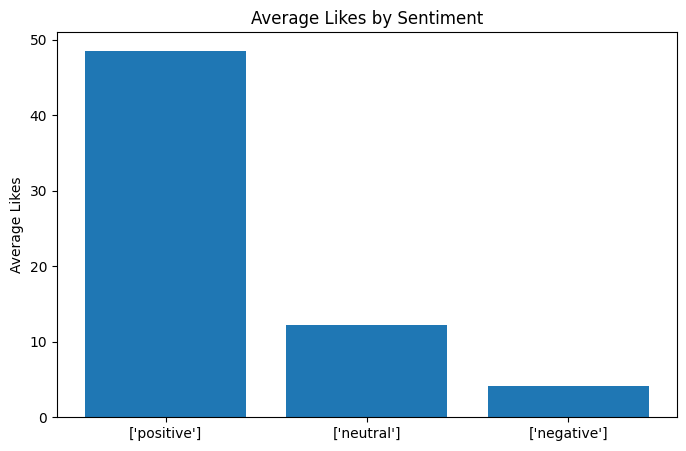

In [37]:
likes_sentiment = (
    df22.groupby("Sentiment")[
        "Number of Likes"
    ]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))

plt.bar(
    likes_sentiment.index,
    likes_sentiment.values
)

plt.title(
    "Average Likes by Sentiment"
)

plt.ylabel(
    "Average Likes"
)

plt.show()

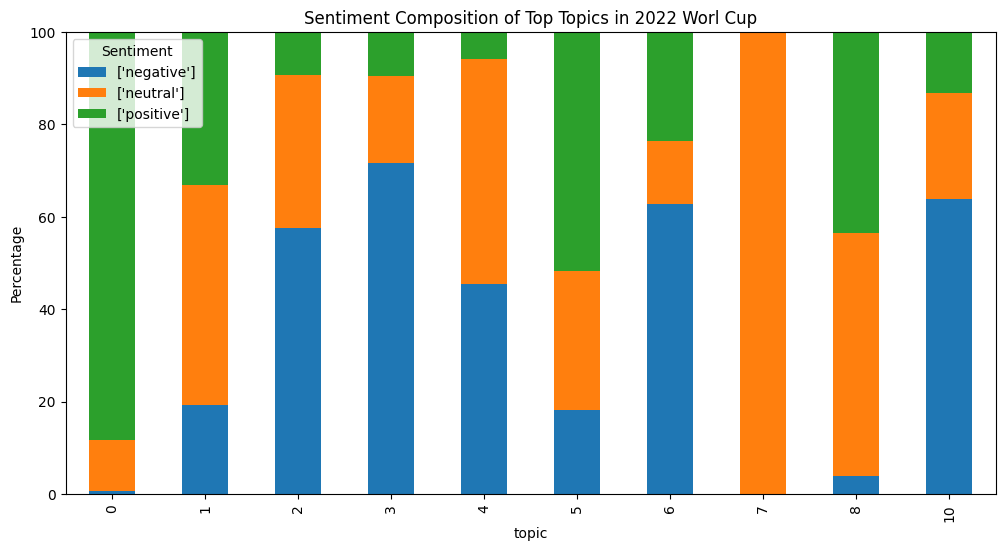

In [39]:
sent_topic_pct = pd.crosstab(
    df22["topic"],
    df22["Sentiment"],
    normalize="index"
) * 100

sent_topic_pct.loc[top_topics].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Sentiment Composition of Top Topics in 2022 Worl Cup"
)

plt.ylabel("Percentage")

plt.show()

* Which topics are the most controversial? ( positive and negative together)

In [49]:
sent_topic = pd.crosstab(
    df22["topic"],
    df22["Sentiment"]
)
sent_topic["controversy_score"] = (
    sent_topic[["['positive']", "['negative']"]]
    .min(axis=1)
)
top_controversial = (
    sent_topic
    .sort_values(
        "controversy_score",
        ascending=False
    )
    .head(10)
)

rows = []

for topic_id in top_controversial.index:

    words = [
        word
        for word, score
        in topic_model22.get_topic(topic_id)[:5]
    ]

    rows.append({
        "Topic": topic_id,
        "Representation": " | ".join(words),
        "Positive": sent_topic.loc[topic_id, "['positive']"],
        "Negative": sent_topic.loc[topic_id, "['negative']"],
        "Score": sent_topic.loc[topic_id, "controversy_score"]
    })

controversial_df = pd.DataFrame(rows)

controversial_df

,Topic,Representation,Positive,Negative,Score
0,-1,worldcup | qatar | game | worldcup2022 | football,4195,2838,2838
1,1,qatarworldcup2022 | qatar2022 | qatar | ready ...,171,99,99
2,6,right | feel | people | enjoy | human,59,157,59
3,5,ecuador | robbed | ecuadorvsqatar | header | goal,131,46,46
4,2,var | decision | ruin | already | minute,31,193,31
5,3,human | migrant | worker | hypocrisy | right,29,220,29
6,10,jiocinema | streaming | jio | app | fix,23,111,23
7,35,ecuador | awful | possession | dominated | alfaro,20,31,20
8,14,stadium | al | bayt | doha | attend,53,18,18
9,11,valencia | enner | header | goal | ener,84,17,17


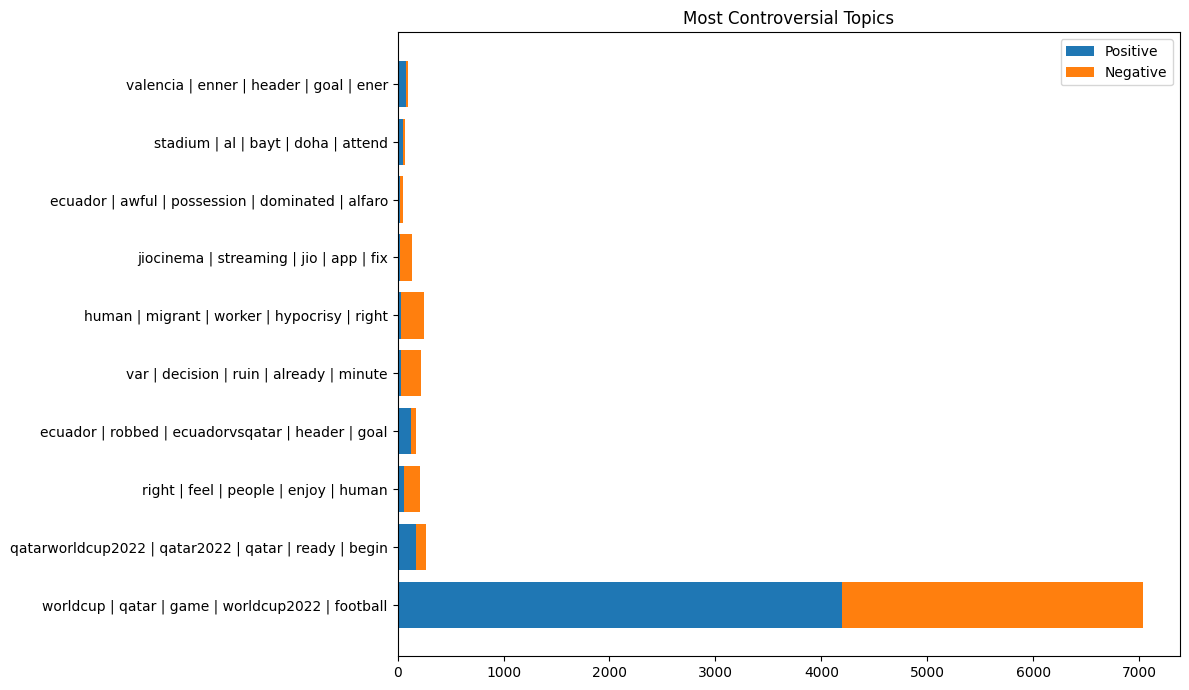

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,7))

y = np.arange(len(controversial_df))

plt.barh(
    y,
    controversial_df["Positive"],
    label="Positive"
)

plt.barh(
    y,
    controversial_df["Negative"],
    left=controversial_df["Positive"],
    label="Negative"
)

plt.yticks(
    y,
    controversial_df["Representation"]
)

plt.title(
    "Most Controversial Topics"
)

plt.legend()

plt.tight_layout()
plt.show()

* Which sources produce the most content?

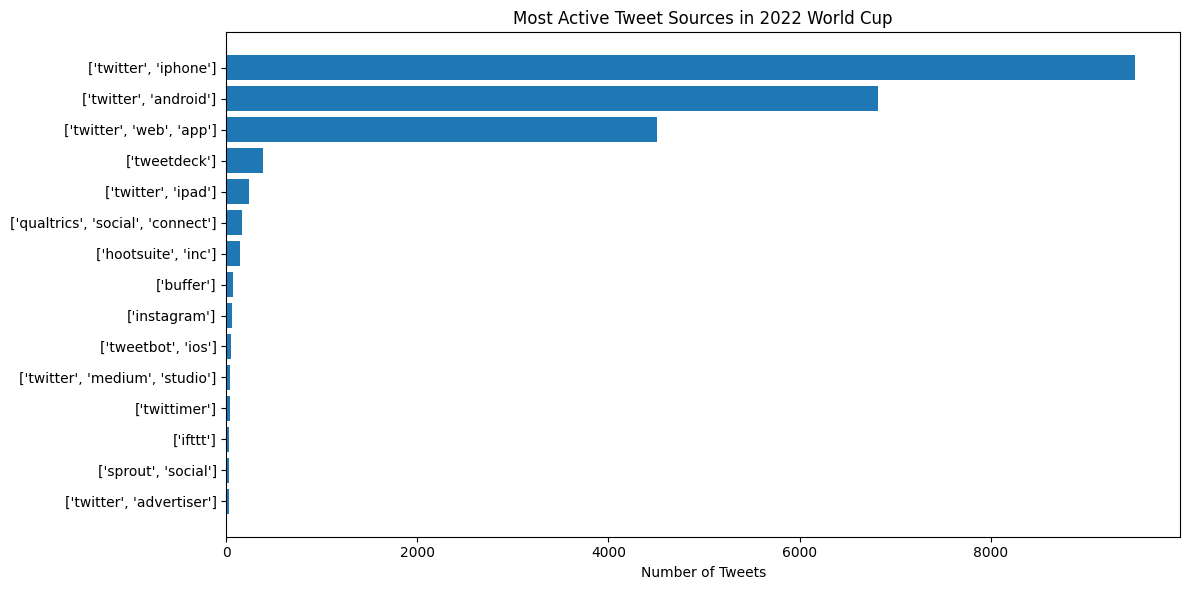

In [43]:
source_counts = (
    df22["Source of Tweet"]
    .value_counts()
)
import matplotlib.pyplot as plt

top_sources = (
    df22["Source of Tweet"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_sources.index,
    top_sources.values
)

plt.title(
    "Most Active Tweet Sources in 2022 World Cup"
)

plt.xlabel(
    "Number of Tweets"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()